# CM3015 Mid-term Coursework  
### *Machine Learning and Neural Networks*

---

### **Title of Project**
#### "A Controlled Study of Classical Machine Learning Algorithms for Music Symbol Image Classification Under Structured Perturbations"

<br>

**Student ID**: 240662088 <br>
**Module Code**: CM3015 <br>
**Module Name**: Machine Learning and Neural Networks <br>
**Date of Submission**: 13 July 2026  

---

### **Academic Integrity Declaration** <br>
I declare that this coursework is my own work and that it has not been submitted elsewhere for academic credit.

---


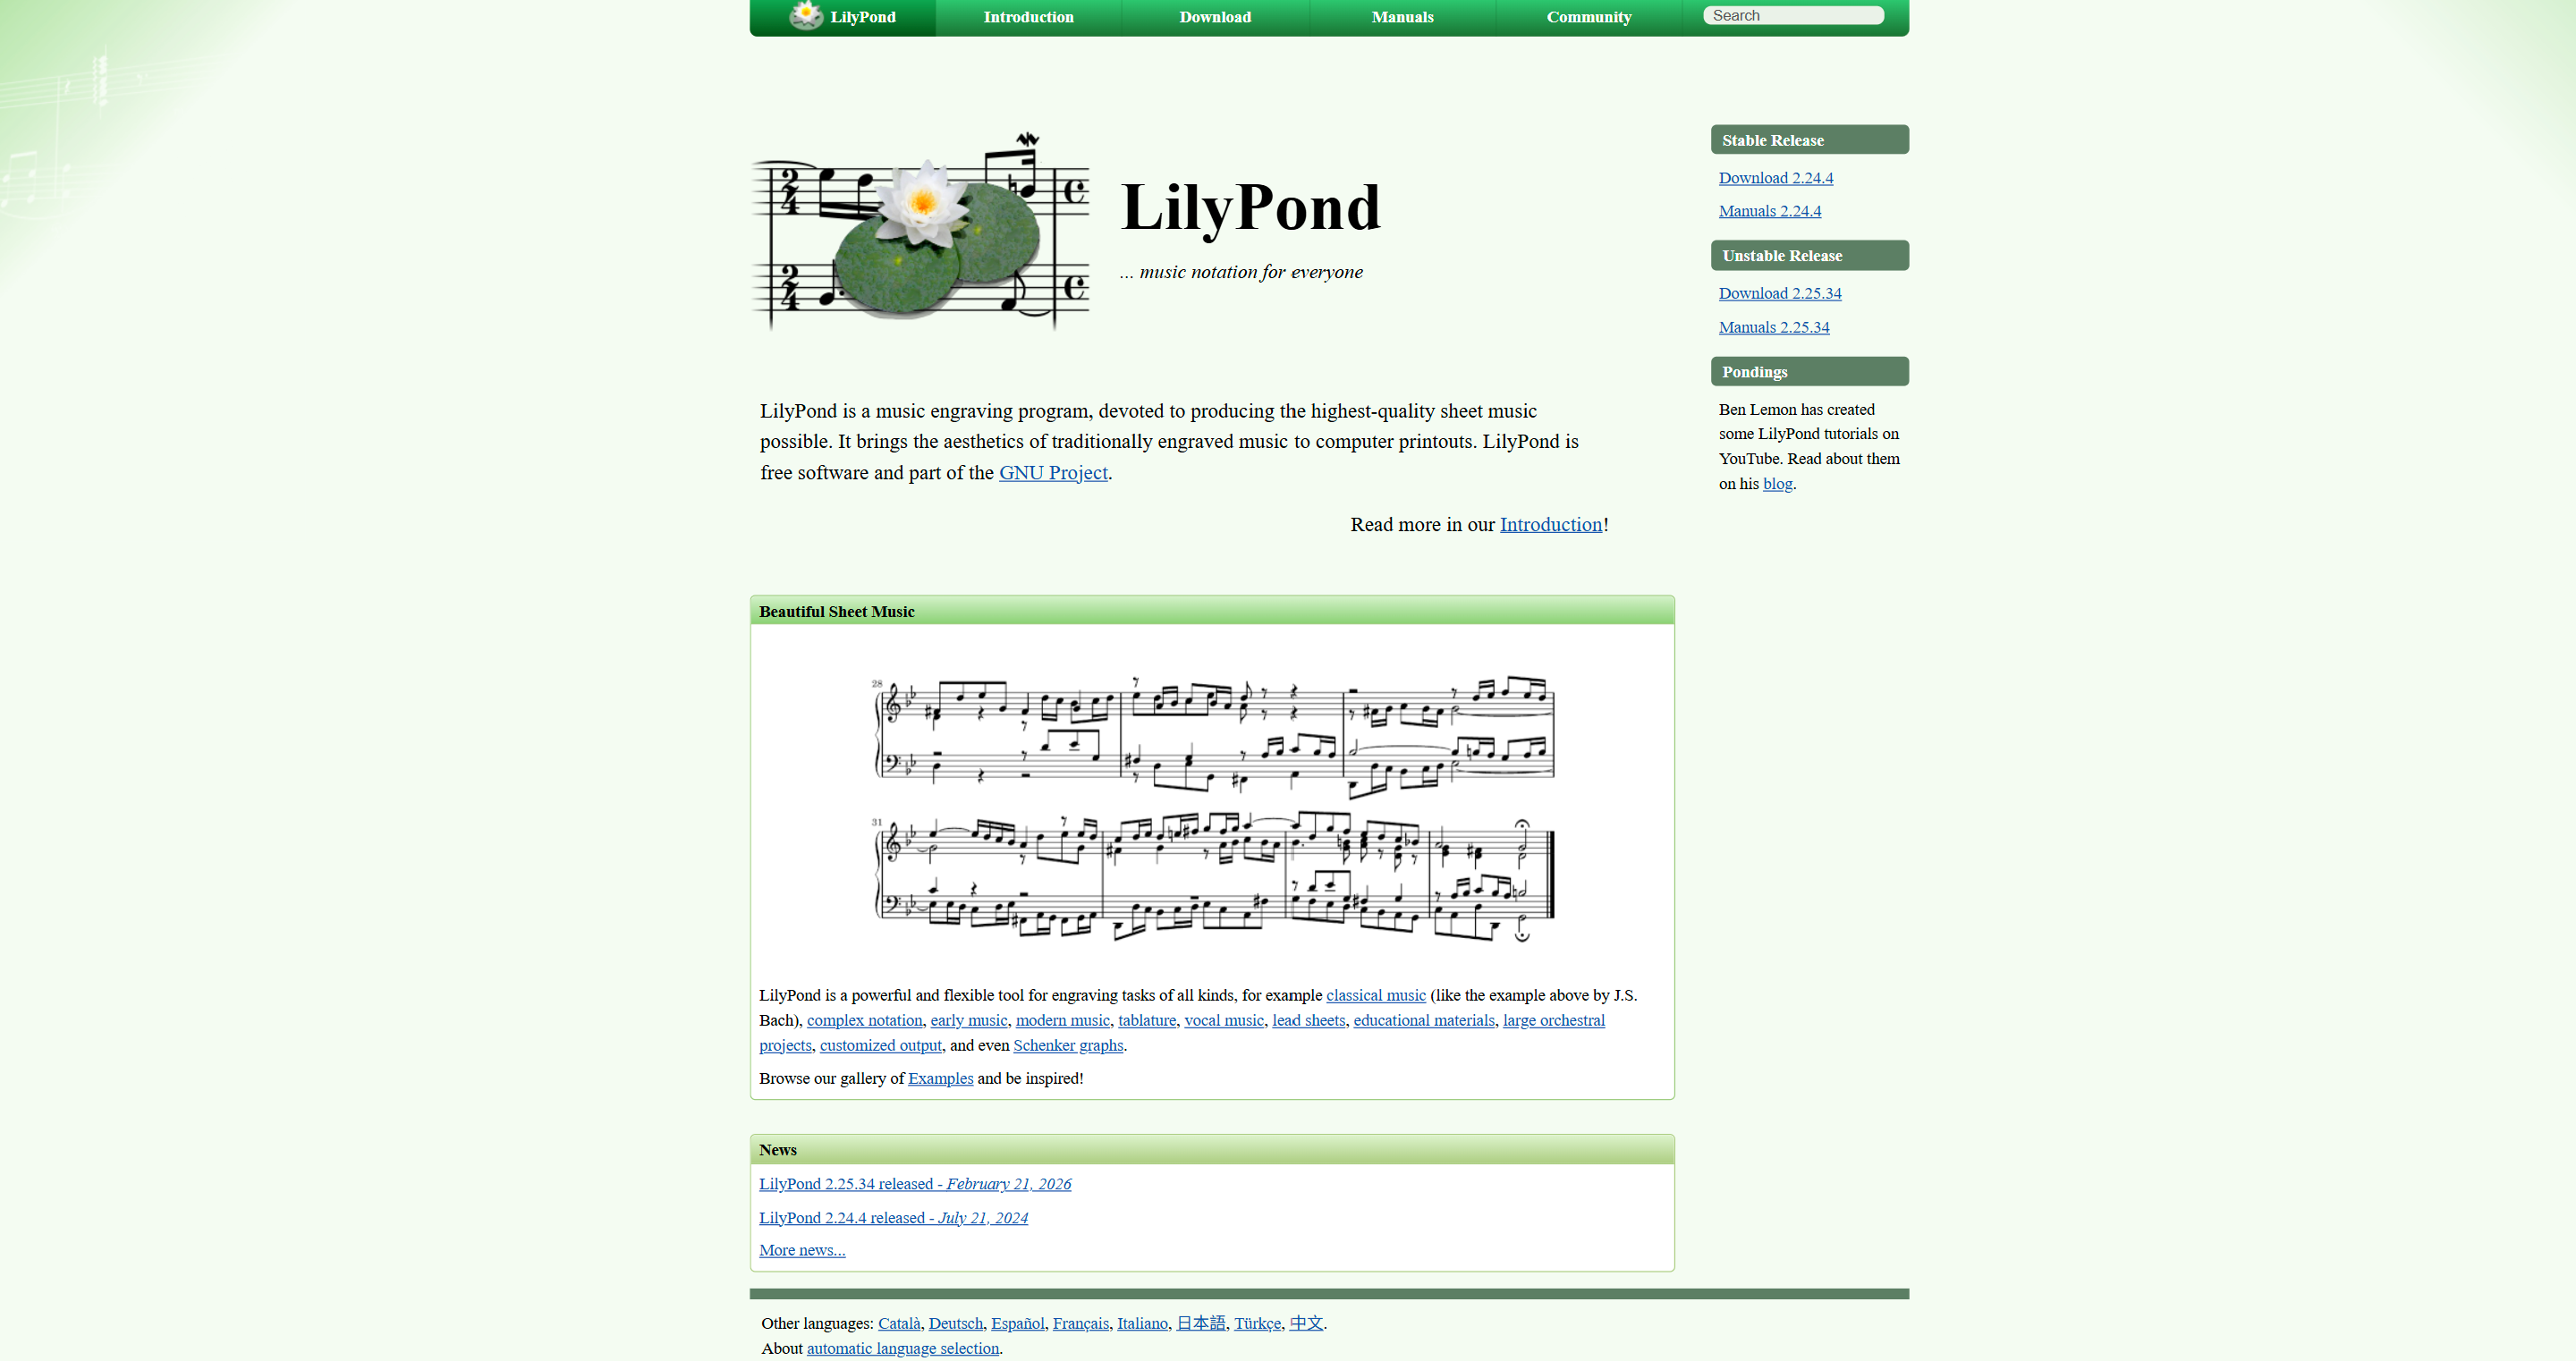

<p style="text-align: center; font-size: 13px; color: #555;">
<em>Image source: https://lilypond.org/index.html</em>
</p>

-------------------------------------------------------------------------------------------------------------------------------------------------------

## 1. Abstract

This project investigates the application of classical machine learning techniques to symbolic music notation image classification under controlled perturbation conditions. A custom dataset containing ten categories of musical notation symbols was programmatically generated using the LilyPond engraving system and standardised into 64×64 grayscale image representations. In addition to clean samples, mildly perturbed variants were produced using controlled noise, rotation, scaling, and translation to evaluate classifier robustness under distributional shift.

The study focuses on supervised multi-class classification and compares several classical machine learning algorithms, including from-scratch k-Nearest Neighbours (kNN), PCA-enhanced kNN, Decision Tree, Gaussian Naive Bayes, Logistic Regression, and Support Vector Machine (SVM). The from-scratch kNN implementation was developed without relying on pre-existing machine learning classifier libraries, allowing the underlying mechanisms of distance-based classification to be examined directly. Experimental evaluation considered validation accuracy, held-out test accuracy, clean versus mild-noise performance, dimensionality reduction, overfitting behaviour, and 5-fold stratified cross-validation stability.

The final results show that the Support Vector Machine achieved the strongest overall performance. It obtained a held-out test accuracy of **0.8667**, a mild-noise test accuracy of **0.8300**, and a mean cross-validation accuracy of **0.8577**. The SVM also produced the smallest clean-to-noise accuracy drop of **0.0733**, indicating the strongest robustness among the evaluated classifiers. Overall, the findings demonstrate that controlled dataset design, preprocessing, and model selection substantially influence classifier performance in symbolic image recognition tasks.


## 2. Introduction

Machine learning has emerged as a fundamental computational paradigm for constructing predictive systems capable of learning patterns directly from data rather than relying upon explicitly programmed rules. Within supervised learning, classification problems constitute a major area of study in which algorithms learn decision boundaries from labelled examples and subsequently infer the category membership of unseen observations (Bishop, 2006; Duda, Hart and Stork, 2001). Image classification, in particular, represents one of the most influential applications of machine learning due to its relevance across domains including computer vision, medical diagnosis, automated systems, handwriting recognition, and document analysis.

Despite the prominence of modern deep learning methods, classical machine learning algorithms remain highly valuable both pedagogically and practically. Algorithms such as k-nearest neighbours, Bayesian classifiers, decision trees, support vector machines, and dimensionality reduction methods continue to provide interpretable, computationally efficient, and theoretically instructive approaches for understanding statistical pattern recognition (Hastie, Tibshirani and Friedman, 2009). Furthermore, classical methods can perform competitively on smaller or carefully structured datasets where feature engineering and preprocessing play a significant role.

This project investigates the classification of symbolic music notation images using classical machine learning techniques. Musical notation recognition constitutes a specialised image classification problem involving the identification of structured visual symbols representing pitch, rhythm, articulation, and musical semantics. While substantial research has focused on large-scale optical music recognition pipelines and modern deep neural architectures, this project focuses on a controlled investigation of how classical machine learning algorithms behave under systematically generated symbolic notation datasets.

The generated dataset was designed specifically to support supervised multi-class classification experiments while also enabling broader investigation into feature representation and model generalisation. All images were standardised into grayscale 64×64 pixel representations, centred and normalised to minimise irrelevant variation while preserving class-defining structural characteristics. Controlled perturbations including small geometric transformations and Gaussian noise were additionally introduced to simulate realistic deviations encountered in practical image recognition tasks.

The primary aim of this project is therefore to evaluate the effectiveness and limitations of classical machine learning algorithms for symbolic music notation classification under varying image conditions. More specifically, the study seeks to answer the following research questions:

* Which classical machine learning algorithms achieve the strongest classification performance on structured symbolic music notation data?
* How does controlled image perturbation influence classification accuracy and model robustness?
* To what extent does dimensionality reduction improve image generalisation and computational efficiency?
* Which classes of music symbols exhibit the greatest ambiguity or susceptibility to misclassification?

In addition to evaluating predictive performance, the project also examines broader machine learning considerations including overfitting, generalisation, feature representation quality, and robustness under distributional variation. By combining controlled dataset engineering with comparative algorithm analysis, the study aims to provide a rigorous investigation into the capabilities and limitations of classical machine learning methods for structured symbolic image recognition tasks.


## 3. Background 

Machine learning algorithms aim to infer meaningful patterns from data through statistical optimisation and iterative adaptation rather than through explicitly programmed rule-based instructions. In supervised learning, a model is exposed to labelled examples during training and attempts to learn a mapping function between input observations and their corresponding target classes. The quality of this learned mapping is subsequently evaluated on previously unseen data in order to assess the model's ability to generalise beyond the training distribution (Bishop, 2006; Duda, Hart and Stork, 2001). Within image classification problems, the challenge lies in identifying feature representations that sufficiently capture discriminative visual structure while remaining robust to noise, variation, and distributional perturbations.

The present study investigates a controlled multi-class image classification problem involving ten categories of musical notation symbols. Each image is represented as a standardised 64×64 grayscale array, producing a high-dimensional feature space consisting of 4096 numerical variables per sample. Such representations are appropriate for classical machine learning techniques because they allow images to be interpreted as fixed-length numerical vectors suitable for distance-based, probabilistic, tree-based, linear, and margin-based learning algorithms (Hastie, Tibshirani and Friedman, 2009).

This project primarily investigates the behaviour of classical machine learning algorithms under varying image conditions, including both clean and mildly perturbed symbol representations. The inclusion of controlled perturbations enables evaluation not only of classification performance, but also of model robustness and sensitivity to distributional variation.

**3.1 Supervised Classification**

Supervised classification refers to the process of learning a predictive function from labelled training data. Given an input feature vector x and a corresponding class label y, the objective is to learn a function f(x) → y capable of accurately predicting unseen observations. During training, the algorithm adjusts its internal representation according to statistical relationships observed within the training dataset.

In the context of this project, the task is formulated as a ten-class classification problem in which each image belongs to one of the following categories:

* quarter note
* half note
* whole note
* quarter rest
* whole rest
* treble clef
* bass clef
* sharp accidental
* flat accidental
* natural accidental

The classification challenge is non-trivial because several symbol classes exhibit visual similarities. For example, quarter notes and half notes share related structural characteristics, while accidentals differ primarily through subtle geometric distinctions. Consequently, the problem provides an appropriate setting for evaluating the discriminative capacity of different machine learning approaches.

**3.2 k-Nearest Neighbors (kNN)**

The k-Nearest Neighbours algorithm is a non-parametric, instance-based supervised learning method. Unlike parametric models, kNN does not explicitly construct a generalised mathematical representation during training. Instead, all training examples are retained in memory, and prediction is performed by comparing new observations directly against previously observed samples (Cover and Hart, 1967).

For a given test image, the Euclidean distance between the test vector and all training vectors is computed. The algorithm then identifies the k nearest neighbours according to this distance metric. Classification is performed through majority voting among the neighbouring samples.

Mathematically, the Euclidean distance between two features x and y is defined as:

$$
d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}
$$

where *n* represents the dimensionality of the feature space.

Within image classification contexts, kNN can perform effectively because visually similar images often occupy neighbouring regions within feature space. However, the algorithm is highly sensitive to feature scaling, dimensionality, and noise. Since each image in this study contains 4096 pixel-level features, the curse of dimensionality becomes an important consideration. As dimensionality increases, pairwise distances between samples become less discriminative, potentially degrading classification performance.

For this reason, dimensionality reduction techniques such as Principal Component Analysis (PCA) are frequently applied prior to kNN classification in order to preserve dominant variance while reducing redundant or noisy features.

An important aspect for this coursework is that the kNN classifier was implemented manually using standard Python and NumPy operations rather than machine learning libraries. This enables direct examination of the underlying computational principles of supervised classification, neighbour selection, and distance-based inference.

**3.3 Decision Trees**

Decision Trees are hierarchical supervised learning algorithms that recursively partition the feature space into increasingly homogeneous subsets. At each internal node, the algorithm selects a feature and threshold value that best separates the training data according to a chosen impurity criterion (Quinlan, 1986).

The objective is to minimise class impurity within each resulting partition. Common impurity measures include Gini impurity and entropy. Gini impurity is defined as:

$$
G = 1 - \sum_{i=1}^{c} p_i^2
$$

where *pi* represents the probability of class i within a node and c denotes the total number of classes.

Decision Trees are advantageous because they are interpretable and capable of modelling non-linear decision boundaries. Unlike distance-based algorithms, they do not require feature normalisation and can naturally handle complex hierarchical feature interactions.

However, Decision Trees are prone to overfitting, particularly when unrestricted tree depth allows the model to memorise training examples. This issue becomes especially relevant in image classification tasks involving high-dimensional input spaces. Consequently, regularisation mechanisms such as maximum depth constraints and minimum sample thresholds are commonly employed to improve generalisation performance.

Within this project, Decision Trees provide a useful contrast to kNN because they rely upon fundamentally different learning principles. Whereas kNN performs local neighbourhood-based inference, Decision Trees construct explicit hierarchical partitioning rules over the feature space.

**3.4 Principal Component Analysis (PCA)**

Principal Component Analysis is an unsupervised dimensionality reduction technique that transforms high-dimensional data into a lower-dimensional representation while preserving as much variance as possible (Pearson, 1901; Jolliffe, 2002). PCA identifies orthogonal directions of maximal variance, known as principal components.

Given a centred dataset, PCA computes the eigenvectors and eigenvalues of the covariance matrix. The eigenvectors define the principal directions of variation, while the eigenvalues quantify the variance captured by each component.

In image classification problems, PCA serves several important functions:

* reduction of computational complexity
* removal of redundant features
* mitigation of overfitting
* suppression of noise
* improved visualisation of high-dimensional structure

Since each image in this project initially contains 4096 dimensions, PCA enables investigation into whether lower-dimensional representation preserve sufficient discriminative information for accurate classification.

The application of PCA is particularly relevant to kNN because nearest-neighbour methods are sensitive to high-dimensional noise and irrelevant features. By projecting data into a reduced feature space, PCA may improve neighbour discrimination and overall classification robustness.

**3.5 Model Generalisation and Robustness**

A central objective in machine learning is the development of models capable of generalising effectively to previously unseen data. High training accuracy alone does not necessarily imply meaningful predictive performance, particularly if a model has overfitted the training distribution.

To investigate robustness, this project introduces controlled perturbations through mildly distorted image conditions involving:

* small rotational variation
* slight scaling transformations
* translational offsets
* Gaussian noise

These perturbations simulate realistic distribution variability while preserving semantic class identity. Evaluation across both clean and noisy conditions enables assessment of algorithmic stability and resilience under imperfect observational conditions.

This distinction between clean and perturbed data is important because real-world machine learning systems rarely operate under perfectly controlled input distributions. Consequently, robustness analysis provides a more meaningful evaluation of practical model behaviour than clean-data accuracy alone.

**3.6 Multi-Class Classification Evaluation**

Because the dataset contains ten distinct symbol categories, this study constitutes a multi-class classification problem. Performance evaluation therefore requires metrics capable of assessing both overall predictive accuracy and class-specific behaviour.

Classification performance is evaluated using:

* overall accuracy
* confusion matrices
* cross-validation
* robustness comparison across perturbation conditions

Confusion matrices are particularly informative because they reveal systematic misclassification patterns between visually similar classes. Such analyses provide insight into both feature representation quality and the inductive biases of the investigated algorithms.

Overall, the algorithms selected in this study provide complementary perspectives on classical machine learning behaviour. Distance-based learning, hierarchical partitioning, and dimensionality reduction collectively enable a comprehensive investigation into classification performance, robustness, and feature-space structure within a controlled symbolic image recognition problem.


## 4. Methodology

This study adopted a controlled experimental methodology designed to evaluate the behaviour of classical machine learning algorithms under both ideal and perturbed symbolic image classification conditions. The overall pipeline consisted of four principal stages: dataset generation, image preprocessing and validation, feature extraction with optional dimensionality reduction, and supervised classification with comparative evaluation. The methodology was designed to support reproducibility, balanced experimentation, and systematic robustness analysis.

**4.1 Dataset Construction**

A synthetic image dataset of musical notation symbols was programmatically generated using the LilyPond music engraving system (LilyPond Development Team, 2024). Image processing and standardisation operations were supported using ImageMagick (ImageMagick Studio LLC, 2024). The use of synthetic generation rather than externally sourced image collections provided several methodological advantages. First, it enabled complete control over class balance and perturbation conditions. Second, it ensured that all samples were generated under consistent rendering conditions, reducing uncontrolled confounding variables that may occur in real-world image datasets. Third, it allowed perturbation parameters to be recorded systematically, supporting reproducibility and robustness analysis.

The dataset consisted of ten musical notation symbol categories:

* quarter note
* half note
* whole note
* quarter rest
* whole rest
* treble clef
* bass clef
* sharp accidental
* flat accidental
* natural accidental

For each class, 200 clean images and 200 mildly perturbed images were generated, resulting in a total dataset size of 4000 samples. The perturbation condition was introduced to simulate moderate real-world variation while preserving the semantic identity of each symbol class.

Symbol rendering was diversified through several controlled parameters, including varying musical pitches, differing phrase lengths, varied staff positioning, accidental rendering variation, and multiple note groupings. This variability was introduced to reduce trivial memorisation and encourage the models to learn generalisable visual structures rather than isolated templates.

**Table 1: Dataset Summary**

| Dataset Property | Value | 
| ---------------- | ----- |
| Number of classes | 10 |
| Conditions | 'clean' and 'mild_noise' |
| Images per class per condition | 200 |
| Total Images | 4000 |
| Image format | 64 x 64 grayscale |
| Feature dimension | 4096 flattened pixel values |
| Pixel range | [0,1] after normalisation |

**4.2 Perturbation and Robustness Conditions**

Two experimental conditions were constructed: `clean` and `mild_noise`.

The clean condition consisted of standardised grayscale images generated directly from LilyPond-rendered notation. The `mild_noise` condition introduced controlled perturbations using image transformation procedures, including small rotational distortions, slight scaling variation, translation displacement, and low-amplitude Gaussian noise.

These perturbations were intentionally moderate rather than severe. The objective was not to create adversarial corruption, but to examine whether the investigated machine learning algorithms remained robust under realistic observational variability.

This distinction between clean and perturbed data formed a central component of the experimental design. Rather than evaluating classification performance only under ideal conditions, this study also examined how much model accuracy degraded under controlled distributional shift.

**4.3 Image Standardisation and Preprocessing**

All generated images underwent a standardised preprocessing pipeline before machine learning analysis. Each image was converted to grayscale, flattened onto a white background, tightly cropped to remove excess whitespace, centred spatially, and resized to a fixed resolution of 64×64 pixels.

Standardisation was necessary to ensure consistency across all training samples and to prevent variation in image dimensions from influencing model behaviour. The resulting 64×64 grayscale representation produced a fixed-dimensional feature vector containing 4096 numerical attributes per image.

Pixel intensities were normalised to the interval [0, 1] by dividing each pixel value by 255. This transformation improved numerical stability and prevented large pixel-value magnitudes from disproportionately affecting distance-based algorithms such as k-Nearest Neighbours.

Images were loaded and converted into numerical arrays using NumPy-based processing, enabling each image to be represented as a normalised flattened feature vector suitable for classical machine learning algorithms (Harris et al., 2020).

**4.4 Metadata Recording and Experimental Traceability**

A metadata file was generated alongside the dataset to preserve experimental traceability. Each sample record contained information such as filename, class label, perturbation condition, phrase length, pitch information, perturbation parameters, and random seed value.

Metadata storage and tabular summaries were managed using pandas data structures, which supported systematic inspection of dataset composition and experimental traceability (McKinney, 2010).

The inclusion of metadata enabled systematic inspection of dataset composition and supported reproducibility of the experimental pipeline. Recording perturbation parameters also allowed the clean and mildly perturbed subsets to be analysed separately during robustness evaluation.

**4.5 Dataset Validation and Integrity Checking**

Before model training, the dataset underwent a validation stage to ensure structural consistency and data integrity. The validation checks included verification of image dimensions, confirmation of grayscale encoding, detection of unreadable or corrupted files, verification of class balance, confirmation of perturbation-condition balance, and identification of blank or near-empty images.

This validation stage was important because machine learning models are sensitive to inconsistencies in data formatting and representation. Ensuring uniformity before feature extraction reduced the likelihood of hidden preprocessing artefacts influencing classification performance.

Following validation, each image was converted into a flattened numerical feature vector suitable for classical machine learning algorithms.

**4.6 Exploratory Dataset Analysis**

Prior to supervised model training, exploratory dataset analysis was conducted to examine dataset structure, validate class balance, and inspect the visual characteristics of the generated symbols. Exploratory analysis is an important component of machine learning experimentation because it enables early identification of potential biases, hidden artefacts, and distributional inconsistencies that may affect downstream model behaviour.

Initial inspection confirmed that all ten symbol classes were uniformly represented across both experimental conditions. The dataset therefore exhibited balanced class and condition distributions, reducing the likelihood of classification bias toward overrepresented categories.

Visual inspection and plotting were performed using Matplotlib during exploratory analysis, allowing representative samples, intensity distributions, and class-level image patterns to be examined before model training (Hunter, 2007). This confirmed that the generated symbols remained visually recognisable after preprocessing and perturbation.

Pixel intensity analysis was conducted to examine the numerical characteristics of the dataset. This included inspection of global pixel-intensity distributions, condition-specific intensity statistics, and class-level average images. These analyses helped confirm that the generated images were consistently represented and that the mild-noise condition introduced additional variation while preserving class identity.

Exploratory dimensionality reduction using Principal Component Analysis was also conducted. Projection of high-dimensional image representations into lower-dimensional component space enabled visual inspection of clustering tendencies between symbol categories. Although overlap was observed between visually similar notation symbols, several classes showed distinguishable structure, indicating that the feature representation retained meaningful discriminative information.

Overall, the exploratory analysis stage provided evidence that the generated dataset possessed sufficient structural diversity, class balance, and feature separability to support supervised learning experiments.

**4.7 Feature Representation**

Each 64×64 grayscale image was represented as a flattened one-dimensional vector containing 4096 features. This vectorised representation enabled compatibility with traditional machine learning models that operate on tabular numerical data.

Although flattened pixel representations do not explicitly preserve spatial structure in the same way as convolutional neural networks, they are appropriate for investigating classical algorithms such as k-Nearest Neighbours, Decision Trees, Naive Bayes, Logistic Regression, and Support Vector Machines. The controlled nature of the dataset allowed this study to examine how effectively traditional machine learning methods could classify symbolic image data without deep feature-learning architectures.

**4.8 Dimensionality Reduction Using PCA**

Because the original feature space contained 4096 dimensions per sample, dimensionality reduction was explored using Principal Component Analysis. High-dimensional feature spaces may contain redundant or noisy information that can negatively affect distance-based algorithms and increase computational cost.

PCA was applied to investigate whether lower-dimensional representations could preserve discriminative structure while reducing dimensionality. This was particularly relevant for kNN classification, since nearest-neighbour methods are sensitive to the curse of dimensionality. Reducing dimensionality can potentially improve neighbour discrimination by suppressing irrelevant variation.

PCA was used both for exploratory analysis and as a preprocessing step for the PCA-enhanced kNN model. To avoid data leakage, PCA was fitted only on training data before being applied to validation or test data.

**4.9 Train-Validation-Test Splitting and Cross-Validation**

The dataset was divided into training, validation, and testing subsets using stratified sampling. Stratification was applied using combined class-condition labels so that both the ten musical symbol classes and the two perturbation conditions were represented consistently across each partition.

The validation set was used during model selection and hyperparameter tuning. This included selecting the number of neighbours for kNN, the number of PCA components for PCA+kNN, the maximum tree depth for Decision Tree classification, and the regularisation and kernel parameters for the SVM classifier. The final test set was kept separate and used only for final performance evaluation.

In addition to the fixed train-validation-test split, stratified 5-fold cross-validation was performed to obtain a more stable estimate of generalisation performance. Cross-validation reduces dependence on a single random split and provides insight into whether model performance remains consistent across different data partitions (Kohavi, 1995).

For the manually implemented kNN models, cross-validation was performed using the custom from-scratch kNN implementation rather than scikit-learn’s built-in KNeighborsClassifier. In each fold, the kNN classifier was trained on the training fold and evaluated on the validation fold. For PCA-enhanced kNN, PCA was fitted only on the training fold before transforming the corresponding validation fold, thereby avoiding data leakage.
This ensured that the reported kNN and PCA+kNN cross-validation results remained consistent with the coursework requirement for a manually implemented machine learning algorithm.

**4.10 Algorithm Selection**

This study investigated six supervised machine learning approaches representing different classification paradigms:

* from-scratch k-Nearest Neighbours
* PCA-enhanced k-Nearest Neighbours using the from-scratch kNN classifier
* Decision Tree classifier
* Gaussian Naive Bayes
* Multinomial Logistic Regression
* Support Vector Machine with an RBF kernel

The implemented classifiers were selected to represent different learning paradigms, including instance-based learning, dimensionality reduction, probabilistic classification, hierarchical partitioning, linear discriminative modelling, and non-linear margin-based classification (Cover and Hart, 1967; Pearson, 1901; Jolliffe, 2002; John and Langley, 1995; Quinlan, 1986; Cortes and Vapnik, 1995). This enabled systematic comparison between distance-based, probabilistic, tree-based, linear, and margin-based learning approaches using identical preprocessing and feature representations.

The k-Nearest Neighbours classifier was implemented from scratch using standard Python and NumPy. Distance computation, neighbour selection, majority voting, validation testing, and manual stratified cross-validation were implemented without using pre-existing machine learning classifier libraries. This decision was motivated by the coursework requirement to implement at least one algorithm independently and by the educational objective of understanding the computational mechanics of nearest-neighbour classification.

The remaining library-based classifiers and evaluation utilities were implemented using scikit-learn, while the kNN classifier was manually implemented to satisfy the coursework requirement for a from-scratch algorithm (Pedregosa et al., 2011).

Because nearest-neighbour methods are sensitive to high-dimensional feature spaces, a PCA-enhanced kNN configuration was also investigated. Principal Component Analysis was applied as a dimensionality reduction step before classification. After dimensionality reduction, classification was still performed using the manually implemented kNN classifier. This enabled examination of whether compressed feature representations improved neighbour discrimination and generalisation performance.

Decision Tree classification was selected as a complementary approach because it applies hierarchical rule-based partitioning rather than distance-based inference. This allowed comparison between local instance-based learning and recursive feature-space partitioning.
Gaussian Naive Bayes was included as a probabilistic baseline classifier. Although its conditional independence assumption is simplified for image data, it provides a computationally efficient benchmark against which more complex methods can be compared.

Multinomial Logistic Regression was included as a linear discriminative baseline for multi-class classification. This model enabled investigation of whether the musical notation classes could be separated using approximately linear decision boundaries within the high-dimensional pixel feature space.

Support Vector Machine classification was included because of its suitability for high-dimensional classification problems. An RBF kernel was used to support non-linear decision boundaries. Unlike kNN, which relies on local similarity, SVM optimises a global maximum-margin separation criterion. Hyperparameter tuning was performed using validation-set experimentation over different values of the regularisation parameter C and kernel coefficient gamma.

The inclusion of these diverse algorithms enabled a comprehensive comparative evaluation of how different classical machine learning approaches respond to symbolic image data under both clean and perturbed conditions.

**4.11 Evaluation Strategy**

Model performance was evaluated using several complementary criteria, including validation accuracy, held-out test accuracy, class-level precision, recall and F1-score, confusion matrices, robustness under perturbation, and 5-fold cross-validation performance.

Confusion matrices were used to inspect systematic class confusion patterns between visually similar symbols. This provided deeper interpretability than overall accuracy alone by showing which notation classes were most frequently misclassified.

Performance under clean and mildly perturbed conditions was analysed separately to evaluate model robustness and sensitivity to controlled distributional variation. The clean-to-noise accuracy drop was used as an additional robustness measure, where a smaller drop indicated greater stability under perturbation.

Cross-validation mean accuracy and standard deviation were also reported to assess model consistency across multiple train-validation splits. This allowed the final evaluation to consider not only single-split test accuracy, but also robustness and stability across different data partitions.

Overall, the evaluation strategy was designed to compare the classifiers in terms of predictive accuracy, robustness, interpretability, and generalisation stability.


**Computational Environment and Dependencies**

The following Python packages were used to execute the experimental pipeline, including data loading, preprocessing, model training, evaluation, visualisation, model persistence, and the optional Streamlit application.

In [69]:
# installation of required libraries and packages
# !pip install numpy pandas scikit-learn pillow joblib matplotlib streamlit

In [71]:
# save the current python environment to requirements.txt for reproducibility
# !pip freeze > requirements.txt

**Step 1: Synthetic Image Data Generation**

In [1]:
# step 1: synthetic image data generation 

"""
Controlled Music Symbol Image Dataset Generator
-----------------------------------------------

This script constructs a reproducible synthetic image dataset of musical 
notation symbols for classical machine learning (ML) experiments.

The dataset contains 10 balanced classes under two experimental conditions:
clean and mildly perturbed. Symbols are rendered using LilyPond,
converted to PNG with ImageMagick, standardised to 64x64 grayscale images, 
and recorded in a metadata file (metadata.csv) for reproducibility and 
experimental traceability. 

The resulting dataset supports multi-class classification, robustness analysis, 
feature representation comparison, PCA-based dimensionality reduction, and 
supervised model evaluation.

Dataset size:
    10 classes x 200 samples x 2 conditions = 4000 images
"""

import csv
import random
import subprocess
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from zoneinfo import ZoneInfo

import pandas as pd


# =======================
# configurations 
# =======================

OUTPUT_ROOT = Path("music_symbols_dataset")
IMAGES_PER_CLASS = 200
RESOLUTION = 300
FINAL_SIZE = 64
SEED = 42

# set to True only for debugging
# keep False for final notebook/report export to avoid thousands of repeated outputs
VERBOSE = False

random.seed(SEED)

BASE_PITCHES = ["a", "b", "c", "d", "e", "f", "g"]
OCTAVE = "'"
PITCHES = [p + OCTAVE for p in BASE_PITCHES]

NATURAL_KEY_MAP = {
    "c": "cis",
    "d": "e",
    "e": "fis",
    "f": "fis",
    "g": "a",
    "a": "b",
    "b": "cis",
}


# =======================
# utilities 
# =======================

def run_checked(cmd: List[str], *, cwd: Optional[Path] = None) -> None:
    """Run a shell command and raise an informative error if it fails."""
    result = subprocess.run(
        cmd,
        cwd=str(cwd) if cwd else None,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )

    if result.returncode != 0:
        print("\nCommand failed:", " ".join(cmd))

        if result.stdout.strip():
            print("STDOUT:\n", result.stdout)

        if result.stderr.strip():
            print("STDERR:\n", result.stderr)

        raise subprocess.CalledProcessError(
            result.returncode,
            cmd,
            output=result.stdout,
            stderr=result.stderr
        )


def lilypond_template(music_code: str) -> str:
    """Return a compact LilyPond score template for rendering one symbol phrase."""
    return f"""
\\version "2.24.2"

\\paper {{
  tagline = ##f
  indent = 0\\mm
  ragged-right = ##t
  ragged-last-bottom = ##t

  top-margin = 0\\mm
  bottom-margin = 0\\mm
  left-margin = 0\\mm
  right-margin = 0\\mm

  paper-width = 90\\mm
  paper-height = 40\\mm

  #(define page-breaking ly:one-page-breaking)
}}

\\score {{
  \\new Staff {{
    {music_code}
  }}
  \\layout {{
    \\context {{
      \\Staff
      \\remove "Time_signature_engraver"
    }}
  }}
}}
"""


def standardise_to_64x64(src_png: Path, dst_png: Path) -> None:
    """Convert a rendered PNG to a centred 64x64 grayscale image."""
    run_checked([
        "magick",
        str(src_png),
        "-background", "white",
        "-alpha", "remove",
        "-flatten",
        "-colorspace", "Gray",
        "-trim", "+repage",
        "-resize", f"{FINAL_SIZE}x{FINAL_SIZE}^",
        "-gravity", "center",
        "-extent", f"{FINAL_SIZE}x{FINAL_SIZE}",
        str(dst_png)
    ])


def make_mild_noise(src_png_64: Path, dst_png_64: Path) -> Dict[str, float]:
    """
    Create a mildly perturbed version of a 64x64 image.

    Perturbations:
    - small rotation
    - slight scale variation
    - small translation
    - light Gaussian noise
    """
    rotation = random.uniform(-3.0, 3.0)
    scale = random.uniform(0.95, 1.05)
    translation_x = random.randint(-2, 2)
    translation_y = random.randint(-2, 2)
    noise_attenuation = random.uniform(0.10, 0.25)

    resized_dim = max(1, int(FINAL_SIZE * scale))

    run_checked([
        "magick",
        str(src_png_64),
        "-background", "white",
        "-alpha", "remove",
        "-flatten",
        "-colorspace", "Gray",

        "-rotate", f"{rotation}",

        "-resize", f"{resized_dim}x{resized_dim}",
        "-gravity", "center",
        "-extent", f"{FINAL_SIZE}x{FINAL_SIZE}",

        "-roll", f"{translation_x:+d}{translation_y:+d}",

        "-attenuate", f"{noise_attenuation}",
        "+noise", "Gaussian",

        "-gravity", "center",
        "-extent", f"{FINAL_SIZE}x{FINAL_SIZE}",
        str(dst_png_64)
    ])

    return {
        "rotation": round(rotation, 4),
        "scale": round(scale, 4),
        "translation_x": translation_x,
        "translation_y": translation_y,
        "noise_attenuation": round(noise_attenuation, 4),
    }


# =======================
# phrase generators
# =======================

def choose_phrase_length(
    length_weights: Tuple[float, float, float, float, float] = (
        0.4, 0.25, 0.2, 0.1, 0.05
    )
) -> int:
    """Choose phrase length from 1 to 5 using weighted sampling."""
    return random.choices(
        [1, 2, 3, 4, 5],
        weights=length_weights
    )[0]


def phrase_of_notes(
    duration: str,
    length_weights: Tuple[float, float, float, float, float] = (
        0.4, 0.25, 0.2, 0.1, 0.05
    )
) -> Tuple[str, Dict[str, str]]:
    """Generate a note phrase with a specified rhythmic duration."""
    length = choose_phrase_length(length_weights)
    pitches = [random.choice(PITCHES) for _ in range(length)]
    music_code = " ".join(f"{p}{duration}" for p in pitches)

    return music_code, {
        "phrase_length": length,
        "pitches": " ".join(pitches),
    }


def phrase_of_rests(
    rest_token: str,
    length_weights: Tuple[float, float, float, float, float] = (
        0.4, 0.25, 0.2, 0.1, 0.05
    )
) -> Tuple[str, Dict[str, str]]:
    """Generate a rest phrase with controlled staff-position variation."""
    length = choose_phrase_length(length_weights)
    parts = []

    for _ in range(length):
        staff_position = random.randint(-6, 6)
        parts.append(
            f"\\once \\override Rest.staff-position = #{staff_position} {rest_token}"
        )

    return " ".join(parts), {
        "phrase_length": length,
        "pitches": "",
    }


def clef_phrase(
    clef: str,
    length_weights: Tuple[float, float, float, float, float] = (
        0.4, 0.25, 0.2, 0.1, 0.05
    )
) -> Tuple[str, Dict[str, str]]:
    """Generate a clef phrase followed by notes."""
    length = choose_phrase_length(length_weights)
    pitches = [random.choice(PITCHES) for _ in range(length)]

    music_code = f"\\clef {clef} " + " ".join(f"{p}4" for p in pitches)

    return music_code, {
        "phrase_length": length,
        "pitches": " ".join(pitches),
    }


def accidental_phrase(
    kind: str,
    length_weights: Tuple[float, float, float, float, float] = (
        0.4, 0.25, 0.2, 0.1, 0.05
    )
) -> Tuple[str, Dict[str, str]]:
    """
    Generate accidental phrases.

    Parameters
    ----------
    kind : str
        'is' for sharp and 'es' for flat in LilyPond notation.
    """
    length = choose_phrase_length(length_weights)
    base_pitches = [random.choice(BASE_PITCHES) for _ in range(length)]

    notes = [f"{p}{kind}{OCTAVE}4" for p in base_pitches]
    pitches = [p + OCTAVE for p in base_pitches]

    return " ".join(notes), {
        "phrase_length": length,
        "pitches": " ".join(pitches),
    }


def natural_phrase(
    length_weights: Tuple[float, float, float, float, float] = (
        0.4, 0.25, 0.2, 0.1, 0.05
    )
) -> Tuple[str, Dict[str, str]]:
    """
    Generate a natural accidental phrase.

    A key signature is selected in which the chosen pitch would normally be
    sharpened. The pitch is then written with '!' so LilyPond prints a natural
    accidental symbol.
    """
    pitch = random.choice(BASE_PITCHES)
    key = NATURAL_KEY_MAP[pitch]
    length = choose_phrase_length(length_weights)

    notes = " ".join(f"{pitch}{OCTAVE}!4" for _ in range(length))
    music_code = f"\\key {key} \\major {notes}"

    return music_code, {
        "phrase_length": length,
        "pitches": " ".join([pitch + OCTAVE for _ in range(length)]),
    }


# =======================
# symbol definitions
# =======================

SYMBOLS = {
    "quarter_note": lambda: phrase_of_notes("4"),
    "half_note": lambda: phrase_of_notes("2"),
    "whole_note": lambda: phrase_of_notes(
        "1",
        length_weights=(0.6, 0.4, 0, 0, 0)
    ),

    "quarter_rest": lambda: phrase_of_rests("r4"),
    "whole_rest": lambda: phrase_of_rests(
        "r1",
        length_weights=(0.6, 0.4, 0, 0, 0)
    ),

    "treble_clef": lambda: clef_phrase("treble"),
    "bass_clef": lambda: clef_phrase("bass"),

    "sharp": lambda: accidental_phrase("is"),
    "flat": lambda: accidental_phrase("es"),
    "natural": lambda: natural_phrase(),
}


# =======================
# dataset generation
# =======================

def ensure_directories() -> None:
    """Create the final output folder structure."""
    for condition in ["clean", "mild_noise"]:
        for class_name in SYMBOLS:
            (OUTPUT_ROOT / condition / class_name).mkdir(
                parents=True,
                exist_ok=True
            )


def build_metadata_row(
    filename: Path,
    class_name: str,
    condition: str,
    phrase_metadata: Dict[str, str],
    perturbation_metadata: Dict[str, float],
) -> Dict[str, object]:
    """Create one metadata row."""
    return {
        "filename": str(filename).replace("\\", "/"),
        "class": class_name,
        "condition": condition,
        "phrase_length": phrase_metadata.get("phrase_length", ""),
        "pitches": phrase_metadata.get("pitches", ""),
        "rotation": perturbation_metadata.get("rotation", 0),
        "scale": perturbation_metadata.get("scale", 1),
        "translation_x": perturbation_metadata.get("translation_x", 0),
        "translation_y": perturbation_metadata.get("translation_y", 0),
        "noise_attenuation": perturbation_metadata.get("noise_attenuation", 0),
        "seed": SEED,
    }


def generate_dataset() -> pd.DataFrame:
    """
    Generate the full clean and mildly perturbed dataset.

    Returns
    -------
    metadata_df : pandas.DataFrame
        Metadata table describing all generated samples.
    """
    ensure_directories()

    temporary_dir = OUTPUT_ROOT / "_tmp"
    temporary_dir.mkdir(parents=True, exist_ok=True)

    metadata_rows = []

    print("Starting dataset generation...")
    print(f"Classes: {len(SYMBOLS)}")
    print(f"Images per class per condition: {IMAGES_PER_CLASS}")
    print("Conditions: clean, mild_noise")

    for class_name, generator in SYMBOLS.items():
        print(f"Generating class: {class_name}")

        for sample_idx in range(1, IMAGES_PER_CLASS + 1):
            index = f"{sample_idx:04d}"
            stem = f"{class_name}_{index}"

            ly_path = temporary_dir / f"{stem}.ly"
            pdf_path = temporary_dir / f"{stem}.pdf"
            raw_png_path = temporary_dir / f"{stem}_raw.png"

            clean_png_path = (
                OUTPUT_ROOT / "clean" / class_name / f"{stem}.png"
            )

            noise_png_path = (
                OUTPUT_ROOT / "mild_noise" / class_name / f"{stem}.png"
            )

            music_code, phrase_metadata = generator()

            ly_path.write_text(
                lilypond_template(music_code),
                encoding="utf-8"
            )

            run_checked([
                "lilypond",
                f"-o{temporary_dir / stem}",
                str(ly_path)
            ])

            run_checked([
                "magick",
                "-density", str(RESOLUTION),
                str(pdf_path),
                "-background", "white",
                "-alpha", "remove",
                "-flatten",
                "-trim", "+repage",
                str(raw_png_path)
            ])

            standardise_to_64x64(raw_png_path, clean_png_path)

            noise_metadata = make_mild_noise(
                clean_png_path,
                noise_png_path
            )

            metadata_rows.append(
                build_metadata_row(
                    clean_png_path,
                    class_name,
                    "clean",
                    phrase_metadata,
                    {
                        "rotation": 0,
                        "scale": 1,
                        "translation_x": 0,
                        "translation_y": 0,
                        "noise_attenuation": 0,
                    },
                )
            )

            metadata_rows.append(
                build_metadata_row(
                    noise_png_path,
                    class_name,
                    "mild_noise",
                    phrase_metadata,
                    noise_metadata,
                )
            )

            for path in [ly_path, pdf_path, raw_png_path]:
                if path.exists():
                    path.unlink()

            if VERBOSE:
                print(f"Created {stem}: clean + mild_noise")

    metadata_path = OUTPUT_ROOT / "metadata.csv"

    fieldnames = [
        "filename",
        "class",
        "condition",
        "phrase_length",
        "pitches",
        "rotation",
        "scale",
        "translation_x",
        "translation_y",
        "noise_attenuation",
        "seed",
    ]

    with metadata_path.open("w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(metadata_rows)

    try:
        temporary_dir.rmdir()
    except OSError:
        pass

    metadata_df = pd.DataFrame(metadata_rows)

    print("\nDataset generation completed successfully.")
    print(f"Total generated images: {len(metadata_df)}")

    return metadata_df


# =============================
# helper: format execution time
# =============================

def format_duration(total_seconds: float) -> str:
    """Format elapsed time in hours, minutes, and seconds."""
    total_seconds = int(round(total_seconds))

    hours = total_seconds // 3600
    minutes = (total_seconds % 3600) // 60
    seconds = total_seconds % 60

    return f"{hours}h {minutes}m {seconds}s"


# =============================
# run data generation pipeline
# =============================

start_time = datetime.now(ZoneInfo("Asia/Singapore"))

print(
    start_time.strftime(
        "Data generation started on: %d %B %Y, %I:%M:%S %p SGT"
    )
)

metadata_df = generate_dataset()

end_time = datetime.now(ZoneInfo("Asia/Singapore"))
duration = end_time - start_time

print(
    end_time.strftime(
        "Data generation completed on: %d %B %Y, %I:%M:%S %p SGT"
    )
)

print(f"Total execution time: {format_duration(duration.total_seconds())}")


Data generation started on: 05 July 2026, 01:45:10 PM SGT
Starting dataset generation...
Classes: 10
Images per class per condition: 200
Conditions: clean, mild_noise
Generating class: quarter_note
Generating class: half_note
Generating class: whole_note
Generating class: quarter_rest
Generating class: whole_rest
Generating class: treble_clef
Generating class: bass_clef
Generating class: sharp
Generating class: flat
Generating class: natural

Dataset generation completed successfully.
Total generated images: 4000
Data generation completed on: 05 July 2026, 02:21:49 PM SGT
Total execution time: 0h 36m 39s


In [3]:
# =============================
# dataset summary
# =============================

from pathlib import Path
import pandas as pd

# dataset folder created in Step 1
DATASET_ROOT = Path("music_symbols_dataset")
METADATA_PATH = DATASET_ROOT / "metadata.csv"


# load metadata_df safely
if "metadata_df" in globals():
    print("Using existing metadata_df from Step 1.")
else:
    if not METADATA_PATH.exists():
        raise FileNotFoundError(
            f"Could not find metadata file at: {METADATA_PATH}\n"
            "Please run Step 1 first, or check that the dataset folder is named "
            "'music_symbols_dataset'."
        )

    metadata_df = pd.read_csv(METADATA_PATH)
    print(f"Loaded metadata from: {METADATA_PATH}")


# validate required columns
required_columns = {"filename", "class", "condition"}
missing_columns = required_columns - set(metadata_df.columns)

if missing_columns:
    raise ValueError(
        f"metadata.csv is missing required columns: {missing_columns}"
    )


# dataset distribution by class and condition
dataset_summary = (
    metadata_df
    .groupby(["class", "condition"])
    .size()
    .reset_index(name="sample_count")
    .sort_values(["class", "condition"])
    .reset_index(drop=True)
)

print("\nDataset distribution by class and condition:")
display(dataset_summary)


# overall dataset summary
total_images = len(metadata_df)
total_classes = metadata_df["class"].nunique()
total_conditions = metadata_df["condition"].nunique()

# get/retrieve image size safely
if "FINAL_SIZE" in globals():
    image_size = FINAL_SIZE
else:
    image_size = 64

# get/retrieve random seed safely
if "SEED" in globals():
    random_seed = SEED
elif "seed" in metadata_df.columns and metadata_df["seed"].notna().any():
    random_seed = metadata_df["seed"].dropna().iloc[0]
else:
    random_seed = "Not available"

print("\nDataset Summary")
print("---------------")
print(f"Total images generated: {total_images}")
print(f"Number of classes:      {total_classes}")
print(f"Number of conditions:   {total_conditions}")
print(f"Image size:             {image_size} x {image_size}")
print(f"Random seed:            {random_seed}")


Using existing metadata_df from Step 1.

Dataset distribution by class and condition:


,class,condition,sample_count
0,bass_clef,clean,200
1,bass_clef,mild_noise,200
2,flat,clean,200
3,flat,mild_noise,200
4,half_note,clean,200
5,half_note,mild_noise,200
6,natural,clean,200
7,natural,mild_noise,200
8,quarter_note,clean,200
9,quarter_note,mild_noise,200



Dataset Summary
---------------
Total images generated: 4000
Number of classes:      10
Number of conditions:   2
Image size:             64 x 64
Random seed:            42


The dataset generation process produced **4000 grayscale images** across **ten musical symbol classes** and two experimental conditions: `clean` and `mild_noise`. Each class contains **200 clean images** and **200 mild-noise images**, confirming that the dataset is balanced across both class labels and perturbation conditions.

This balanced design reduces the risk of model bias toward overrepresented classes and supports fair comparison between classifiers during both standard evaluation and robustness analysis.

**Step 2: Data Validation and Loading**

In [5]:
# step 2, part 1: dataset validation pipeline

"""
Dataset Validation Pipeline
---------------------------

This section validates the generated music symbol image dataset before model
training. It checks that the metadata file exists, class labels and conditions
are correct, each class-condition folder contains the expected number of PNG
images, and every image is a non-blank 64x64 grayscale file.
"""

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image


# =======================
# configuration
# =======================

DATASET_ROOT = Path("music_symbols_dataset")
METADATA_PATH = DATASET_ROOT / "metadata.csv"

EXPECTED_IMAGE_SIZE = (64, 64)
EXPECTED_IMAGES_PER_CLASS_PER_CONDITION = 200

EXPECTED_CLASSES = {
    "quarter_note",
    "half_note",
    "whole_note",
    "quarter_rest",
    "whole_rest",
    "treble_clef",
    "bass_clef",
    "sharp",
    "flat",
    "natural",
}

EXPECTED_CONDITIONS = {
    "clean",
    "mild_noise",
}

EXPECTED_TOTAL_IMAGES = (
    len(EXPECTED_CLASSES)
    * len(EXPECTED_CONDITIONS)
    * EXPECTED_IMAGES_PER_CLASS_PER_CONDITION
)


# =======================
# load metadata
# =======================

assert METADATA_PATH.exists(), f"Metadata file not found: {METADATA_PATH}"

metadata = pd.read_csv(METADATA_PATH)

# print("Metadata loaded successfully.")
print("Metadata shape:", metadata.shape)
display(metadata.head())


# =======================
# metadata validation
# =======================

required_columns = {
    "filename",
    "class",
    "condition",
    "phrase_length",
    "pitches",
    "rotation",
    "scale",
    "translation_x",
    "translation_y",
    "noise_attenuation",
    "seed",
}

missing_columns = required_columns - set(metadata.columns)
assert not missing_columns, f"Missing metadata columns: {missing_columns}"

actual_classes = set(metadata["class"].unique())
actual_conditions = set(metadata["condition"].unique())

assert actual_classes == EXPECTED_CLASSES, (
    f"Unexpected class labels found.\n"
    f"Expected: {sorted(EXPECTED_CLASSES)}\n"
    f"Found: {sorted(actual_classes)}"
)

assert actual_conditions == EXPECTED_CONDITIONS, (
    f"Unexpected condition labels found.\n"
    f"Expected: {sorted(EXPECTED_CONDITIONS)}\n"
    f"Found: {sorted(actual_conditions)}"
)

assert len(metadata) == EXPECTED_TOTAL_IMAGES, (
    f"Expected {EXPECTED_TOTAL_IMAGES} metadata rows, found {len(metadata)}."
)


# =======================
# folder-level validation
# =======================

folder_count_rows = []

for condition in sorted(EXPECTED_CONDITIONS):
    for class_name in sorted(EXPECTED_CLASSES):
        folder = DATASET_ROOT / condition / class_name
        files = list(folder.glob("*.png"))

        folder_count_rows.append({
            "condition": condition,
            "class": class_name,
            "png_count": len(files),
        })

        assert folder.exists(), f"Missing folder: {folder}"
        assert len(files) == EXPECTED_IMAGES_PER_CLASS_PER_CONDITION, (
            f"Expected {EXPECTED_IMAGES_PER_CLASS_PER_CONDITION} images in "
            f"{folder}, found {len(files)}."
        )

folder_counts_df = pd.DataFrame(folder_count_rows)


# =======================
# image-level validation
# =======================

invalid_files = []
blank_files = []

for _, row in metadata.iterrows():
    img_path = Path(row["filename"])

    if not img_path.exists():
        invalid_files.append((str(img_path), "missing"))
        continue

    try:
        with Image.open(img_path) as img:
            image_mode = img.mode
            image_size = img.size
            img_gray = img.convert("L")
            img_array = np.asarray(img_gray, dtype=np.float32) / 255.0

    except Exception as error:
        invalid_files.append((str(img_path), f"unreadable: {error}"))
        continue

    if image_size != EXPECTED_IMAGE_SIZE:
        invalid_files.append((str(img_path), f"wrong size: {image_size}"))

    if image_mode != "L":
        invalid_files.append((str(img_path), f"wrong mode: {image_mode}"))

    if img_array.std() < 1e-5:
        blank_files.append(str(img_path))


print("\nImage-level validation summary")
print("------------------------------")
print(f"Invalid files: {len(invalid_files)}")
print(f"Blank files:   {len(blank_files)}")

if invalid_files:
    print("\nFirst 10 invalid files:")
    for item in invalid_files[:10]:
        print(item)

if blank_files:
    print("\nFirst 10 blank files:")
    for item in blank_files[:10]:
        print(item)

assert len(invalid_files) == 0, (
    "Some files are missing, unreadable, incorrectly sized, or not grayscale."
)

assert len(blank_files) == 0, (
    "Some images appear to be blank or near-blank."
)


Metadata shape: (4000, 11)


,filename,class,condition,phrase_length,pitches,rotation,scale,translation_x,translation_y,noise_attenuation,seed
0,music_symbols_dataset/clean/quarter_note/quart...,quarter_note,clean,2,a' f',0.0000,1.0000,0,0,0.0000,42
1,music_symbols_dataset/mild_noise/quarter_note/...,quarter_note,mild_noise,2,a' f',-1.3498,0.9723,-2,2,0.1130,42
2,music_symbols_dataset/clean/quarter_note/quart...,quarter_note,clean,2,a' a',0.0000,1.0000,0,0,0.0000,42
3,music_symbols_dataset/mild_noise/quarter_note/...,quarter_note,mild_noise,2,a' a',-1.6882,1.0005,-2,2,0.1298,42
4,music_symbols_dataset/clean/quarter_note/quart...,quarter_note,clean,2,e' d',0.0000,1.0000,0,0,0.0000,42



Image-level validation summary
------------------------------
Invalid files: 0
Blank files:   0


The validation stage confirmed that the metadata, folder structure, image files, and image formats were complete and consistent. No invalid or blank images were detected, confirming that the dataset was suitable for model training.

In [6]:
# step 2, part 2: dataset loading pipeline

"""
Dataset Loading Pipeline
------------------------

This section loads the validated 64x64 grayscale PNG images into numerical
feature vectors for classical machine learning. Each image is normalised to
the range [0, 1] and flattened into a 4096-dimensional vector.
"""

import numpy as np
from pathlib import Path
from PIL import Image
from collections import Counter


# =======================
# image loading
# =======================

X = []
y = []
conditions = []
filenames = []

for _, row in metadata.iterrows():
    img_path = Path(row["filename"])

    with Image.open(img_path) as img:
        img_array = np.asarray(img.convert("L"), dtype=np.float32) / 255.0

    X.append(img_array.flatten())
    y.append(row["class"])
    conditions.append(row["condition"])
    filenames.append(str(img_path))


X = np.array(X, dtype=np.float32)
y = np.array(y)
conditions = np.array(conditions)
filenames = np.array(filenames)


# =======================
# loaded dataset summary
# =======================

print("Loaded dataset summary")
print("----------------------")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("conditions shape:", conditions.shape)
print("filenames shape:", filenames.shape)


# =======================
# final loading checks
# =======================

assert X.shape[0] == len(metadata), (
    f"Expected {len(metadata)} loaded images, found {X.shape[0]}."
)

assert X.shape[1] == EXPECTED_IMAGE_SIZE[0] * EXPECTED_IMAGE_SIZE[1], (
    f"Each image should have {EXPECTED_IMAGE_SIZE[0] * EXPECTED_IMAGE_SIZE[1]} features."
)

assert len(y) == X.shape[0], "Number of labels does not match number of images."
assert len(conditions) == X.shape[0], "Number of conditions does not match number of images."
assert len(filenames) == X.shape[0], "Number of filenames does not match number of images."

assert X.min() >= 0.0 and X.max() <= 1.0, (
    "Pixel values should be normalised to the range [0, 1]."
)


Loaded dataset summary
----------------------
X shape: (4000, 4096)
y shape: (4000,)
conditions shape: (4000,)
filenames shape: (4000,)


The validated images were loaded into numerical arrays for machine learning. Each 64×64 grayscale image was normalised to the range `[0, 1]` and flattened into a **4096-dimensional feature vector**. The arrays `X`, `y`, and `conditions` store the image features, class labels, and perturbation condition labels respectively.

**Step 3: Exploratory Data Analysis and Visualisation**

In [9]:
# step 3, part 1: exploratory data analysis setup and dataset overview

"""
Exploratory Data Analysis and Visualisation Pipeline
---------------------------------------------------

This section explores the generated music symbol dataset before model training.
It verifies visual quality, class balance, condition balance, pixel intensity
distribution, and the effect of mild perturbations.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image


# =======================
# configuration
# =======================

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

CLASS_ORDER = [
    "quarter_note",
    "half_note",
    "whole_note",
    "quarter_rest",
    "whole_rest",
    "treble_clef",
    "bass_clef",
    "sharp",
    "flat",
    "natural",
]

CONDITION_ORDER = ["clean", "mild_noise"]


# =======================
# dataset overview
# =======================

print("Dataset overview")
print("----------------")
print(f"Total samples: {len(metadata)}")
print(f"Feature matrix shape: {X.shape}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Conditions: {sorted(np.unique(conditions))}")
print(f"Image feature dimension: {X.shape[1]}")

# display(metadata.head())


Dataset overview
----------------
Total samples: 4000
Feature matrix shape: (4000, 4096)
Number of classes: 10
Conditions: ['clean', 'mild_noise']
Image feature dimension: 4096


In [17]:
# step 3, part 2: class-condition distribution

class_condition_counts = (
    metadata
    .groupby(["class", "condition"])
    .size()
    .unstack(fill_value=0)
    .reindex(CLASS_ORDER)
)

print("Class-condition distribution:")
display(class_condition_counts)


Class-condition distribution:


condition,clean,mild_noise
class,,
quarter_note,200,200
half_note,200,200
whole_note,200,200
quarter_rest,200,200
whole_rest,200,200
treble_clef,200,200
bass_clef,200,200
sharp,200,200
flat,200,200


In [23]:
# step 3, part 3: random sample visualisation function

import math
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

def show_random_samples(
    metadata_df,
    condition,
    samples_per_class=1,
    n_cols=5,
    random_state=42,
):
    """Display a grid of random samples for a selected condition."""
    sampled_rows = []

    for idx, class_name in enumerate(CLASS_ORDER):
        class_subset = metadata_df[
            (metadata_df["condition"] == condition)
            & (metadata_df["class"] == class_name)
        ]

        sampled = class_subset.sample(
            n=samples_per_class,
            random_state=random_state + idx,
        )

        sampled_rows.append(sampled)

    sample_df = pd.concat(sampled_rows).reset_index(drop=True)

    n_images = len(sample_df)
    n_rows = math.ceil(n_images / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(8.5, 4.2),
        dpi=100,
    )

    axes = axes.flatten()

    for ax, (_, row) in zip(axes, sample_df.iterrows()):
        img = Image.open(Path(row["filename"])).convert("L")
        ax.imshow(img, cmap="gray")
        ax.set_title(row["class"], fontsize=8, pad=4)
        ax.axis("off")

    for ax in axes[n_images:]:
        ax.axis("off")

    fig.suptitle(
        f"Random Samples from Condition: {condition}",
        fontsize=11,
        y=0.98,
    )

    plt.subplots_adjust(
        left=0.03,
        right=0.97,
        bottom=0.04,
        top=0.82,
        wspace=0.12,
        hspace=0.45,
    )

    plt.show()


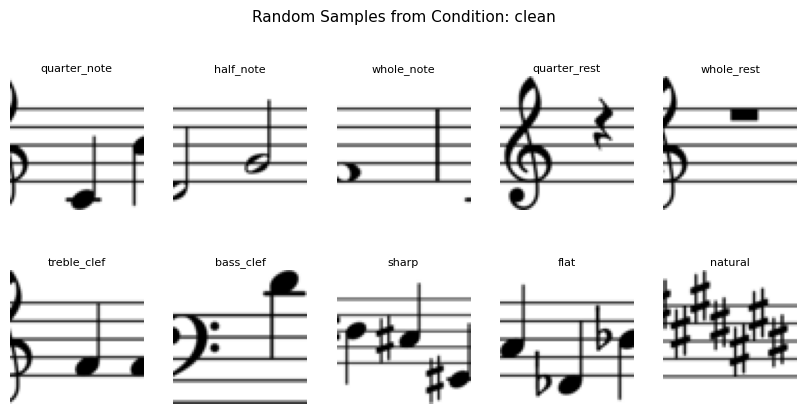

In [25]:
# step 3, part 4: random clean sample visualisation

show_random_samples(
    metadata,
    condition="clean",
    samples_per_class=1,
    n_cols=5,
    random_state=RANDOM_STATE,
)


The clean sample visualisation shows representative **64×64 grayscale** music-symbol images. The samples confirm that the generation and preprocessing pipeline preserved the main visual structures required for classification, while providing the baseline condition for later robustness comparison.

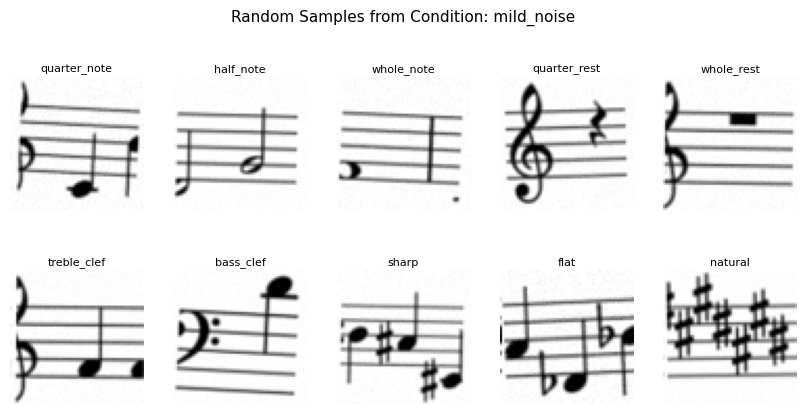

In [301]:
# step 3, part 5: random mild-noise sample visualisation

show_random_samples(
    metadata,
    condition="mild_noise",
    samples_per_class=1,
    n_cols=5,
    random_state=RANDOM_STATE,
)


The mild-noise sample visualisation shows representative **64×64 grayscale** images with controlled perturbations, including slight rotation, scaling, translation, and light background noise. The symbols remain visually recognisable, supporting the use of this subset for robustness evaluation.

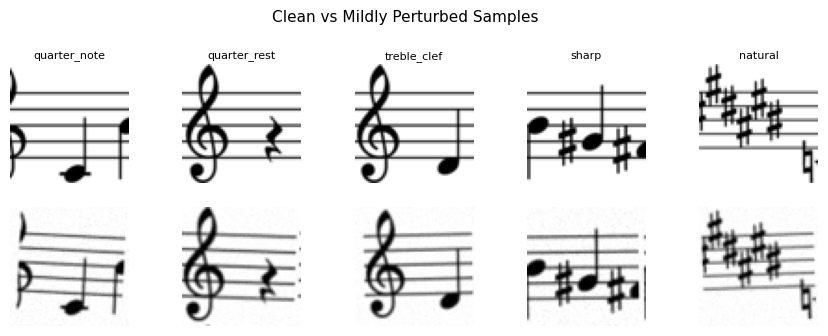

In [296]:
# step 3, part 6: clean vs mild-noise side-by-side comparison

from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image


def get_matching_noise_path(metadata_df, clean_row):
    """Find the corresponding mild_noise image for a clean sample."""
    clean_path = Path(clean_row["filename"])
    clean_filename = clean_path.name
    class_name = clean_row["class"]

    match = metadata_df[
        (metadata_df["class"] == class_name)
        & (metadata_df["condition"] == "mild_noise")
        & (metadata_df["filename"].apply(lambda p: Path(p).name) == clean_filename)
    ]

    if match.empty:
        raise FileNotFoundError(
            f"No matching mild_noise image found for: {clean_filename}"
        )

    return Path(match.iloc[0]["filename"])


def show_clean_vs_noise_pairs(
    metadata_df,
    class_names,
    random_state=42,
):
    """Display one clean/noise pair for each selected class in a grid."""
    n_cols = len(class_names)

    fig, axes = plt.subplots(
        2,
        n_cols,
        figsize=(9, 3.4),
        dpi=100,
    )

    for col_idx, class_name in enumerate(class_names):
        clean_subset = metadata_df[
            (metadata_df["class"] == class_name)
            & (metadata_df["condition"] == "clean")
        ]

        clean_row = clean_subset.sample(
            n=1,
            random_state=random_state + col_idx,
        ).iloc[0]

        clean_path = Path(clean_row["filename"])
        noise_path = get_matching_noise_path(metadata_df, clean_row)

        clean_img = Image.open(clean_path).convert("L")
        noise_img = Image.open(noise_path).convert("L")

        axes[0, col_idx].imshow(clean_img, cmap="gray")
        axes[1, col_idx].imshow(noise_img, cmap="gray")

        axes[0, col_idx].set_title(class_name, fontsize=8, pad=4)

        axes[0, col_idx].axis("off")
        axes[1, col_idx].axis("off")

    axes[0, 0].set_ylabel("Clean", fontsize=9)
    axes[1, 0].set_ylabel("Mild noise", fontsize=9)

    fig.suptitle(
        "Clean vs Mildly Perturbed Samples",
        fontsize=11,
        y=0.98,
    )

    plt.subplots_adjust(
        left=0.04,
        right=0.98,
        bottom=0.05,
        top=0.82,
        wspace=0.10,
        hspace=0.20,
    )

    plt.show()


show_clean_vs_noise_pairs(
    metadata,
    class_names=[
        "quarter_note",
        "quarter_rest",
        "treble_clef",
        "sharp",
        "natural",
    ],
    random_state=RANDOM_STATE,
)


The side-by-side comparison shows paired examples from the `clean` and `mild_noise` conditions. The mild-noise samples contain controlled perturbations, including slight rotation, translation, scaling variation, and light background noise, while preserving the underlying musical symbol identity. This confirms that the perturbations are moderate and suitable for evaluating model robustness under controlled visual variation.

In [31]:
# step 3, part 7: pixel intensity statistics

print("Pixel intensity statistics")
print("--------------------------")
print(f"Minimum pixel value: {X.min():.4f}")
print(f"Maximum pixel value: {X.max():.4f}")
print(f"Mean pixel value:    {X.mean():.4f}")
print(f"Std pixel value:     {X.std():.4f}")


Pixel intensity statistics
--------------------------
Minimum pixel value: 0.0000
Maximum pixel value: 1.0000
Mean pixel value:    0.8461
Std pixel value:     0.2770


The pixel intensity statistics confirm that the image features have been normalised to the range **[0, 1]**, with a minimum value of **0.0000** and a maximum value of **1.0000**. The mean pixel value of **0.8461** suggests that the images are mostly light-coloured, which is expected because the musical symbols are dark marks on a white background.

The standard deviation of **0.2770** indicates that there is still meaningful variation in pixel intensity across the dataset. This normalised representation ensures that all pixel features are on a consistent numerical scale before being used by the classical machine learning models.

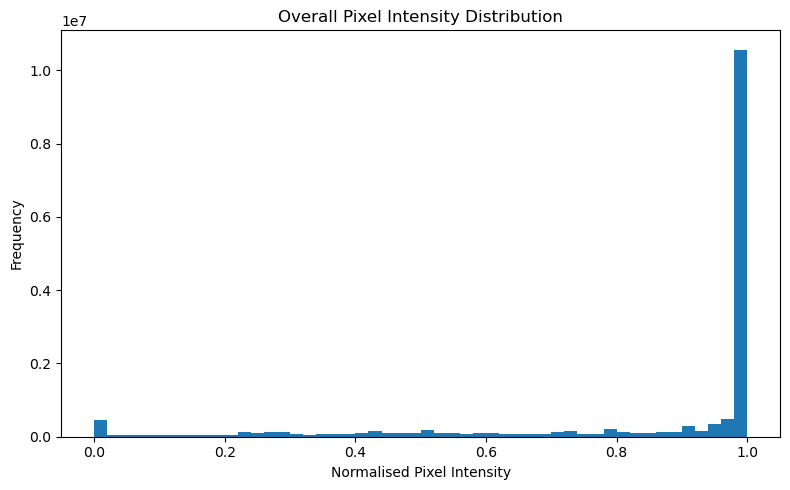

In [33]:
# step 3, part 8: overall pixel intensity histogram

plt.figure(figsize=(8, 5))
plt.hist(X.flatten(), bins=50)
plt.xlabel("Normalised Pixel Intensity")
plt.ylabel("Frequency")
plt.title("Overall Pixel Intensity Distribution")
plt.tight_layout()
plt.show()


The overall pixel intensity histogram shows that most normalised pixel values are concentrated near **1.0**, which corresponds to the white background of the music notation images. Smaller frequencies near **0.0** and across the middle intensity range represent darker musical symbol strokes, staff lines, anti-aliased edges, and mild-noise variation.

This distribution is expected for music notation images because the background occupies most of each 64×64 image, while the notation symbols and staff elements occupy a smaller portion of the pixels. The histogram also confirms that the image data has been normalised to the range **[0, 1]**.

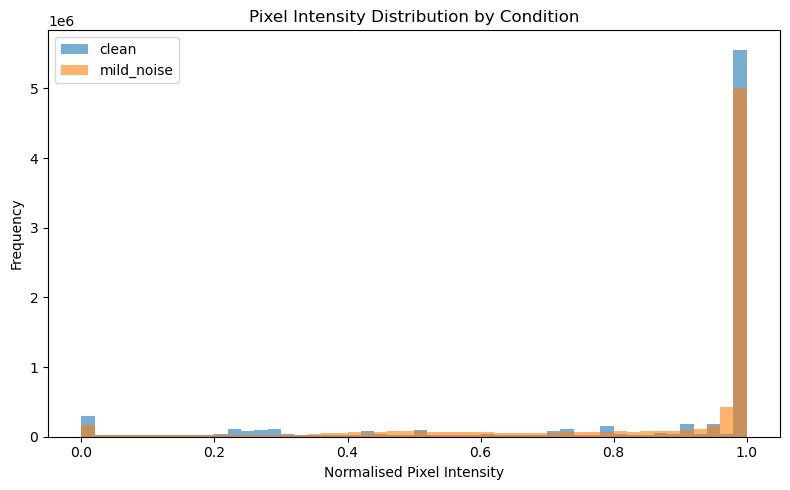

Pixel statistics by condition:


,condition,mean,std,min,max
0,clean,0.838806,0.296611,0.0,1.0
1,mild_noise,0.853367,0.255654,0.0,1.0


In [35]:
# step 3, part 9: pixel intensity distribution by condition

clean_pixels = X[conditions == "clean"]
noise_pixels = X[conditions == "mild_noise"]

plt.figure(figsize=(8, 5))
plt.hist(clean_pixels.flatten(), bins=50, alpha=0.6, label="clean")
plt.hist(noise_pixels.flatten(), bins=50, alpha=0.6, label="mild_noise")
plt.xlabel("Normalised Pixel Intensity")
plt.ylabel("Frequency")
plt.title("Pixel Intensity Distribution by Condition")
plt.legend()
plt.tight_layout()
plt.show()

pixel_stats_by_condition = pd.DataFrame({
    "condition": ["clean", "mild_noise"],
    "mean": [clean_pixels.mean(), noise_pixels.mean()],
    "std": [clean_pixels.std(), noise_pixels.std()],
    "min": [clean_pixels.min(), noise_pixels.min()],
    "max": [clean_pixels.max(), noise_pixels.max()],
})

print("Pixel statistics by condition:")
display(pixel_stats_by_condition)


The pixel intensity comparison shows that both `clean` and `mild_noise` images remain within the same normalised range of **0.0 to 1.0**. Both distributions are concentrated near **1.0**, which reflects the white background of the notation images.

The `mild_noise` condition has a slightly higher mean pixel intensity (**0.8534**) than the clean condition (**0.8388**), while its standard deviation is slightly lower (**0.2556** compared with **0.2966**). This suggests that the perturbed images remain comparable to the clean images while still introducing controlled pixel-level variation for robustness testing.

In [37]:
# step 3, part 10: average image plotting function

def plot_average_image_per_class(X_data, y_labels, title):
    """Plot average images for each class."""
    fig, axes = plt.subplots(
        2,
        5,
        figsize=(8, 3.2),
        dpi=100,
    )

    axes = axes.ravel()

    for idx, class_name in enumerate(CLASS_ORDER):
        class_images = X_data[y_labels == class_name]
        mean_image = class_images.mean(axis=0).reshape(64, 64)

        axes[idx].imshow(mean_image, cmap="gray")
        axes[idx].set_title(class_name, fontsize=8, pad=4)
        axes[idx].axis("off")

    fig.suptitle(title, fontsize=11, y=0.98)

    plt.subplots_adjust(
        left=0.03,
        right=0.97,
        bottom=0.04,
        top=0.82,
        wspace=0.12,
        hspace=0.35,
    )

    plt.show()


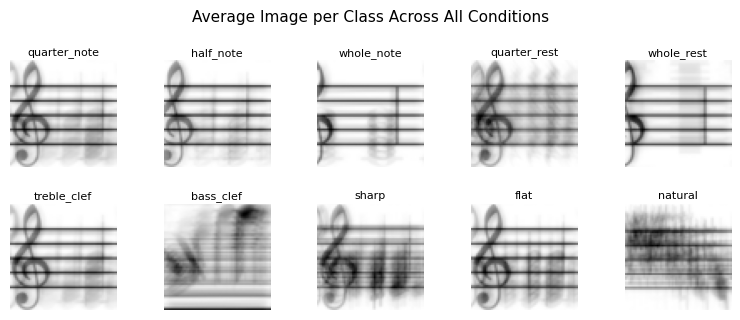

In [39]:
# step 3, part 11: average image per class across all conditions

plot_average_image_per_class(
    X,
    y,
    title="Average Image per Class Across All Conditions"
)


The average image visualisation shows the mean pixel pattern for each musical symbol class across both `clean` and `mild_noise` conditions. Darker regions represent features that appear consistently within a class, while blurred areas reflect variation in symbol placement, pitch position, perturbation, and phrase structure.

The averages show that each class contains recognisable shared visual patterns, such as staff lines, clef shapes, note stems, rests, and accidentals. This supports the suitability of the generated dataset for classification, as the classes contain meaningful common structures while still preserving realistic within-class variation.

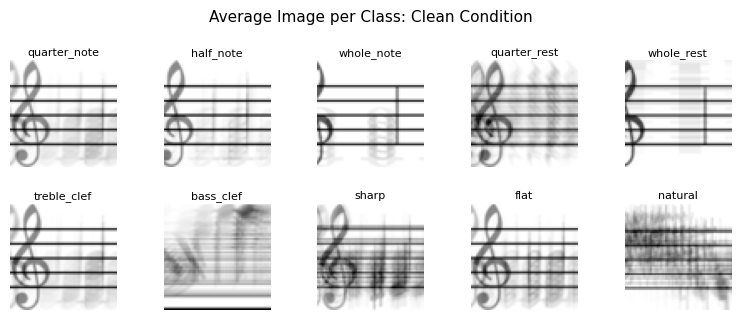

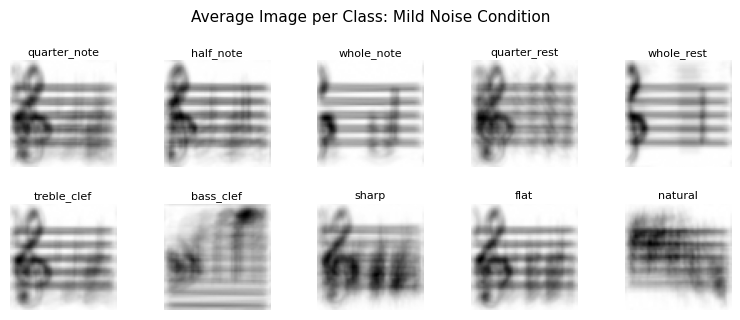

In [41]:
# step 3, part 12: average image per class by condition

plot_average_image_per_class(
    X[conditions == "clean"],
    y[conditions == "clean"],
    title="Average Image per Class: Clean Condition"
)

plot_average_image_per_class(
    X[conditions == "mild_noise"],
    y[conditions == "mild_noise"],
    title="Average Image per Class: Mild Noise Condition"
)


Comparing the average images for the `clean` and `mild_noise` conditions shows that the perturbation process introduces slightly more blur and variation in the mild-noise averages. However, the main class-specific structures remain visible in both conditions.

This indicates that the mild-noise condition adds controlled variation without changing the underlying class identity, making it suitable for robustness evaluation.

In [43]:
# step 3, part 13: sample-level intensity summary

sample_means = X.mean(axis=1)
sample_stds = X.std(axis=1)

eda_summary = pd.DataFrame({
    "class": y,
    "condition": conditions,
    "mean_intensity": sample_means,
    "std_intensity": sample_stds,
})

print("Sample-level intensity summary:")
display(eda_summary.head())


Sample-level intensity summary:


,class,condition,mean_intensity,std_intensity
0,quarter_note,clean,0.836202,0.305068
1,quarter_note,mild_noise,0.861187,0.254358
2,quarter_note,clean,0.843466,0.297700
3,quarter_note,mild_noise,0.858160,0.254950
4,quarter_note,clean,0.843259,0.296201


The sample-level intensity summary records the mean and standard deviation of pixel intensities for each generated image. These statistics provide a compact numerical description of image brightness and pixel-level variation after grayscale conversion and normalisation.

The preview confirms that both `clean` and `mild_noise` samples are represented in the dataset. For example, the displayed `quarter_note` samples show mean intensity values in a similar range for both conditions, while the standard deviation values differ slightly between clean and perturbed samples. These differences are expected because the `mild_noise` condition introduces controlled image transformations and noise while preserving the underlying musical symbol identity.

Overall, this summary supports the dataset validation process by showing that the images are numerically consistent, normalised, and suitable for downstream machine learning analysis. At the same time, the small condition-level differences indicate that the perturbation process introduced measurable variation for later robustness evaluation.

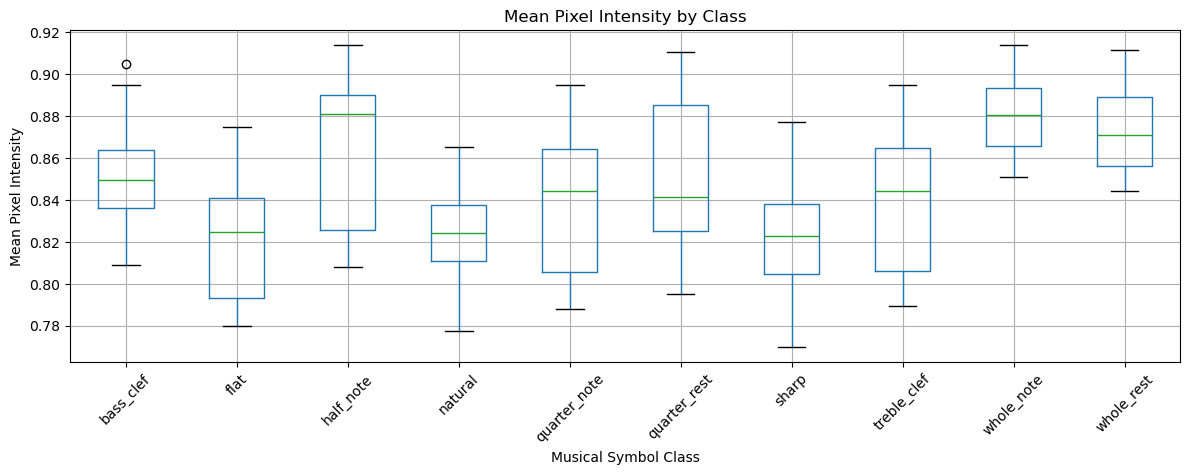

In [45]:
# step 3, part 14: mean pixel intensity by class

fig, ax = plt.subplots(figsize=(12, 5))

eda_summary.boxplot(
    column="mean_intensity",
    by="class",
    rot=45,
    ax=ax
)

ax.set_title("Mean Pixel Intensity by Class")
ax.set_xlabel("Musical Symbol Class")
ax.set_ylabel("Mean Pixel Intensity")

plt.suptitle("")
plt.tight_layout()
plt.show()


The mean pixel intensity boxplot compares the distribution of average image brightness across the ten musical symbol classes. The median values and spread differ slightly between classes, reflecting variation in symbol density, stroke thickness, and the amount of white background present after image standardisation.

Although the classes show overlapping intensity ranges, the plot indicates that each class has its own brightness characteristics. This provides a useful descriptive summary of low-level visual variation in the dataset before model training.

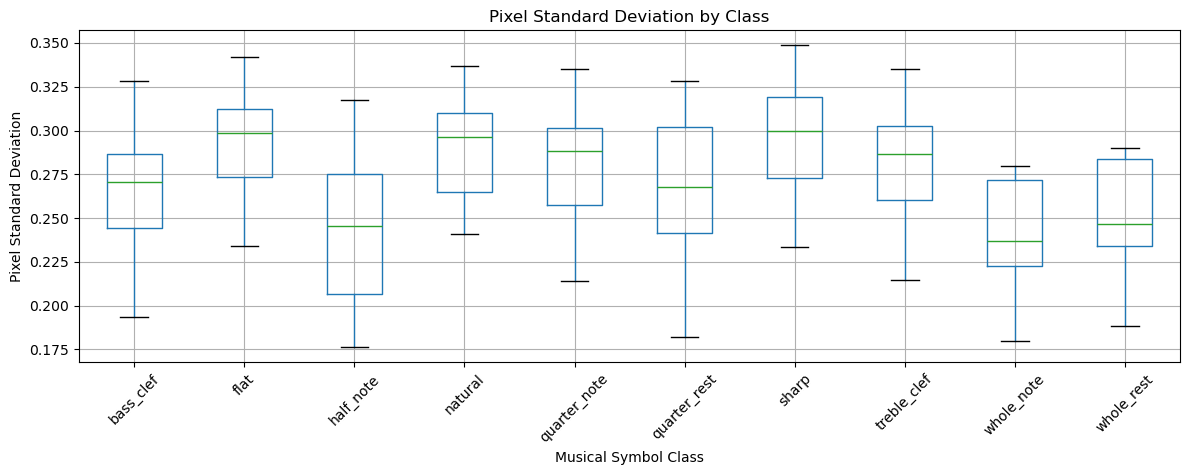

In [47]:
# step 3, part 15: pixel standard deviation by class

fig, ax = plt.subplots(figsize=(12, 5))

eda_summary.boxplot(
    column="std_intensity",
    by="class",
    rot=45,
    ax=ax
)

ax.set_title("Pixel Standard Deviation by Class")
ax.set_xlabel("Musical Symbol Class")
ax.set_ylabel("Pixel Standard Deviation")

plt.suptitle("")
plt.tight_layout()
plt.show()


The pixel standard deviation boxplot compares pixel-level intensity variation across the musical symbol classes. Higher values indicate stronger contrast between dark notation strokes, staff lines, and the white background, while lower values suggest simpler or less visually dense symbols.

The plot shows that some classes have greater intensity variation than others, reflecting differences in symbol density, stroke structure, and visual complexity. This provides a useful descriptive summary of low-level image variation before model training.

In [49]:
# step 3, part 16: final exploratory analysis summary

print("Exploratory analysis completed.")
print("The dataset is balanced across classes and conditions.")
print("Clean and mild_noise images are visually comparable while preserving class identity.")
print("Pixel intensities are normalised to [0, 1], confirming readiness for classical ML models.")


Exploratory analysis completed.
The dataset is balanced across classes and conditions.
Clean and mild_noise images are visually comparable while preserving class identity.
Pixel intensities are normalised to [0, 1], confirming readiness for classical ML models.


**Step 4: Label Encoding and Train-Validation-Test Split**

In [51]:
# step 4, part 1: label encoding 

"""
Label Encoding Pipeline
-----------------------

This section encodes the symbolic musical class labels into numerical labels
for supervised machine learning models.
"""

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from collections import Counter


# =======================
# label encoding
# =======================

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

class_names = label_encoder.classes_
num_classes = len(class_names)

print("Encoded class labels:")
for idx, class_name in enumerate(class_names):
    print(f"{idx}: {class_name}")

print("\nNumber of classes:", num_classes)


Encoded class labels:
0: bass_clef
1: flat
2: half_note
3: natural
4: quarter_note
5: quarter_rest
6: sharp
7: treble_clef
8: whole_note
9: whole_rest

Number of classes: 10


The symbolic class labels were encoded into numerical labels using `LabelEncoder`. The output confirms that the ten musical symbol classes were mapped to integer labels from **0 to 9**.

This conversion is required because supervised machine learning models use numerical target values during training and evaluation. The encoded labels were stored in `y_encoded`, while the original class names were preserved in `class_names` for interpreting predictions, classification reports, and confusion matrices.

In [53]:
# step 4, part 2: stratification label construction

"""
Stratification Label Construction
---------------------------------

This section creates combined stratification labels using both class label and
condition. This ensures that the train, validation, and test sets preserve the
distribution of both musical symbol classes and perturbation conditions.
"""

# Stratify by BOTH class and condition.
# Example: "quarter_note_clean", "quarter_note_mild_noise"
stratify_labels = np.array([
    f"{label}_{cond}" for label, cond in zip(y, conditions)
])

print("Stratification group distribution:")
display(
    pd.DataFrame.from_dict(
        Counter(stratify_labels),
        orient="index",
        columns=["sample_count"]
    ).sort_index()
)


Stratification group distribution:


,sample_count
bass_clef_clean,200
bass_clef_mild_noise,200
flat_clean,200
flat_mild_noise,200
half_note_clean,200
half_note_mild_noise,200
natural_clean,200
natural_mild_noise,200
quarter_note_clean,200
quarter_note_mild_noise,200


A combined stratification label was created using both the musical symbol class and the dataset condition. The output confirms that each class-condition group contains **200 samples**, giving balanced representation across all ten classes under both `clean` and `mild_noise` conditions.

This ensures that the train, validation, and test splits preserve both class balance and condition balance, which is important for fair model comparison and later robustness evaluation.

In [55]:
# step 4, part 3: train-validation-test split

"""
Train-Validation-Test Split
---------------------------

This section divides the dataset into training, validation, and test subsets.
The first split produces a 70% training set and a 30% temporary set. The
temporary set is then split equally into 15% validation and 15% test sets.
"""

# =======================
# train / temporary split
# =======================

X_train, X_temp, y_train, y_temp, cond_train, cond_temp, file_train, file_temp, strat_train, strat_temp = train_test_split(
    X,
    y_encoded,
    conditions,
    filenames,
    stratify_labels,
    test_size=0.30,
    random_state=42,
    stratify=stratify_labels
)


# =======================
# validation / test split
# =======================

X_val, X_test, y_val, y_test, cond_val, cond_test, file_val, file_test = train_test_split(
    X_temp,
    y_temp,
    cond_temp,
    file_temp,
    test_size=0.50,
    random_state=42,
    stratify=strat_temp
)

print("Train-validation-test split completed.")
print("Training set:   70%")
print("Validation set: 15%")
print("Test set:       15%")


Train-validation-test split completed.
Training set:   70%
Validation set: 15%
Test set:       15%


The dataset was split into training, validation, and test subsets using a **70:15:15 split**. The training set was used to fit the models, the validation set was used for model selection and hyperparameter comparison, and the test set was reserved for final evaluation.

Stratification was applied during splitting to preserve the balance of musical symbol classes and perturbation conditions across all subsets. This supports fair model comparison and robustness evaluation.

In [57]:
# step 4, part 4: split distribution summary

"""
Split Distribution Summary
--------------------------

This section verifies that the train, validation, and test sets preserve the
expected sample sizes, class distributions, and condition distributions.
"""

print("Dataset split summary")
print("---------------------")
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)


# =======================
# condition distribution
# =======================

condition_split_summary = pd.DataFrame({
    "train": pd.Series(Counter(cond_train)),
    "validation": pd.Series(Counter(cond_val)),
    "test": pd.Series(Counter(cond_test)),
}).fillna(0).astype(int)

print("\nCondition distribution by split:")
display(condition_split_summary)


# =======================
# class distribution
# =======================

train_class_counts = Counter(label_encoder.inverse_transform(y_train))
val_class_counts = Counter(label_encoder.inverse_transform(y_val))
test_class_counts = Counter(label_encoder.inverse_transform(y_test))

class_split_summary = pd.DataFrame({
    "train": pd.Series(train_class_counts),
    "validation": pd.Series(val_class_counts),
    "test": pd.Series(test_class_counts),
}).fillna(0).astype(int).sort_index()

print("\nClass distribution by split:")
display(class_split_summary)


Dataset split summary
---------------------
X_train: (2800, 4096)
X_val:   (600, 4096)
X_test:  (600, 4096)

y_train: (2800,)
y_val:   (600,)
y_test:  (600,)

Condition distribution by split:


,train,validation,test
clean,1400,300,300
mild_noise,1400,300,300



Class distribution by split:


,train,validation,test
bass_clef,280,60,60
flat,280,60,60
half_note,280,60,60
natural,280,60,60
quarter_note,280,60,60
quarter_rest,280,60,60
sharp,280,60,60
treble_clef,280,60,60
whole_note,280,60,60
whole_rest,280,60,60


The split summary confirms that the dataset was divided into the intended **70:15:15** proportions, with **2800 training samples**, **600 validation samples**, and **600 test samples**. Each sample remains represented by a **4096-dimensional** flattened image feature vector.

The condition distribution shows that both `clean` and `mild_noise` samples are evenly preserved across all splits. The class distribution also confirms that each musical symbol class has **280 training**, **60 validation**, and **60 test** samples. This demonstrates that stratified splitting successfully maintained both class and condition balance for fair model training and evaluation.

In [59]:
# step 4, part 5: clean and mild-noise subsets

"""
Condition-Specific Subsets
--------------------------

This section separates each split into clean and mild-noise subsets. These
subsets are used later to evaluate model robustness under perturbation.
"""

# =======================
# masks by condition
# =======================

train_clean_mask = cond_train == "clean"
train_noise_mask = cond_train == "mild_noise"

val_clean_mask = cond_val == "clean"
val_noise_mask = cond_val == "mild_noise"

test_clean_mask = cond_test == "clean"
test_noise_mask = cond_test == "mild_noise"


# =======================
# training subsets
# =======================

X_train_clean = X_train[train_clean_mask]
y_train_clean = y_train[train_clean_mask]

X_train_noise = X_train[train_noise_mask]
y_train_noise = y_train[train_noise_mask]


# =======================
# validation subsets
# =======================

X_val_clean = X_val[val_clean_mask]
y_val_clean = y_val[val_clean_mask]

X_val_noise = X_val[val_noise_mask]
y_val_noise = y_val[val_noise_mask]


# =======================
# test subsets
# =======================

X_test_clean = X_test[test_clean_mask]
y_test_clean = y_test[test_clean_mask]

X_test_noise = X_test[test_noise_mask]
y_test_noise = y_test[test_noise_mask]


# =======================
# subset summary
# =======================

condition_subset_summary = pd.DataFrame({
    "subset": [
        "X_train_clean",
        "X_train_noise",
        "X_val_clean",
        "X_val_noise",
        "X_test_clean",
        "X_test_noise",
    ],
    "shape": [
        X_train_clean.shape,
        X_train_noise.shape,
        X_val_clean.shape,
        X_val_noise.shape,
        X_test_clean.shape,
        X_test_noise.shape,
    ],
})

print("Condition-specific subsets:")
display(condition_subset_summary)


Condition-specific subsets:


,subset,shape
0,X_train_clean,"(1400, 4096)"
1,X_train_noise,"(1400, 4096)"
2,X_val_clean,"(300, 4096)"
3,X_val_noise,"(300, 4096)"
4,X_test_clean,"(300, 4096)"
5,X_test_noise,"(300, 4096)"


Condition-specific subsets were created to support separate evaluation on `clean` and `mild_noise` images. The output confirms that the training set contains **1400 clean** and **1400 mild-noise** samples, while the validation and test sets each contain **300 clean** and **300 mild-noise** samples.

These subsets allow each model to be evaluated separately on clean and perturbed images. This supports robustness analysis by measuring the accuracy drop from clean-test images to mild-noise test images.

In [65]:
# step 4, part 6: final integrity checks

"""
Final Split Integrity Checks
----------------------------

This section performs final checks to confirm that the split is complete,
dimensionally consistent, and contains all expected classes.
"""

import numpy as np
import math

# =======================
# sample count checks
# =======================

assert X_train.shape[0] + X_val.shape[0] + X_test.shape[0] == X.shape[0], (
    "Train, validation, and test sample counts do not add up to the full dataset size."
)

assert len(y_train) == X_train.shape[0], "Mismatch between X_train and y_train."
assert len(y_val) == X_val.shape[0], "Mismatch between X_val and y_val."
assert len(y_test) == X_test.shape[0], "Mismatch between X_test and y_test."


# =======================
# feature dimension checks
# =======================

# prefer FINAL_SIZE if it exists; otherwise infer directly from X
if "FINAL_SIZE" in globals():
    expected_feature_count = FINAL_SIZE * FINAL_SIZE
else:
    expected_feature_count = X.shape[1]

    inferred_size = int(math.sqrt(expected_feature_count))

    if inferred_size * inferred_size == expected_feature_count:
        FINAL_SIZE = inferred_size
    else:
        FINAL_SIZE = "unknown"

assert X_train.shape[1] == expected_feature_count, (
    f"Expected {expected_feature_count} features in X_train, "
    f"but found {X_train.shape[1]}."
)

assert X_val.shape[1] == expected_feature_count, (
    f"Expected {expected_feature_count} features in X_val, "
    f"but found {X_val.shape[1]}."
)

assert X_test.shape[1] == expected_feature_count, (
    f"Expected {expected_feature_count} features in X_test, "
    f"but found {X_test.shape[1]}."
)


# =======================
# class coverage checks
# =======================

# Prefer existing num_classes if available; otherwise infer from y
if "num_classes" in globals():
    expected_num_classes = num_classes
else:
    expected_num_classes = len(np.unique(y))

assert len(np.unique(y_train)) == expected_num_classes, (
    "Training set does not contain all classes."
)

assert len(np.unique(y_val)) == expected_num_classes, (
    "Validation set does not contain all classes."
)

assert len(np.unique(y_test)) == expected_num_classes, (
    "Test set does not contain all classes."
)


# =======================
# final confirmation
# =======================

print("Final split integrity checks passed.")
print("Label encoding and train/validation/test split completed successfully.")

print(f"Full dataset shape:       {X.shape}")
print(f"Training set shape:       {X_train.shape}")
print(f"Validation set shape:     {X_val.shape}")
print(f"Test set shape:           {X_test.shape}")
print(f"Feature count per image:  {expected_feature_count}")
print(f"Inferred image size:      {FINAL_SIZE} x {FINAL_SIZE}")
print(f"Number of classes:        {expected_num_classes}")


Final split integrity checks passed.
Label encoding and train/validation/test split completed successfully.
Full dataset shape:       (4000, 4096)
Training set shape:       (2800, 4096)
Validation set shape:     (600, 4096)
Test set shape:           (600, 4096)
Feature count per image:  4096
Inferred image size:      64 x 64
Number of classes:        10


Final integrity checks were performed to confirm that the three splits contain all samples from the full dataset, preserve the expected 4096-dimensional feature representation, and include all ten musical symbol classes. These checks confirm that the encoded and split dataset is ready for supervised model training.

**Step 5: Baseline Modelling with kNN from Scratch**

In [67]:
# step 5, part 1: from-scratch kNN implementation

"""
Baseline Modelling with kNN from Scratch
----------------------------------------

This section implements the k-Nearest Neighbours classifier manually using
NumPy. The classifier stores the training data, computes Euclidean distances,
selects the nearest neighbours, and predicts the majority class label.

This implementation is used as the baseline supervised model before comparing
against PCA-based kNN and other classical machine learning algorithms.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


class KNearestNeighbours:
    """
    k-Nearest Neighbours classifier implemented from scratch.

    Parameters
    ----------
    k : int
        Number of nearest neighbours used for majority voting.
    """

    def __init__(self, k: int = 3):
        if k <= 0:
            raise ValueError("k must be a positive integer.")

        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X_train: np.ndarray, y_train: np.ndarray) -> None:
        """
        Store the training data.

        kNN is a lazy learning algorithm; no explicit parameter learning occurs.
        """
        self.X_train = X_train.astype(np.float32)
        self.y_train = y_train

    def _euclidean_distances(self, X_batch: np.ndarray) -> np.ndarray:
        """
        Compute Euclidean distances between a batch of test samples and all
        training samples using a vectorised distance calculation.
        """
        X_batch = X_batch.astype(np.float32)

        X_batch_sq = np.sum(X_batch ** 2, axis=1, keepdims=True)
        X_train_sq = np.sum(self.X_train ** 2, axis=1)

        distances_sq = (
            X_batch_sq
            + X_train_sq
            - 2 * np.dot(X_batch, self.X_train.T)
        )

        distances_sq = np.maximum(distances_sq, 0)

        return np.sqrt(distances_sq)

    def predict(self, X_test: np.ndarray, batch_size: int = 100) -> np.ndarray:
        """
        Predict labels for test samples using batch processing.
        """
        if self.X_train is None or self.y_train is None:
            raise ValueError("Model has not been fitted yet.")

        predictions = []

        for start in range(0, len(X_test), batch_size):
            end = start + batch_size
            X_batch = X_test[start:end]

            distances = self._euclidean_distances(X_batch)

            nearest_indices = np.argsort(distances, axis=1)[:, :self.k]
            nearest_labels = self.y_train[nearest_indices]

            for labels in nearest_labels:
                vote_counts = Counter(labels)
                predicted_label = vote_counts.most_common(1)[0][0]
                predictions.append(predicted_label)

        return np.array(predictions)


print("From-scratch kNN classifier defined successfully.")


From-scratch kNN classifier defined successfully.


The kNN classifier was implemented from scratch using NumPy rather than a pre-existing machine learning classifier library. The implementation stores the training data, computes Euclidean distances between validation/test samples and training samples, selects the `k` nearest neighbours, and applies majority voting to assign the predicted class label. Batch prediction was used to reduce memory usage when computing distances over the full image dataset.

In [69]:
# step 5, part 2: validation-based search for k

k_values = [1, 3, 5, 7, 9]
validation_results = []

for k in k_values:
    knn = KNearestNeighbours(k=k)
    knn.fit(X_train, y_train)

    y_val_pred = knn.predict(X_val, batch_size=100)
    val_accuracy = accuracy_score(y_val, y_val_pred)

    validation_results.append({
        "k": k,
        "validation_accuracy": val_accuracy
    })

validation_results_df = pd.DataFrame(validation_results)

print("Validation accuracy for different k values:")
display(validation_results_df)


Validation accuracy for different k values:


,k,validation_accuracy
0,1,0.730000
1,3,0.711667
2,5,0.688333
3,7,0.671667
4,9,0.640000


A validation-based search was performed to select the optimal value of `k` for the manually implemented k-Nearest Neighbours classifier. The tested values were `k = 1`, `3`, `5`, `7`, and `9`.

The results show that `k = 1` achieved the highest validation accuracy of **0.7300**. Validation accuracy then decreased as `k` increased, falling to **0.7117** for `k = 3`, **0.6883** for `k = 5`, **0.6717** for `k = 7`, and **0.6400** for `k = 9`.

This pattern suggests that larger neighbourhoods over-smoothed the decision boundary for the raw flattened pixel representation. Since the feature space is high-dimensional and symbol classes may occupy relatively localised regions, using a larger neighbourhood may introduce less relevant neighbouring samples into the voting process.

Therefore, `k = 1` was selected as the final value for the from-scratch raw-pixel kNN baseline model.

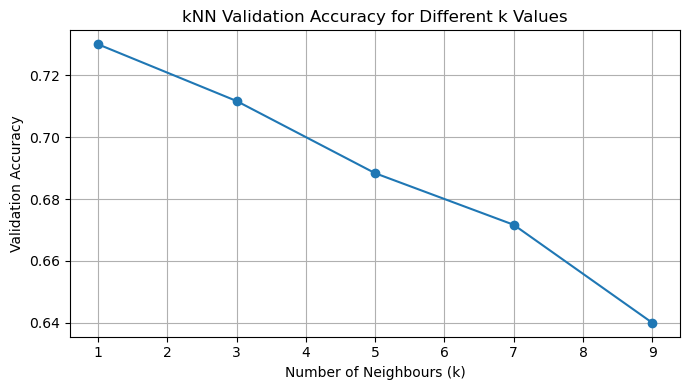

In [70]:
# step 5, part 3: plot kNN validation accuracy

plt.figure(figsize=(7, 4))

plt.plot(
    validation_results_df["k"],
    validation_results_df["validation_accuracy"],
    marker="o"
)

plt.xlabel("Number of Neighbours (k)")
plt.ylabel("Validation Accuracy")
plt.title("kNN Validation Accuracy for Different k Values")
plt.grid(True)
plt.tight_layout()
plt.show()


The validation accuracy plot shows that the from-scratch raw-pixel kNN model achieved its strongest validation performance when `k = 1`, with a validation accuracy of **0.7300**.

As `k` increased from **1** to **9**, validation accuracy decreased steadily. This indicates that larger neighbourhood sizes reduced classification performance for the original 4096-dimensional flattened pixel representation. The decline suggests that broader neighbourhood voting may have blurred class boundaries between visually similar musical symbols.

This result supports the selection of `k = 1` for the final raw-pixel kNN baseline. The selected setting preserves highly local nearest-neighbour behaviour, which was most effective for this dataset during validation.

In [73]:
# step 5, part 4: select best k and train final kNN model

best_k = int(
    validation_results_df
    .sort_values(by="validation_accuracy", ascending=False)
    .iloc[0]["k"]
)

knn_final = KNearestNeighbours(k=best_k)
knn_final.fit(X_train, y_train)

print(f"Best k selected from validation set: {best_k}")
print("Final kNN baseline model trained successfully.")


Best k selected from validation set: 1
Final kNN baseline model trained successfully.


The best value selected from the validation search was `k = 1`. The final from-scratch kNN baseline model was then fitted using the full training set.

Because kNN is a lazy learning algorithm, the fitting stage does not involve iterative parameter optimisation. Instead, the model stores the training feature vectors and labels, and prediction is performed by computing distances between each test sample and the stored training samples.

This configuration establishes the raw-pixel nearest-neighbour baseline before later evaluating whether PCA dimensionality reduction and alternative supervised classifiers can improve performance.

In [75]:
# step 5, part 5: final kNN validation and test evaluation

y_val_pred_knn = knn_final.predict(X_val, batch_size=100)
y_test_pred_knn = knn_final.predict(X_test, batch_size=100)

val_accuracy_knn = accuracy_score(y_val, y_val_pred_knn)
test_accuracy_knn = accuracy_score(y_test, y_test_pred_knn)

knn_performance_summary = pd.DataFrame([{
    "model": "kNN_from_scratch",
    "best_k": best_k,
    "validation_accuracy": val_accuracy_knn,
    "test_accuracy": test_accuracy_knn,
}])

print("Final kNN performance summary:")
display(knn_performance_summary)


Final kNN performance summary:


,model,best_k,validation_accuracy,test_accuracy
0,kNN_from_scratch,1,0.73,0.72


The final from-scratch kNN baseline model achieved a validation accuracy of **0.7300** and a held-out test accuracy of **0.7200** using `k = 1`.

The relatively close validation and test scores suggest that the model generalised consistently to unseen data. However, the overall test accuracy remained moderate, indicating that direct nearest-neighbour classification in the original 4096-dimensional pixel space was limited by the high-dimensional and noise-sensitive nature of flattened image features.

This result establishes the raw-pixel kNN baseline for comparison with the later PCA+kNN model and the other supervised classifiers.

In [77]:
# step 5, part 6: kNN classification report

knn_report = classification_report(
    y_test,
    y_test_pred_knn,
    target_names=class_names,
    output_dict=True
)

knn_report_df = pd.DataFrame(knn_report).transpose()

print("kNN classification report on test set:")
display(knn_report_df.round(4))


kNN classification report on test set:


,precision,recall,f1-score,support
bass_clef,1.0000,0.9667,0.9831,60.00
flat,0.6226,0.5500,0.5841,60.00
half_note,0.8413,0.8833,0.8618,60.00
natural,0.9818,0.9000,0.9391,60.00
quarter_note,0.4127,0.4333,0.4228,60.00
quarter_rest,0.9388,0.7667,0.8440,60.00
sharp,0.8511,0.6667,0.7477,60.00
treble_clef,0.3019,0.2667,0.2832,60.00
whole_note,0.6067,0.9000,0.7248,60.00
whole_rest,0.7429,0.8667,0.8000,60.00


The kNN classification report shows that the final from-scratch raw-pixel kNN baseline achieved an overall held-out test accuracy of **0.7200**, with a macro F1-score of **0.7191** and a weighted F1-score of **0.7191**. Since each class contains **60 test samples**, the macro and weighted averages are identical.

The model performed strongly on visually distinctive classes such as `bass_clef`, `natural`, `half_note`, `quarter_rest`, and `whole_rest`. These classes achieved comparatively high precision, recall, and F1-score values, suggesting that their visual structures were easier to distinguish using direct pixel-space similarity.

However, performance was weaker for `quarter_note` and `treble_clef`. The `quarter_note` class achieved an F1-score of **0.4228**, while `treble_clef` achieved an F1-score of **0.2832**. These results indicate that the raw-pixel kNN baseline struggled with visually complex or overlapping symbol structures.

Overall, the classification report shows that the manually implemented kNN classifier provides a meaningful baseline, but direct distance-based comparison in the original pixel space does not separate all musical symbol classes equally well.

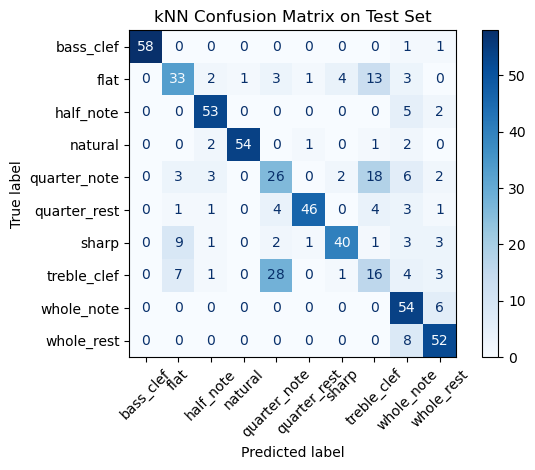

In [79]:
# step 5, part 7: kNN confusion matrix

cm_knn = confusion_matrix(y_test, y_test_pred_knn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("kNN Confusion Matrix on Test Set")
plt.tight_layout()
plt.show()


The kNN confusion matrix shows that the from-scratch raw-pixel kNN baseline correctly classified several classes with reasonable consistency, including `bass_clef`, `half_note`, `natural`, `whole_note`, and `whole_rest`.

However, the confusion matrix also reveals noticeable misclassification among visually similar or structurally complex symbols. In particular, `quarter_note` and `treble_clef` show weaker separation, which is consistent with their lower F1-score values in the classification report.

Some confusion is also visible among symbols with compact or overlapping visual structures, such as accidentals and note-based classes. This suggests that raw pixel-space distance is not always sufficient to capture the semantic differences between visually similar music-symbol categories.

Overall, the confusion matrix confirms that the raw-pixel kNN model captures useful local similarity patterns, but remains limited when classes share overlapping geometric or staff-line structures.

In [81]:
# step 5, part 8: clean vs mild-noise robustness evaluation

y_test_clean_pred_knn = knn_final.predict(X_test_clean, batch_size=100)
y_test_noise_pred_knn = knn_final.predict(X_test_noise, batch_size=100)

clean_accuracy_knn = accuracy_score(y_test_clean, y_test_clean_pred_knn)
noise_accuracy_knn = accuracy_score(y_test_noise, y_test_noise_pred_knn)

accuracy_drop_knn = clean_accuracy_knn - noise_accuracy_knn

knn_robustness_summary = pd.DataFrame([{
    "model": "kNN_from_scratch",
    "clean_test_accuracy": clean_accuracy_knn,
    "mild_noise_test_accuracy": noise_accuracy_knn,
    "accuracy_drop_clean_to_noise": accuracy_drop_knn,
}])

print("kNN robustness evaluation:")
display(knn_robustness_summary.round(4))


kNN robustness evaluation:


,model,clean_test_accuracy,mild_noise_test_accuracy,accuracy_drop_clean_to_noise
0,kNN_from_scratch,0.87,0.57,0.3


The kNN robustness evaluation shows that the from-scratch raw-pixel kNN baseline achieved a clean-test accuracy of **0.8700**, but decreased to **0.5700** on the `mild_noise` test subset. This produced a clean-to-noise accuracy drop of **0.3000**.

This substantial drop indicates that direct nearest-neighbour classification in the original flattened pixel space is sensitive to controlled perturbations such as mild noise, rotation, scaling, and translation. Small visual changes can alter pixel-level distances, causing perturbed samples to move closer to less appropriate neighbours in feature space.

Although the raw kNN model provides a useful baseline, its robustness under perturbation is limited. This motivates the later use of PCA dimensionality reduction and alternative supervised classifiers to improve feature stability and generalisation.

In [83]:
# step 5, part 9: store kNN results

knn_results = {
    "model": "kNN_from_scratch",
    "best_k": best_k,
    "validation_accuracy": val_accuracy_knn,
    "test_accuracy": test_accuracy_knn,
    "clean_test_accuracy": clean_accuracy_knn,
    "mild_noise_test_accuracy": noise_accuracy_knn,
    "accuracy_drop_clean_to_noise": accuracy_drop_knn,
}

knn_results_df = pd.DataFrame([knn_results])

print("Stored kNN baseline results:")
display(knn_results_df.round(4))

print("\nkNN baseline modelling completed successfully.")


Stored kNN baseline results:


,model,best_k,validation_accuracy,test_accuracy,clean_test_accuracy,mild_noise_test_accuracy,accuracy_drop_clean_to_noise
0,kNN_from_scratch,1,0.73,0.72,0.87,0.57,0.3



kNN baseline modelling completed successfully.


The kNN baseline results were stored in a summary dataframe for later comparison with the other supervised classifiers. The stored metrics include selected `k`, validation accuracy, held-out test accuracy, clean-test accuracy, mild-noise accuracy, and clean-to-noise accuracy drop.

The final raw-pixel kNN model used `k = 1`. It achieved a validation accuracy of **0.7300**, a held-out test accuracy of **0.7200**, a clean-test accuracy of **0.8700**, and a mild-noise accuracy of **0.5700**. The resulting robustness drop was **0.3000**.

These results confirm that the manually implemented kNN classifier is a meaningful baseline for the classification task. However, the large performance decrease under `mild_noise` shows that raw pixel-space nearest-neighbour classification is sensitive to controlled visual perturbations.

**Step 6: PCA-Based Dimensionality Reduction and PCA + kNN Comparison**

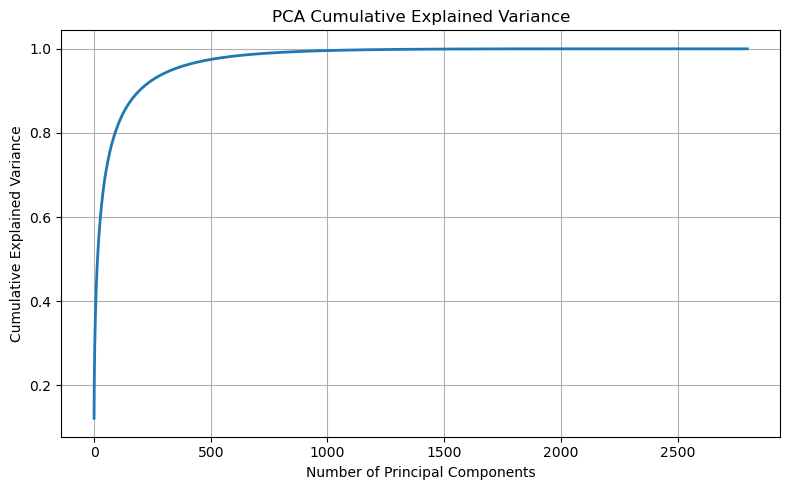

In [85]:
# step 6, part 1: PCA variance analysis

"""
PCA-Based Dimensionality Reduction
----------------------------------

This section applies Principal Component Analysis (PCA) to analyse how much
variance can be retained when reducing the original 4096-dimensional raw pixel
representation into a lower-dimensional feature space.

PCA is fitted only on the training set to avoid data leakage. The fitted PCA
transformation is then reused for validation and test data in later sections.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA


# =======================
# PCA variance analysis
# =======================

pca_full = PCA(random_state=42)
pca_full.fit(X_train)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance, linewidth=2)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.grid(True)
plt.tight_layout()
plt.show()


The PCA cumulative explained variance plot shows how variance is progressively retained as additional principal components are included. The curve rises steeply in the early components, indicating that a relatively small subset of principal components captures a substantial proportion of the variance from the original **4096-dimensional** flattened pixel feature space.

The curve then gradually flattens as it approaches 1.0, showing that later components contribute progressively smaller amounts of additional variance. This suggests that the image feature space contains considerable redundancy and can be compressed into a lower-dimensional representation while preserving much of the dominant variance structure.

PCA was fitted only on the training set before being applied to the validation and test subsets. This procedure prevents data leakage and ensures that dimensionality reduction is learned exclusively from the training distribution.

In [86]:
# step 6, part 2: explained variance threshold summary

thresholds = [0.80, 0.90, 0.95, 0.99]

pca_threshold_summary = []

for threshold in thresholds:
    n_components = np.argmax(cumulative_variance >= threshold) + 1

    pca_threshold_summary.append({
        "variance_threshold": threshold,
        "n_components_required": n_components
    })

pca_threshold_df = pd.DataFrame(pca_threshold_summary)

print("Number of PCA components required for selected variance thresholds:")
display(pca_threshold_df)


Number of PCA components required for selected variance thresholds:


,variance_threshold,n_components_required
0,0.80,91
1,0.90,194
2,0.95,336
3,0.99,754


The PCA threshold summary reports the number of principal components required to retain selected proportions of training-set variance. Retaining **80%** of the variance required **91 components**, while retaining **90%**, **95%**, and **99%** required **194**, **336**, and **754** components respectively.

These results show that the original **4096-dimensional** pixel feature space can be substantially reduced while preserving most of the dataset variance. Even the 99% threshold requires far fewer components than the original feature dimension, indicating that the image representations contain meaningful lower-dimensional structure.

This analysis provides a quantitative basis for selecting PCA dimensions before evaluating the PCA+kNN classifier. It also supports the broader methodological aim of examining whether dimensionality reduction can improve feature compactness and classification behaviour.

In [87]:
# step 6, part 3: selected PCA component comparison

pca_component_options = [20, 50, 100, 150]

pca_summary_rows = []

for n_components in pca_component_options:
    pca = PCA(n_components=n_components, random_state=42)
    pca.fit(X_train)

    explained_variance = np.sum(pca.explained_variance_ratio_)

    pca_summary_rows.append({
        "n_components": n_components,
        "explained_variance_ratio": explained_variance
    })

pca_summary_df = pd.DataFrame(pca_summary_rows)

print("Explained variance for selected PCA dimensions:")
display(pca_summary_df.round(4))


Explained variance for selected PCA dimensions:


,n_components,explained_variance_ratio
0,20,0.5414
1,50,0.7021
2,100,0.8140
3,150,0.8698


The selected PCA component comparison evaluates **20**, **50**, **100**, and **150** components as candidate dimensionality settings for the later PCA+kNN experiment. These settings reduce the original **4096-dimensional** feature space to progressively larger compressed representations.

The results show that **20 components** retain **0.5414** of the training-set variance, while **50 components** retain **0.7021**, **100 components** retain **0.8140**, and **150 components** retain **0.8698**. As expected, explained variance increases as more components are retained.

This comparison illustrates the trade-off between dimensionality reduction and information preservation. Lower-dimensional representations are computationally more compact, while higher-dimensional representations retain more variance. The subsequent validation search therefore evaluates whether increased variance retention necessarily improves PCA+kNN classification accuracy.

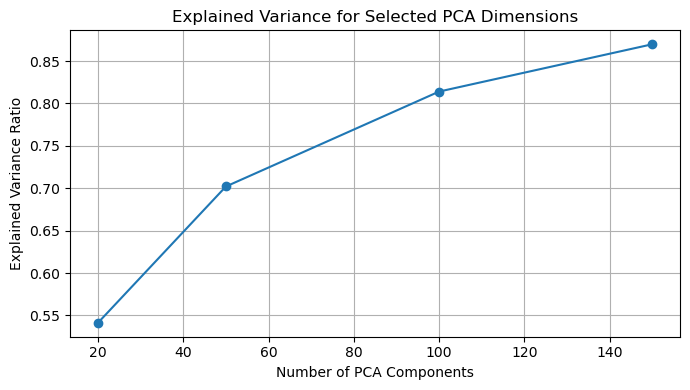

In [88]:
# step 6, part 4: selected PCA variance plot

plt.figure(figsize=(7, 4))

plt.plot(
    pca_summary_df["n_components"],
    pca_summary_df["explained_variance_ratio"],
    marker="o"
)

plt.xlabel("Number of PCA Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance for Selected PCA Dimensions")
plt.grid(True)
plt.tight_layout()
plt.show()


The selected PCA variance plot visualises the amount of training-set variance retained by the candidate PCA dimensionalities. Explained variance increases from approximately **54.14%** with **20 components** to approximately **86.98%** with **150 components**.

This confirms that retaining more principal components preserves more information from the original pixel feature space. However, retaining more variance does not automatically guarantee stronger classification performance, particularly for distance-based classifiers such as kNN, where irrelevant or noise-sensitive dimensions may still affect neighbour relationships.

The plot therefore supports the later PCA+kNN validation experiment, where PCA dimensionality is selected based on classification performance rather than explained variance alone.

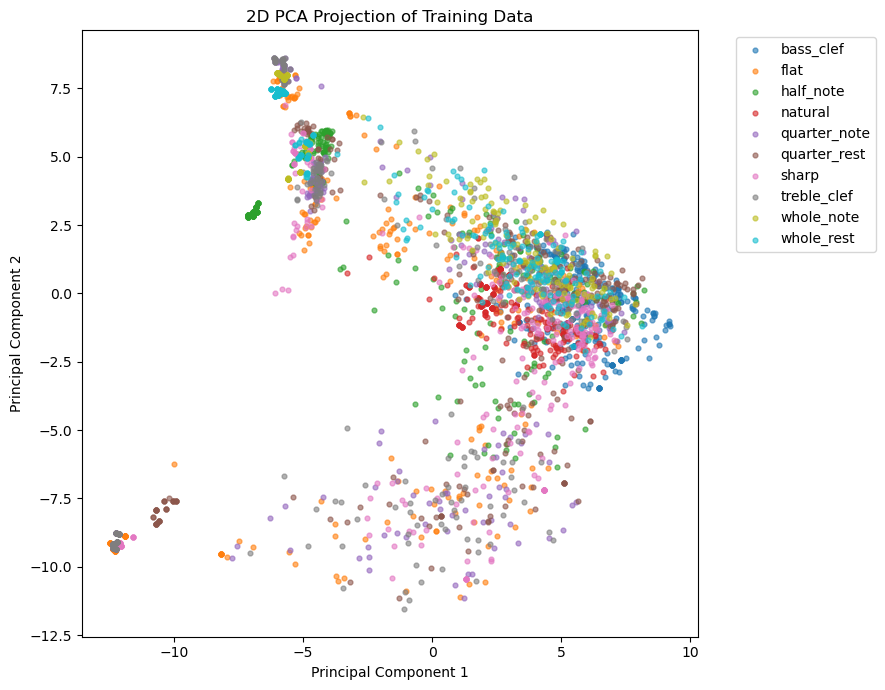

2D PCA visualisation completed.


In [89]:
# step 6, part 5: 2D PCA visualisation

pca_2d = PCA(n_components=2, random_state=42)
X_train_pca_2d = pca_2d.fit_transform(X_train)

plt.figure(figsize=(9, 7))

for class_idx, class_name in enumerate(class_names):
    mask = y_train == class_idx

    plt.scatter(
        X_train_pca_2d[mask, 0],
        X_train_pca_2d[mask, 1],
        s=12,
        alpha=0.6,
        label=class_name
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Projection of Training Data")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("2D PCA visualisation completed.")


The two-dimensional PCA projection visualises the training data using only the first two principal components. Some partial clustering is visible, suggesting that the flattened pixel features contain class-related structure.

However, substantial overlap remains between classes because the original **4096-dimensional** image representation has been compressed into only two dimensions. This compression is useful for exploratory visualisation, but it cannot preserve all discriminative information required for accurate multi-class classification.

The projection therefore indicates that PCA reveals meaningful structure in the dataset, while also demonstrating that two components are insufficient for complete class separation. Higher-dimensional PCA representations and supervised classifiers are required for stronger predictive performance.

In [90]:
# step 6, part 6: PCA + kNN validation search

"""
PCA + kNN Validation Search
---------------------------

This section evaluates whether PCA improves kNN performance by reducing the
dimensionality of the raw pixel representation. The same from-scratch kNN
classifier is used after PCA transformation.
"""

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


# =======================
# PCA + kNN hyperparameter search
# =======================

pca_component_options = [20, 50, 100, 150]
k_values = [1, 3, 5, 7, 9]

pca_knn_results = []

for n_components in pca_component_options:
    pca = PCA(n_components=n_components, random_state=42)

    X_train_pca = pca.fit_transform(X_train)
    X_val_pca = pca.transform(X_val)

    explained_variance = np.sum(pca.explained_variance_ratio_)

    for k in k_values:
        knn_pca = KNearestNeighbours(k=k)
        knn_pca.fit(X_train_pca, y_train)

        y_val_pred = knn_pca.predict(X_val_pca, batch_size=100)
        val_accuracy = accuracy_score(y_val, y_val_pred)

        pca_knn_results.append({
            "n_components": n_components,
            "k": k,
            "explained_variance": explained_variance,
            "validation_accuracy": val_accuracy
        })

pca_knn_results_df = pd.DataFrame(pca_knn_results)

print("PCA + kNN validation search results:")
display(pca_knn_results_df.round(4))


PCA + kNN validation search results:


,n_components,k,explained_variance,validation_accuracy
0,20,1,0.5414,0.7400
1,20,3,0.5414,0.7467
2,20,5,0.5414,0.7367
3,20,7,0.5414,0.7333
4,20,9,0.5414,0.7267
5,50,1,0.7021,0.7450
6,50,3,0.7021,0.7150
7,50,5,0.7021,0.7317
8,50,7,0.7021,0.7200
9,50,9,0.7021,0.6983


A validation-based search was performed across four PCA dimensionalities and five kNN neighbour values. The evaluated PCA settings were **20**, **50**, **100**, and **150** components, while the tested neighbour values were `k = 1`, `3`, `5`, `7`, and `9`.

The strongest validation result was achieved using **20 PCA components** with `k = 3`, producing a validation accuracy of **0.7467**. This configuration retained **0.5414** of the training-set variance.

Although higher-dimensional PCA representations retained more variance, they did not produce stronger validation accuracy in this experiment. This suggests that a more compact representation may have removed some redundant or noise-sensitive variation while preserving sufficient discriminative structure for nearest-neighbour classification.

PCA was fitted only on the training set before transforming the validation set, ensuring that no validation data was used during dimensionality reduction.

In [91]:
# step 6, part 7: best PCA + kNN configuration

best_pca_knn_config = (
    pca_knn_results_df
    .sort_values(by="validation_accuracy", ascending=False)
    .iloc[0]
)

best_n_components = int(best_pca_knn_config["n_components"])
best_k_pca = int(best_pca_knn_config["k"])

best_pca_knn_summary = pd.DataFrame([{
    "best_n_components": best_n_components,
    "best_k": best_k_pca,
    "explained_variance": best_pca_knn_config["explained_variance"],
    "validation_accuracy": best_pca_knn_config["validation_accuracy"],
}])

print("Best PCA + kNN configuration selected from validation set:")
display(best_pca_knn_summary.round(4))


Best PCA + kNN configuration selected from validation set:


,best_n_components,best_k,explained_variance,validation_accuracy
0,20,3,0.5414,0.7467


The best PCA+kNN configuration selected from the validation search used **20 PCA components** with `k = 3`. This setting achieved the highest validation accuracy of **0.7467** while retaining **0.5414** of the training-set variance.

This result indicates that the most effective PCA+kNN configuration was not the one with the largest number of retained components. Instead, the compact 20-component representation provided the strongest validation performance, suggesting that reduced dimensionality improved the usefulness of the nearest-neighbour feature space.

This selected configuration was used for the final PCA+kNN validation, test, clean-test, and mild-noise evaluation.

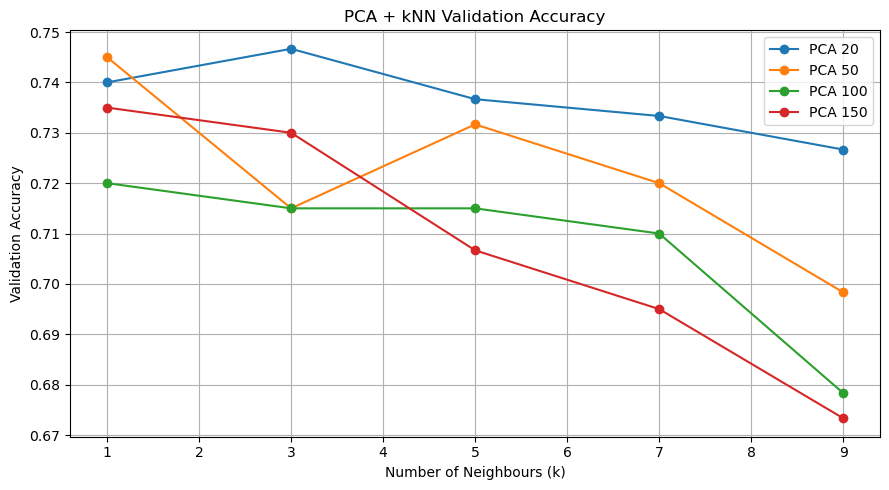

In [92]:
# step 6, part 8: PCA + kNN validation plot

plt.figure(figsize=(9, 5))

for n_components in pca_component_options:
    subset = pca_knn_results_df[
        pca_knn_results_df["n_components"] == n_components
    ]

    plt.plot(
        subset["k"],
        subset["validation_accuracy"],
        marker="o",
        label=f"PCA {n_components}"
    )

plt.xlabel("Number of Neighbours (k)")
plt.ylabel("Validation Accuracy")
plt.title("PCA + kNN Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


The PCA+kNN validation plot compares classification accuracy across different PCA dimensionalities and neighbour values. The strongest configuration was **20 PCA components** with `k = 3`, achieving a validation accuracy of **0.7467**.

The 20-component representation performed competitively despite retaining only **0.5414** of the variance. In contrast, higher-dimensional PCA settings retained more variance but did not consistently improve validation accuracy. This suggests that retaining additional components may also preserve variation that is less useful, or even less stable, for distance-based classification.

Overall, the validation results show that PCA dimensionality should be selected based on downstream classification performance rather than explained variance alone. Therefore, **20 components** and `k = 3` were selected for the final PCA+kNN model.

In [93]:
# step 6, part 9: final PCA + kNN training

pca_final = PCA(n_components=best_n_components, random_state=42)

X_train_pca_final = pca_final.fit_transform(X_train)
X_val_pca_final = pca_final.transform(X_val)
X_test_pca_final = pca_final.transform(X_test)

X_test_clean_pca = pca_final.transform(X_test_clean)
X_test_noise_pca = pca_final.transform(X_test_noise)

knn_pca_final = KNearestNeighbours(k=best_k_pca)
knn_pca_final.fit(X_train_pca_final, y_train)

print("Final PCA + kNN model trained successfully.")
print(f"PCA components used: {best_n_components}")
print(f"k value used:        {best_k_pca}")


Final PCA + kNN model trained successfully.
PCA components used: 20
k value used:        3


The final PCA+kNN model was trained using the selected configuration of **20 PCA components** and `k = 3`.

PCA was fitted only on the training set and then applied consistently to the validation, held-out test, clean-test, and mild-noise test subsets. This avoids data leakage by ensuring that the PCA transformation is learned only from the training distribution.

After transformation into the 20-dimensional PCA space, classification was performed using the manually implemented kNN classifier. This maintains consistency with the coursework requirement for a from-scratch supervised learning algorithm while also allowing evaluation of dimensionality reduction.

In [94]:
# step 6, part 10: final PCA + kNN validation and test evaluation

y_val_pred_pca_knn = knn_pca_final.predict(X_val_pca_final, batch_size=100)
y_test_pred_pca_knn = knn_pca_final.predict(X_test_pca_final, batch_size=100)

val_accuracy_pca_knn = accuracy_score(y_val, y_val_pred_pca_knn)
test_accuracy_pca_knn = accuracy_score(y_test, y_test_pred_pca_knn)

pca_knn_performance_summary = pd.DataFrame([{
    "model": "PCA_plus_kNN_from_scratch",
    "pca_components": best_n_components,
    "best_k": best_k_pca,
    "validation_accuracy": val_accuracy_pca_knn,
    "test_accuracy": test_accuracy_pca_knn,
}])

print("Final PCA + kNN performance summary:")
display(pca_knn_performance_summary.round(4))


Final PCA + kNN performance summary:


,model,pca_components,best_k,validation_accuracy,test_accuracy
0,PCA_plus_kNN_from_scratch,20,3,0.7467,0.7567


The final PCA+kNN model achieved a validation accuracy of **0.7467** and a held-out test accuracy of **0.7567** using **20 PCA components** and `k = 3`.

The test accuracy is slightly higher than the validation accuracy, suggesting that the selected configuration generalised consistently to unseen test images. The result also shows that PCA+kNN improved over the raw-pixel kNN baseline, which achieved a lower test accuracy of **0.7200**.

This indicates that dimensionality reduction improved the nearest-neighbour representation by compressing the original **4096-dimensional** pixel space into a more compact feature space while preserving useful class-discriminative information.

In [95]:
# step 6, part 11: PCA + kNN classification report

pca_knn_report = classification_report(
    y_test,
    y_test_pred_pca_knn,
    target_names=class_names,
    output_dict=True
)

pca_knn_report_df = pd.DataFrame(pca_knn_report).transpose()

print("PCA + kNN classification report on test set:")
display(pca_knn_report_df.round(4))


PCA + kNN classification report on test set:


,precision,recall,f1-score,support
bass_clef,1.0000,0.9833,0.9916,60.0000
flat,0.6393,0.6500,0.6446,60.0000
half_note,0.8438,0.9000,0.8710,60.0000
natural,0.9483,0.9167,0.9322,60.0000
quarter_note,0.5077,0.5500,0.5280,60.0000
quarter_rest,0.8545,0.7833,0.8174,60.0000
sharp,0.8600,0.7167,0.7818,60.0000
treble_clef,0.4400,0.3667,0.4000,60.0000
whole_note,0.7000,0.8167,0.7538,60.0000
whole_rest,0.7794,0.8833,0.8281,60.0000


The PCA+kNN classification report shows an overall held-out test accuracy of **0.7567**, with a macro F1-score of **0.7549** and a weighted F1-score of **0.7549**. Since the test set is balanced, with **60 samples per class**, the macro and weighted averages are identical.

The model performed strongly on classes such as `bass_clef`, `natural`, `half_note`, `quarter_rest`, `whole_note`, and `whole_rest`. These classes achieved comparatively high precision, recall, and F1-score values, indicating that the PCA-reduced representation preserved useful class-discriminative structure.

However, `treble_clef` and `quarter_note` remained more difficult to classify. The `treble_clef` class achieved an F1-score of **0.4000**, while `quarter_note` achieved an F1-score of **0.5280**. This suggests that visually complex or overlapping symbols remained challenging for the nearest-neighbour classifier, even after dimensionality reduction.

Overall, the classification report shows that PCA+kNN improves upon the raw-pixel kNN baseline, but some class-level ambiguities remain unresolved.

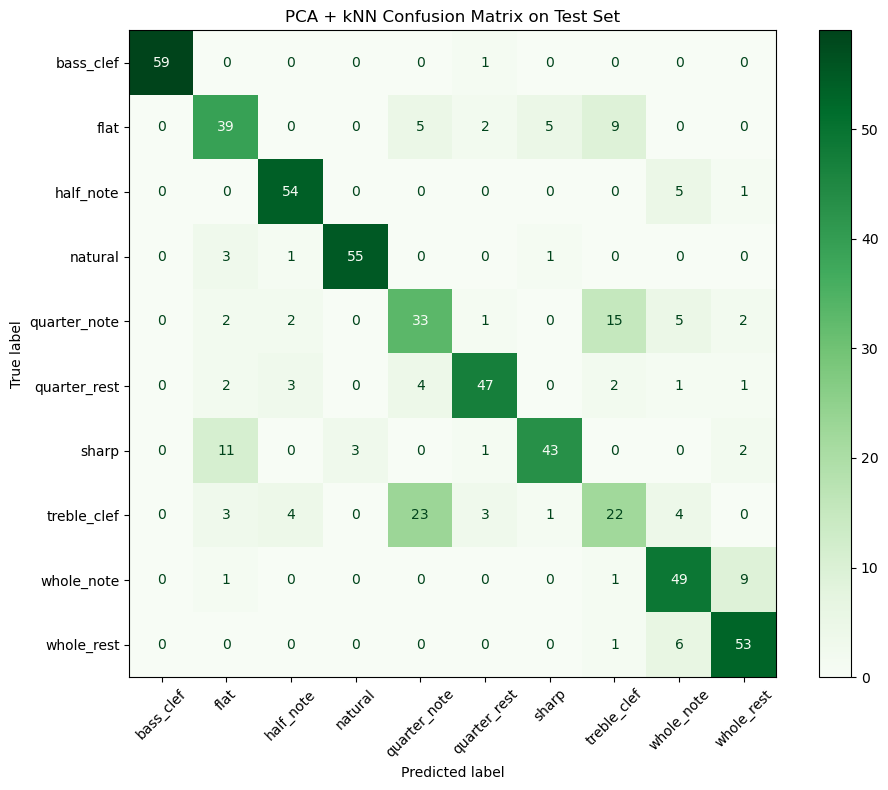

In [96]:
# step 6, part 12: PCA + kNN confusion matrix

cm_pca_knn = confusion_matrix(y_test, y_test_pred_pca_knn)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_pca_knn,
    display_labels=class_names
)

disp.plot(
    cmap="Greens",
    xticks_rotation=45,
    values_format="d",
    ax=ax
)

plt.title("PCA + kNN Confusion Matrix on Test Set")
plt.tight_layout()
plt.show()


The PCA+kNN confusion matrix shows that the model correctly classifies several symbol categories with reasonable consistency, including `bass_clef`, `half_note`, `natural`, `quarter_rest`, `whole_note`, and `whole_rest`.

However, the matrix also reveals remaining confusion among visually similar or structurally complex symbols. In particular, `treble_clef` and `quarter_note` remain difficult to separate, which is consistent with their lower F1-score values in the classification report.

Some confusion is also visible among accidental symbols such as `flat` and `sharp`, suggesting that compact geometric differences between these classes may be partially blurred by resizing, perturbation, and PCA compression.

Overall, the confusion matrix indicates that PCA+kNN improves the nearest-neighbour baseline in several areas, but still struggles with symbol classes that share overlapping visual features.

In [97]:
# step 6, part 13: PCA + kNN clean vs mild-noise robustness evaluation

y_test_clean_pred_pca_knn = knn_pca_final.predict(
    X_test_clean_pca,
    batch_size=100
)

y_test_noise_pred_pca_knn = knn_pca_final.predict(
    X_test_noise_pca,
    batch_size=100
)

clean_accuracy_pca_knn = accuracy_score(
    y_test_clean,
    y_test_clean_pred_pca_knn
)

noise_accuracy_pca_knn = accuracy_score(
    y_test_noise,
    y_test_noise_pred_pca_knn
)

accuracy_drop_pca_knn = clean_accuracy_pca_knn - noise_accuracy_pca_knn

pca_knn_robustness_summary = pd.DataFrame([{
    "model": "PCA_plus_kNN_from_scratch",
    "clean_test_accuracy": clean_accuracy_pca_knn,
    "mild_noise_test_accuracy": noise_accuracy_pca_knn,
    "accuracy_drop_clean_to_noise": accuracy_drop_pca_knn,
}])

print("PCA + kNN robustness evaluation:")
display(pca_knn_robustness_summary.round(4))


PCA + kNN robustness evaluation:


,model,clean_test_accuracy,mild_noise_test_accuracy,accuracy_drop_clean_to_noise
0,PCA_plus_kNN_from_scratch,0.8967,0.6167,0.28


The PCA+kNN robustness evaluation shows that the model achieved a clean-test accuracy of **0.8967** and a mild-noise test accuracy of **0.6167**, producing a clean-to-noise accuracy drop of **0.2800**.

This indicates that PCA+kNN remained sensitive to controlled perturbations, including mild noise, rotation, scaling, and translation. However, its robustness was slightly stronger than the raw-pixel kNN baseline, which had a larger accuracy drop of **0.3000**.

The improvement suggests that PCA helped suppress some noise-sensitive or redundant variation in the original high-dimensional pixel representation. Nevertheless, the relatively large drop shows that nearest-neighbour classification remains vulnerable to perturbation-induced changes in feature-space distances.

Overall, PCA provided a modest robustness improvement while substantially reducing feature dimensionality.

In [98]:
# step 6, part 14: store PCA + kNN results

pca_knn_results_summary = {
    "model": "PCA_plus_kNN_from_scratch",
    "best_k": best_k_pca,
    "pca_components": best_n_components,
    "validation_accuracy": val_accuracy_pca_knn,
    "test_accuracy": test_accuracy_pca_knn,
    "clean_test_accuracy": clean_accuracy_pca_knn,
    "mild_noise_test_accuracy": noise_accuracy_pca_knn,
    "accuracy_drop_clean_to_noise": accuracy_drop_pca_knn,
}

pca_knn_results_final_df = pd.DataFrame([pca_knn_results_summary])

print("Stored PCA + kNN results:")
display(pca_knn_results_final_df.round(4))


Stored PCA + kNN results:


,model,best_k,pca_components,validation_accuracy,test_accuracy,clean_test_accuracy,mild_noise_test_accuracy,accuracy_drop_clean_to_noise
0,PCA_plus_kNN_from_scratch,3,20,0.7467,0.7567,0.8967,0.6167,0.28


The PCA+kNN results were stored in the supervised model comparison dataframe for later cross-model evaluation. The stored metrics include the selected number of PCA components, selected k value, validation accuracy, held-out test accuracy, clean-test accuracy, mild-noise accuracy, and clean-to-noise accuracy drop.

The final PCA+kNN model used **20 PCA components** and `k = 3`. It achieved a validation accuracy of **0.7467**, a held-out test accuracy of **0.7567**, a clean-test accuracy of **0.8967**, and a mild-noise accuracy of **0.6167**. The resulting robustness drop was **0.2800**.

These stored results confirm that PCA+kNN improves over raw-pixel kNN in both overall test accuracy and mild-noise accuracy. However, the model remains sensitive to controlled perturbations, indicating that dimensionality reduction alone is insufficient to fully resolve robustness limitations.

In [99]:
# step 6, part 15: raw kNN vs PCA + kNN comparison table

comparison_results = pd.DataFrame([
    knn_results,
    pca_knn_results_summary,
])

print("Raw kNN vs PCA + kNN comparison:")
display(comparison_results.round(4))


Raw kNN vs PCA + kNN comparison:


,model,best_k,validation_accuracy,test_accuracy,clean_test_accuracy,mild_noise_test_accuracy,accuracy_drop_clean_to_noise,pca_components
0,kNN_from_scratch,1,0.7300,0.7200,0.8700,0.5700,0.30,NaN
1,PCA_plus_kNN_from_scratch,3,0.7467,0.7567,0.8967,0.6167,0.28,20.0


The comparison table summarises the performance of the raw-pixel kNN model and the PCA-enhanced kNN model using validation accuracy, held-out test accuracy, clean-test accuracy, mild-noise accuracy, robustness drop, and selected hyperparameters.

The raw `kNN_from_scratch` model selected `k = 1` and achieved a validation accuracy of **0.7300** and a held-out test accuracy of **0.7200**. Its clean-test accuracy was **0.8700**, but this decreased to **0.5700** under the `mild_noise` condition, producing a clean-to-noise accuracy drop of **0.3000**. This indicates that direct nearest-neighbour classification in the original 4096-dimensional pixel space was sensitive to controlled image perturbations.

The `PCA_plus_kNN_from_scratch` model selected **20 PCA components** and `k = 3`. It achieved a higher validation accuracy of **0.7467** and a higher held-out test accuracy of **0.7567**. It also improved clean-test accuracy to **0.8967** and mild-noise accuracy to **0.6167**, while reducing the clean-to-noise accuracy drop to **0.2800**.

These results show that PCA improved the kNN feature representation by compressing the original high-dimensional pixel space into a lower-dimensional representation that retained useful discriminative structure. Although the PCA-enhanced model remained affected by perturbation, it provided a consistent improvement over raw-pixel kNN across validation accuracy, test accuracy, clean accuracy, mild-noise accuracy, and robustness drop.

Overall, the comparison demonstrates that dimensionality reduction provides a modest but meaningful benefit for nearest-neighbour classification in this music-symbol image classification task.

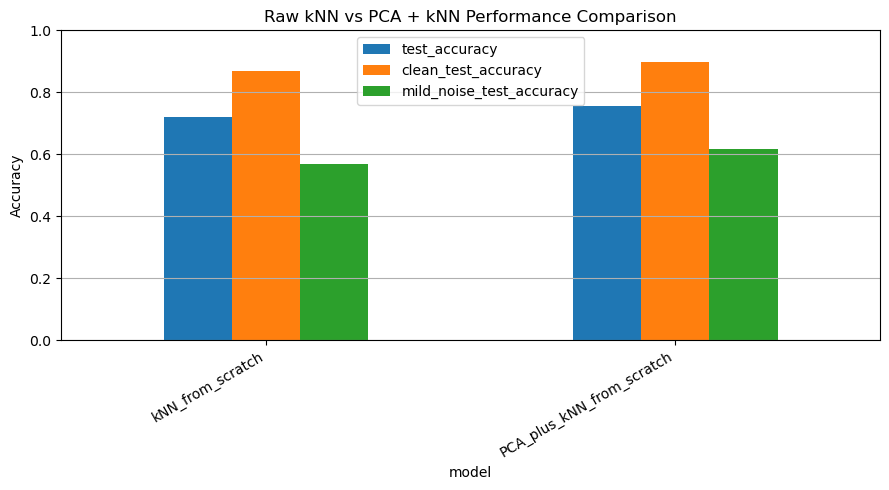

In [100]:
# step 6, part 16: raw kNN vs PCA + kNN comparison plot

metric_columns = [
    "test_accuracy",
    "clean_test_accuracy",
    "mild_noise_test_accuracy"
]

comparison_plot_df = comparison_results.set_index("model")[metric_columns]

comparison_plot_df.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylabel("Accuracy")
plt.title("Raw kNN vs PCA + kNN Performance Comparison")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.tight_layout()
plt.show()


The comparison chart evaluates raw-pixel kNN and PCA+kNN using held-out test accuracy, clean-test accuracy, and mild-noise test accuracy.

PCA+kNN performs better across all three metrics. Held-out test accuracy increased from **0.7200** for raw kNN to **0.7567** for PCA+kNN. Clean-test accuracy increased from **0.8700** to **0.8967**, while mild-noise accuracy increased from **0.5700** to **0.6167**.

These results indicate that PCA provided a modest but consistent improvement over the raw flattened pixel representation. By reducing the original **4096-dimensional** feature space to **20 components**, PCA improved the nearest-neighbour feature representation while also reducing computational dimensionality.

However, both models still performed substantially better on clean images than on mild-noise images, confirming that robustness under perturbation remained a challenge for kNN-based classification.

In [101]:
# step 6, part 17: final PCA + kNN summary

print("PCA dimensionality reduction and PCA + kNN comparison completed successfully.")
print(f"Best PCA components: {best_n_components}")
print(f"Best k for PCA + kNN: {best_k_pca}")
print(f"PCA + kNN test accuracy: {test_accuracy_pca_knn:.4f}")
print(f"PCA + kNN mild-noise accuracy: {noise_accuracy_pca_knn:.4f}")


PCA dimensionality reduction and PCA + kNN comparison completed successfully.
Best PCA components: 20
Best k for PCA + kNN: 3
PCA + kNN test accuracy: 0.7567
PCA + kNN mild-noise accuracy: 0.6167


Step 6 completed the PCA dimensionality reduction and PCA+kNN comparison. The best configuration used **20 PCA components** with `k = 3`.

The final PCA+kNN model achieved a held-out test accuracy of **0.7567** and a mild-noise test accuracy of **0.6167**. Compared with the raw-pixel kNN baseline, PCA+kNN improved overall test accuracy, clean-test accuracy, and mild-noise accuracy while greatly reducing feature dimensionality.

These results show that PCA provides a useful compact representation for nearest-neighbour classification. However, the remaining gap between clean-test and mild-noise accuracy indicates that perturbation robustness remains a limitation of the kNN-based approach.

Overall, PCA+kNN represents an improvement over raw-pixel kNN, but later classifiers are required to determine whether stronger supervised models can provide better accuracy and robustness.

**Step 7: Decision Tree Classifier Training and Evaluation**

In [103]:
# step 7, part 1: decision tree classifier setup

"""
Decision Tree Classifier Training and Evaluation
------------------------------------------------

This section trains and evaluates a Decision Tree classifier as an additional
supervised learning algorithm. A small validation-based hyperparameter search
is performed over max_depth to reduce overfitting.

The final Decision Tree model is evaluated on:
- validation set
- test set
- clean test subset
- mild_noise test subset

The results are later compared with the raw-pixel kNN and PCA+kNN models.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


The Decision Tree classifier was included as a second supervised learning algorithm for comparison with the from-scratch kNN models. Unlike kNN, the Decision Tree learns a hierarchical set of feature-based decision rules during training. A small validation-based search over `max_depth` was used to control model complexity and reduce the risk of overfitting.

In [104]:
# step 7, part 2: decision tree max_depth validation search

max_depth_values = [3, 5, 8, 10, 15, 20, None]

dt_validation_results = []

for depth in max_depth_values:
    dt_model = DecisionTreeClassifier(
        max_depth=depth,
        criterion="gini",
        random_state=42
    )

    dt_model.fit(X_train, y_train)

    y_val_pred_dt = dt_model.predict(X_val)
    val_accuracy = accuracy_score(y_val, y_val_pred_dt)

    dt_validation_results.append({
        "max_depth": str(depth),
        "validation_accuracy": val_accuracy,
        "tree_depth": dt_model.get_depth(),
        "n_leaves": dt_model.get_n_leaves()
    })

dt_validation_df = pd.DataFrame(dt_validation_results)

print("Decision Tree validation results:")
display(dt_validation_df.round(4))


Decision Tree validation results:


,max_depth,validation_accuracy,tree_depth,n_leaves
0,3,0.2600,3,8
1,5,0.3467,5,20
2,8,0.4867,8,50
3,10,0.5117,10,91
4,15,0.5867,15,171
5,20,0.6417,20,288
6,None,0.6183,34,442


The Decision Tree validation search evaluated a range of maximum-depth settings to examine the relationship between model complexity, validation performance, and potential overfitting.

The results show that validation accuracy generally increased as the permitted tree depth became larger. Shallow trees substantially underperformed, with `max_depth = 3` achieving only **0.2600** validation accuracy. This indicates that very shallow hierarchical partitions were insufficient to capture the discriminative structure of the 4096-dimensional flattened pixel representation.

The strongest validation performance was achieved using `max_depth = 20`, which produced a validation accuracy of **0.6417**, an actual tree depth of **20**, and **288** leaf nodes. Although the unrestricted tree (`max_depth = None`) was more complex, reaching a depth of **34** with **442** leaves, it achieved a lower validation accuracy of **0.6183**.

This suggests that allowing the tree to grow without constraint did not improve generalisation. Instead, the `max_depth = 20` configuration provided a better trade-off between model capacity and validation performance.

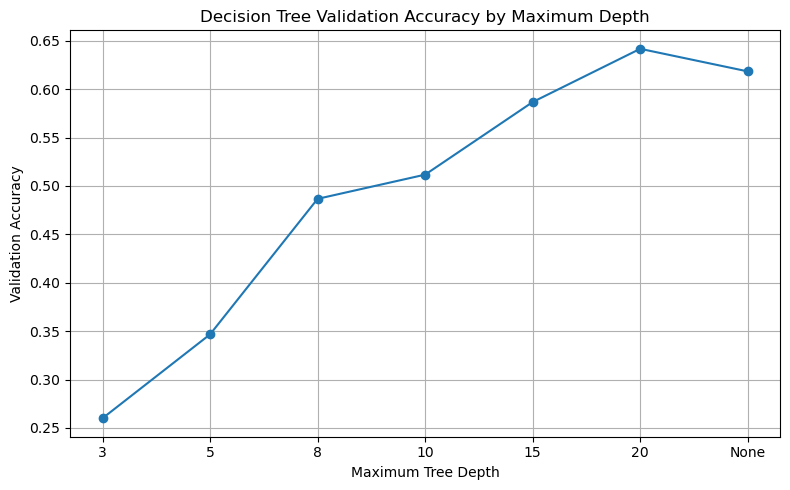

In [105]:
# step 7, part 3: decision tree validation accuracy plot

plt.figure(figsize=(8, 5))

plt.plot(
    dt_validation_df["max_depth"],
    dt_validation_df["validation_accuracy"],
    marker="o"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Validation Accuracy")
plt.title("Decision Tree Validation Accuracy by Maximum Depth")
plt.grid(True)
plt.tight_layout()
plt.show()


The Decision Tree validation accuracy plot illustrates how classification performance changed as the maximum tree depth increased.

Validation accuracy improved from **0.2600** at `max_depth = 3` to **0.6417** at `max_depth = 20`, showing that shallow trees underfit the dataset. Increasing tree depth allowed the model to learn more detailed feature-based partitions from the high-dimensional image representation.

However, the unrestricted tree (`max_depth = None`) did not achieve the best validation performance. Although it produced a deeper and more complex model, with an actual depth of **34** and **442** leaves, its validation accuracy decreased to **0.6183**.

Therefore, `max_depth = 20` was selected for the final Decision Tree model because it achieved the highest validation accuracy while avoiding the unnecessary additional complexity of the unrestricted tree.

In [106]:
# step 7, part 4: select best decision tree configuration

best_dt_row = (
    dt_validation_df
    .sort_values(by="validation_accuracy", ascending=False)
    .iloc[0]
)

best_depth_value = best_dt_row["max_depth"]

if best_depth_value == "None":
    best_depth = None
else:
    best_depth = int(best_depth_value)

best_dt_summary = pd.DataFrame([{
    "selected_max_depth": best_depth,
    "validation_accuracy": best_dt_row["validation_accuracy"],
    "actual_tree_depth": best_dt_row["tree_depth"],
    "n_leaves": best_dt_row["n_leaves"],
}])

print("Best Decision Tree configuration:")
display(best_dt_summary.round(4))


Best Decision Tree configuration:


,selected_max_depth,validation_accuracy,actual_tree_depth,n_leaves
0,20,0.6417,20,288


The selected Decision Tree configuration was `max_depth = 20`, which achieved the highest validation accuracy of **0.6417** during the hyperparameter search.

This configuration produced an actual tree depth of **20** and **288** leaf nodes. Compared with the unrestricted tree, this model was less complex while also achieving stronger validation performance. This indicates that moderate depth control improved generalisation relative to allowing the tree to grow without an explicit maximum-depth constraint.

The selected configuration was therefore used to train the final Decision Tree classifier before evaluating its performance on the validation, held-out test, clean-test, and mild-noise test subsets.

In [107]:
# step 7, part 5: train final decision tree model

dt_final = DecisionTreeClassifier(
    max_depth=best_depth,
    criterion="gini",
    random_state=42
)

dt_final.fit(X_train, y_train)

print("Final Decision Tree model trained successfully.")
print(f"Selected max_depth: {best_depth}")
print(f"Final tree depth:   {dt_final.get_depth()}")
print(f"Number of leaves:   {dt_final.get_n_leaves()}")


Final Decision Tree model trained successfully.
Selected max_depth: 20
Final tree depth:   20
Number of leaves:   288


The final Decision Tree model was trained using the selected setting `max_depth = 20`. The trained model reached an actual depth of **20** and contained **288** leaf nodes.

This structure indicates that the tree learned a relatively detailed hierarchy of pixel-level splitting rules. However, because Decision Trees partition the feature space using hard threshold-based decisions, they may remain sensitive to small perturbations in image structure, especially in high-dimensional flattened pixel representations.

Therefore, the final Decision Tree model must be interpreted not only through its validation and test accuracy, but also through its robustness behaviour under the `mild_noise` condition.

In [108]:
# step 7, part 6: final decision tree validation and test evaluation

y_val_pred_dt = dt_final.predict(X_val)
y_test_pred_dt = dt_final.predict(X_test)

val_accuracy_dt = accuracy_score(y_val, y_val_pred_dt)
test_accuracy_dt = accuracy_score(y_test, y_test_pred_dt)

dt_performance_summary = pd.DataFrame([{
    "model": "Decision_Tree",
    "max_depth": best_depth,
    "tree_depth": dt_final.get_depth(),
    "n_leaves": dt_final.get_n_leaves(),
    "validation_accuracy": val_accuracy_dt,
    "test_accuracy": test_accuracy_dt,
}])

print("Final Decision Tree performance summary:")
display(dt_performance_summary.round(4))


Final Decision Tree performance summary:


,model,max_depth,tree_depth,n_leaves,validation_accuracy,test_accuracy
0,Decision_Tree,20,20,288,0.6417,0.64


The final Decision Tree model achieved a validation accuracy of **0.6417** and a held-out test accuracy of **0.6400** using `max_depth = 20`.

The similarity between validation and test accuracy suggests that the selected tree configuration generalised consistently to the held-out test set. However, its overall test accuracy remained lower than the kNN-based models evaluated earlier, indicating that hierarchical threshold-based partitioning was less effective for this flattened image-classification task.

The model retained a moderately complex structure, with a depth of **20** and **288** leaf nodes. Although this complexity allowed the tree to learn detailed feature-based decision rules, its final performance suggests that pixel-threshold splits alone were insufficient to capture the full visual structure of the music-symbol classes.

In [109]:
# step 7, part 7: decision tree classification report

dt_report = classification_report(
    y_test,
    y_test_pred_dt,
    target_names=class_names,
    output_dict=True
)

dt_report_df = pd.DataFrame(dt_report).transpose()

print("Decision Tree classification report on test set:")
display(dt_report_df.round(4))


Decision Tree classification report on test set:


,precision,recall,f1-score,support
bass_clef,0.8500,0.8500,0.8500,60.00
flat,0.7083,0.5667,0.6296,60.00
half_note,0.6667,0.6667,0.6667,60.00
natural,0.8776,0.7167,0.7890,60.00
quarter_note,0.3538,0.3833,0.3680,60.00
quarter_rest,0.7119,0.7000,0.7059,60.00
sharp,0.7414,0.7167,0.7288,60.00
treble_clef,0.3788,0.4167,0.3968,60.00
whole_note,0.5625,0.7500,0.6429,60.00
whole_rest,0.6909,0.6333,0.6609,60.00


The Decision Tree classification report shows an overall held-out test accuracy of **0.6400**, with a macro F1-score of **0.6439** and a weighted F1-score of **0.6439**. Since the test set is balanced, with **60 samples per class**, the macro and weighted averages are identical.

The model performed comparatively better on classes such as `bass_clef`, `natural`, `half_note`, `quarter_rest`, `sharp`, and `whole_rest`. These classes achieved moderate to strong precision, recall, and F1-score values, suggesting that some symbol structures could be separated using hierarchical pixel-thresholding rules.

However, `quarter_note` and `treble_clef` remained among the weakest classes, with F1-scores of **0.3680** and **0.3968** respectively. These results indicate that the Decision Tree struggled with visually complex or overlapping symbol structures.

Overall, the classification report shows that the Decision Tree provides an interpretable supervised baseline, but its class-wise performance remains weaker than the kNN-based models and substantially weaker than the later Logistic Regression and SVM classifiers.

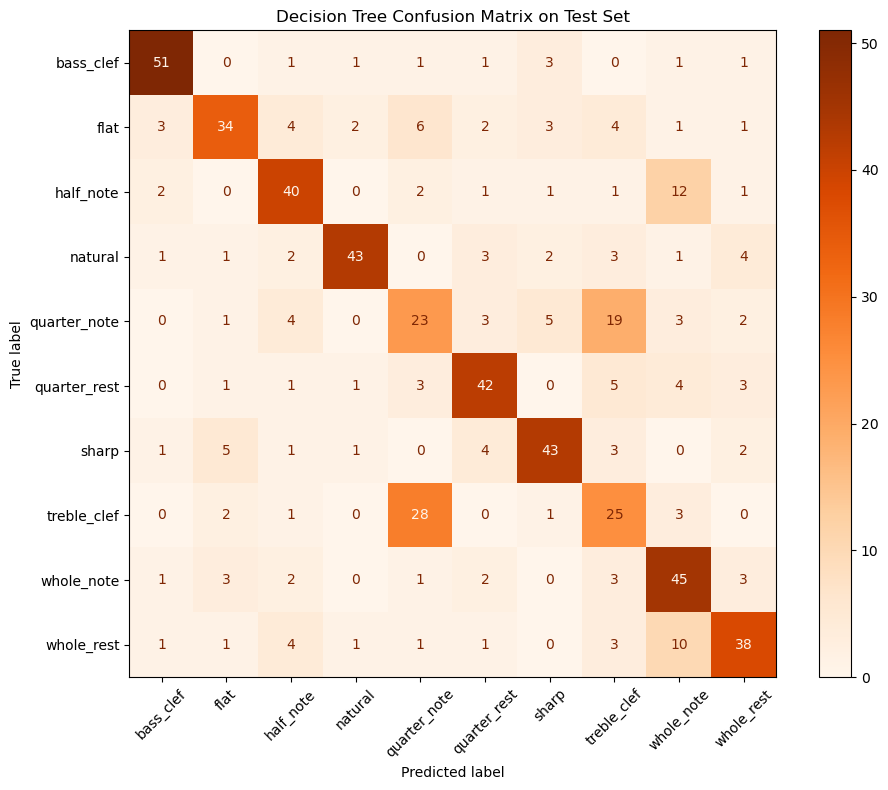

In [110]:
# step 7, part 8: decision tree confusion matrix

cm_dt = confusion_matrix(y_test, y_test_pred_dt)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=class_names
)

disp.plot(
    cmap="Oranges",
    xticks_rotation=45,
    values_format="d",
    ax=ax
)

plt.title("Decision Tree Confusion Matrix on Test Set")
plt.tight_layout()
plt.show()


The Decision Tree confusion matrix shows that the model correctly classified several symbol categories with reasonable consistency, particularly classes such as `bass_clef`, `natural`, `half_note`, `quarter_rest`, `sharp`, `whole_note`, and `whole_rest`.

However, the matrix also reveals substantial off-diagonal errors for visually similar or structurally complex classes. In particular, `quarter_note` and `treble_clef` remain difficult to distinguish, which is consistent with their lower F1-scores in the classification report.

Some confusion is also visible among visually related notation symbols such as `flat`, `sharp`, and other compact symbol classes. This suggests that the Decision Tree’s hard threshold-based splitting strategy struggles to preserve stable class boundaries when symbol structures overlap in the flattened pixel space.

Overall, the confusion matrix confirms that the Decision Tree captures some discriminative structure, but its classification behaviour is less stable and less accurate than the stronger models evaluated later.

In [111]:
# step 7, part 9: decision tree clean vs mild-noise robustness evaluation

y_test_clean_pred_dt = dt_final.predict(X_test_clean)
y_test_noise_pred_dt = dt_final.predict(X_test_noise)

clean_accuracy_dt = accuracy_score(y_test_clean, y_test_clean_pred_dt)
noise_accuracy_dt = accuracy_score(y_test_noise, y_test_noise_pred_dt)

accuracy_drop_dt = clean_accuracy_dt - noise_accuracy_dt

dt_robustness_summary = pd.DataFrame([{
    "model": "Decision_Tree",
    "clean_test_accuracy": clean_accuracy_dt,
    "mild_noise_test_accuracy": noise_accuracy_dt,
    "accuracy_drop_clean_to_noise": accuracy_drop_dt,
}])

print("Decision Tree robustness evaluation:")
display(dt_robustness_summary.round(4))


Decision Tree robustness evaluation:


,model,clean_test_accuracy,mild_noise_test_accuracy,accuracy_drop_clean_to_noise
0,Decision_Tree,0.8567,0.4233,0.4333


The Decision Tree achieved a clean-test accuracy of **0.8567**, but its performance decreased sharply to **0.4233** on the `mild_noise` test subset. This produced a clean-to-noise accuracy drop of **0.4333**.

This large drop indicates that the Decision Tree was highly sensitive to controlled visual perturbations, including mild noise, rotation, scaling, and translation. Although the model performed reasonably well on clean images, its decision rules were not stable under perturbed image conditions.

This behaviour is consistent with the nature of Decision Trees, which rely on hierarchical threshold-based splits. Small changes in pixel values or symbol position can alter the path taken through the tree, leading to unstable predictions under perturbation.

Overall, the robustness evaluation shows that the Decision Tree is considerably less reliable than the kNN-based models under the `mild_noise` condition.

In [112]:
# step 7, part 10: store decision tree results

dt_results = {
    "model": "Decision_Tree",
    "best_k": np.nan,
    "pca_components": np.nan,
    "max_depth": best_depth,
    "validation_accuracy": val_accuracy_dt,
    "test_accuracy": test_accuracy_dt,
    "clean_test_accuracy": clean_accuracy_dt,
    "mild_noise_test_accuracy": noise_accuracy_dt,
    "accuracy_drop_clean_to_noise": accuracy_drop_dt,
    "tree_depth": dt_final.get_depth(),
    "n_leaves": dt_final.get_n_leaves()
}

dt_results_df = pd.DataFrame([dt_results])

print("Stored Decision Tree results:")
display(dt_results_df.round(4))


Stored Decision Tree results:


,model,best_k,pca_components,max_depth,validation_accuracy,test_accuracy,clean_test_accuracy,mild_noise_test_accuracy,accuracy_drop_clean_to_noise,tree_depth,n_leaves
0,Decision_Tree,NaN,NaN,20,0.6417,0.64,0.8567,0.4233,0.4333,20,288


The Decision Tree results were stored in the supervised model comparison dataframe for later cross-model evaluation. The stored values include validation accuracy, held-out test accuracy, clean-test accuracy, mild-noise accuracy, clean-to-noise accuracy drop, selected maximum depth, final tree depth, and number of leaf nodes.

The final Decision Tree model achieved a validation accuracy of **0.6417** and a held-out test accuracy of **0.6400**. Its performance declined from **0.8567** on clean test images to **0.4233** on mild-noise images, producing a large robustness drop of **0.4333**.

The stored structural parameters show that the final tree had a depth of **20** and **288** leaf nodes. Although this configuration achieved the strongest validation accuracy among the tested Decision Tree settings, the large robustness drop confirms that the model remained sensitive to perturbation-induced changes in pixel structure.

In [113]:
# step 7, part 11: compare supervised models so far

supervised_results = pd.DataFrame([
    {
        "model": "kNN_from_scratch",
        "validation_accuracy": knn_results["validation_accuracy"],
        "test_accuracy": knn_results["test_accuracy"],
        "clean_test_accuracy": knn_results["clean_test_accuracy"],
        "mild_noise_test_accuracy": knn_results["mild_noise_test_accuracy"],
        "accuracy_drop_clean_to_noise": knn_results["accuracy_drop_clean_to_noise"],
        "best_k": knn_results["best_k"],
        "pca_components": np.nan,
        "max_depth": np.nan,
    },
    {
        "model": "PCA_plus_kNN_from_scratch",
        "validation_accuracy": val_accuracy_pca_knn,
        "test_accuracy": test_accuracy_pca_knn,
        "clean_test_accuracy": clean_accuracy_pca_knn,
        "mild_noise_test_accuracy": noise_accuracy_pca_knn,
        "accuracy_drop_clean_to_noise": accuracy_drop_pca_knn,
        "best_k": best_k_pca,
        "pca_components": best_n_components,
        "max_depth": np.nan,
    },
    dt_results,
])

supervised_results = (
    supervised_results
    .drop_duplicates(subset=["model"], keep="last")
    .reset_index(drop=True)
)

print("Interim supervised model comparison:")
display(supervised_results.round(4))


Interim supervised model comparison:


,model,validation_accuracy,test_accuracy,clean_test_accuracy,mild_noise_test_accuracy,accuracy_drop_clean_to_noise,best_k,pca_components,max_depth,tree_depth,n_leaves
0,kNN_from_scratch,0.7300,0.7200,0.8700,0.5700,0.3000,1.0,NaN,NaN,NaN,NaN
1,PCA_plus_kNN_from_scratch,0.7467,0.7567,0.8967,0.6167,0.2800,3.0,20.0,NaN,NaN,NaN
2,Decision_Tree,0.6417,0.6400,0.8567,0.4233,0.4333,NaN,NaN,20.0,20.0,288.0


The interim supervised model comparison summarises the three classifiers evaluated at this stage: raw-pixel kNN, PCA-enhanced kNN, and Decision Tree. The table compares validation accuracy, held-out test accuracy, clean-test accuracy, mild-noise accuracy, robustness drop, and relevant model-specific parameters.

At this stage, the **PCA-enhanced kNN** model achieved the strongest performance, with a held-out test accuracy of **0.7567** and a mild-noise accuracy of **0.6167**. The raw-pixel kNN model ranked second, with a test accuracy of **0.7200** and a mild-noise accuracy of **0.5700**.

The Decision Tree achieved a lower test accuracy of **0.6400** and showed the largest clean-to-noise accuracy drop of **0.4333**. This indicates that, although the Decision Tree provides an interpretable model structure, it was substantially less robust under controlled perturbation.

Overall, the interim comparison shows that PCA+kNN remains the strongest model at this stage, while the Decision Tree performs lower overall and is more sensitive to the `mild_noise` condition. Additional classifiers are evaluated in later steps before producing the final supervised model comparison.

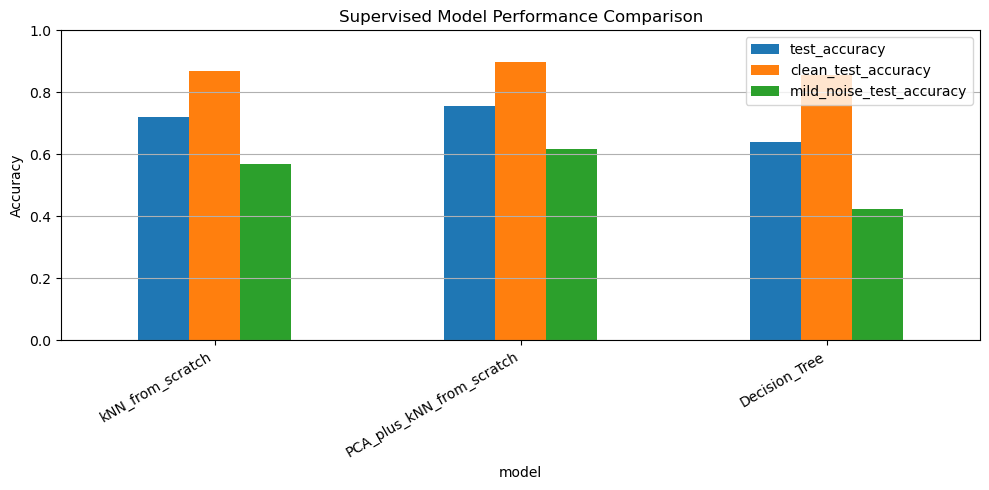

In [114]:
# step 7, part 12: supervised model performance comparison plot

comparison_metrics = [
    "test_accuracy",
    "clean_test_accuracy",
    "mild_noise_test_accuracy"
]

plot_df = supervised_results.set_index("model")[comparison_metrics]

plot_df.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Accuracy")
plt.title("Supervised Model Performance Comparison")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.tight_layout()
plt.show()


The interim performance comparison plot compares held-out test accuracy, clean-test accuracy, and mild-noise test accuracy for raw-pixel kNN, PCA-enhanced kNN, and Decision Tree.

The **PCA-enhanced kNN** model performs strongest across the main accuracy metrics, achieving a held-out test accuracy of **0.7567** and a mild-noise accuracy of **0.6167**. This suggests that dimensionality reduction improved the nearest-neighbour representation compared with raw-pixel kNN.

The raw-pixel kNN model also performs moderately, but its lower test accuracy and mild-noise accuracy indicate that direct distance comparison in the original 4096-dimensional pixel space is more sensitive to noise and irrelevant variation.

The Decision Tree performs lower overall and shows the weakest mild-noise accuracy of **0.4233**. This indicates that, at this stage of the experiment, PCA+kNN is the strongest model, while the Decision Tree is the least robust under perturbed image conditions.

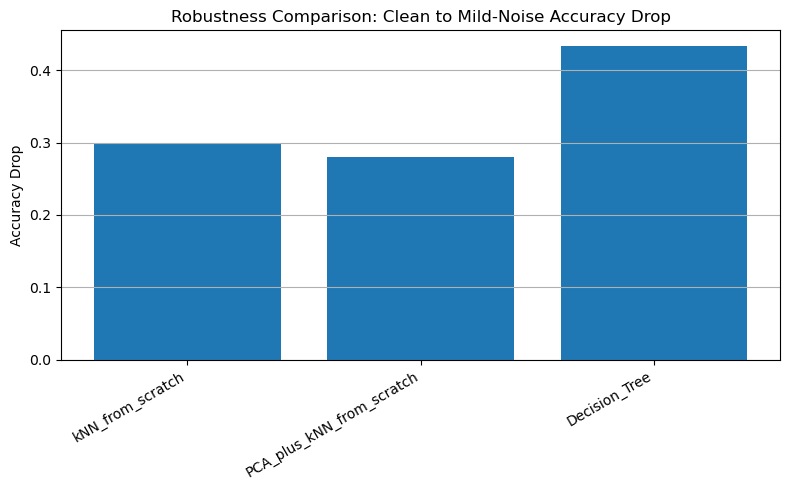

In [115]:
# step 7, part 13: robustness comparison plot

plt.figure(figsize=(8, 5))

plt.bar(
    supervised_results["model"],
    supervised_results["accuracy_drop_clean_to_noise"]
)

plt.ylabel("Accuracy Drop")
plt.title("Robustness Comparison: Clean to Mild-Noise Accuracy Drop")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


The interim robustness comparison plot shows the clean-to-mild-noise accuracy drop for each model evaluated so far. A smaller drop indicates stronger robustness under controlled perturbation.

At this stage, the **PCA-enhanced kNN** model shows the smallest accuracy drop of **0.2800**, followed by raw-pixel kNN with a drop of **0.3000**. This suggests that PCA slightly improved robustness by reducing noise-sensitive variation in the original high-dimensional pixel representation.

The Decision Tree shows the largest accuracy drop of **0.4333**, indicating substantially weaker stability under the `mild_noise` condition. This suggests that its hierarchical splitting rules were more sensitive to perturbation-induced changes in image structure.

Overall, the plot reinforces the interim finding that PCA+kNN is the most robust model among the first three evaluated classifiers, while the Decision Tree is the least stable under controlled perturbation.

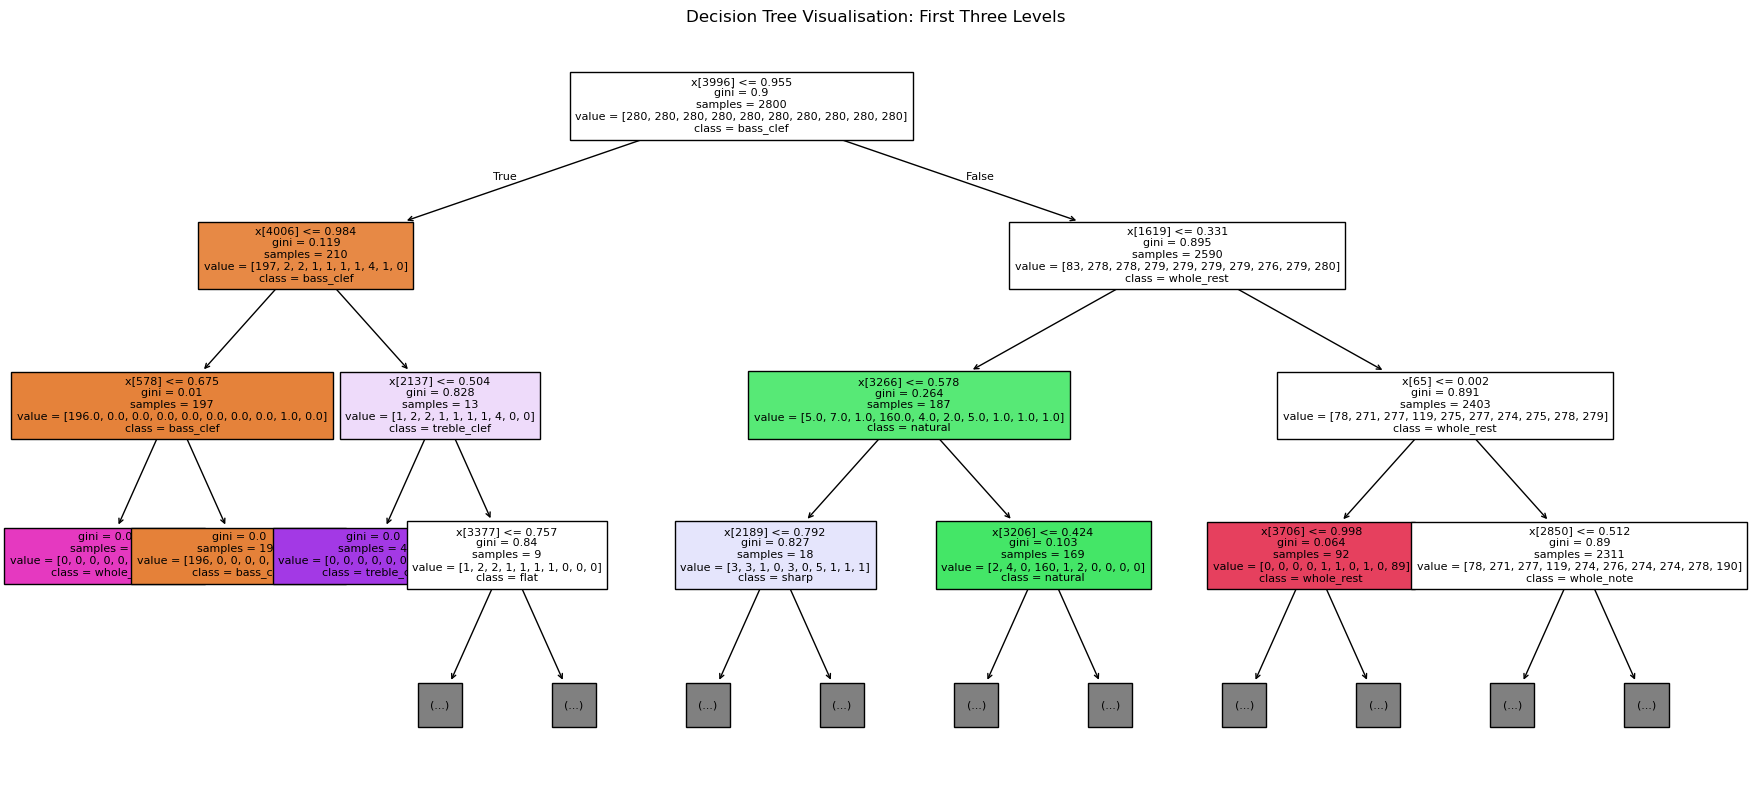

In [116]:
# step 7, part 14: shallow decision tree visualisation

plt.figure(figsize=(18, 8))

plot_tree(
    dt_final,
    max_depth=3,
    feature_names=None,
    class_names=class_names,
    filled=True,
    fontsize=8
)

plt.title("Decision Tree Visualisation: First Three Levels")
plt.tight_layout()
plt.show()


The Decision Tree visualisation displays only the first three levels of the trained tree. This provides a simplified view of the model’s early feature-based splitting structure without showing the full model, which would be too large to interpret clearly.

The final Decision Tree has a depth of **20** and **288** leaf nodes. Displaying the complete tree would produce an overly complex and visually dense diagram, reducing interpretability rather than improving it. Therefore, the shallow visualisation is used as an interpretability aid to show how the tree begins partitioning the flattened pixel feature space.

Each internal node represents a decision rule based on a specific pixel feature threshold, while the leaf or lower-level nodes indicate progressively more class-specific partitions. The visualisation illustrates the threshold-based nature of the Decision Tree model, but the main quantitative assessment of model complexity is provided by the final tree depth and number of leaves.

Overall, this figure supports interpretability by showing the structure of early decision paths, while the validation, test, and robustness results remain the primary basis for evaluating model performance.

In [117]:
# step 7, part 15: final decision tree summary

print("Decision Tree classifier comparison completed successfully.")
print(f"Selected max_depth:       {best_depth}")
print(f"Final tree depth:         {dt_final.get_depth()}")
print(f"Number of leaves:         {dt_final.get_n_leaves()}")
print(f"Decision Tree test acc:   {test_accuracy_dt:.4f}")
print(f"Mild-noise test accuracy: {noise_accuracy_dt:.4f}")


Decision Tree classifier comparison completed successfully.
Selected max_depth:       20
Final tree depth:         20
Number of leaves:         288
Decision Tree test acc:   0.6400
Mild-noise test accuracy: 0.4233


Step 7 completed the Decision Tree classifier evaluation. The final model used `max_depth = 20`, producing a trained tree with an actual depth of **20** and **288** leaf nodes.

The model achieved a held-out test accuracy of **0.6400** and a mild-noise test accuracy of **0.4233**. Its clean-test accuracy was **0.8567**, resulting in a large clean-to-noise accuracy drop of **0.4333**.

These results show that the Decision Tree provides an interpretable supervised baseline, but it performs below the kNN-based models and demonstrates weaker robustness under controlled perturbation. Although the model captures some useful pixel-level decision structure, its threshold-based rules appear highly sensitive to mild image degradation.

Overall, the Decision Tree is useful for comparison and interpretability, but it is not the strongest classifier for this symbolic music image classification task.

**Step 8: Gaussian Naive Bayes Classifier Training and Evaluation**

In [118]:
# step 8, part 1: Gaussian Naive Bayes classifier setup

"""
Gaussian Naive Bayes Classifier Training and Evaluation
-------------------------------------------------------

This section trains and evaluates a Gaussian Naive Bayes classifier as a
probabilistic supervised learning model.

Gaussian Naive Bayes is compared against the supervised models already created
in the previous steps:

1. kNN from scratch
2. PCA + kNN from scratch
3. Decision Tree

The model is evaluated on:
- validation set
- test set
- clean test subset
- mild_noise test subset

The resulting performance row is added to supervised_results_extended.
The final full-model comparison, ranking, and robustness plots are produced
later after all supervised classifiers have been evaluated.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


# =======================
# safety check
# =======================

if "supervised_results" not in globals():
    raise NameError(
        "supervised_results is not defined. "
        "Please run Step 7 before running Step 8."
    )

print("Gaussian Naive Bayes setup completed successfully.")


Gaussian Naive Bayes setup completed successfully.


Gaussian Naive Bayes was included as a probabilistic supervised classifier. Unlike kNN and Decision Trees, Gaussian Naive Bayes models the feature distribution of each class and applies Bayes’ theorem to estimate class probabilities. This provides a useful comparison against the previous distance-based and tree-based classifiers.

In [120]:
# step 8, part 2: train Gaussian Naive Bayes model

gnb_final = GaussianNB()

gnb_final.fit(X_train, y_train)

print("Gaussian Naive Bayes model trained successfully.")


Gaussian Naive Bayes model trained successfully.


The Gaussian Naive Bayes classifier was trained using the same flattened 4096-dimensional pixel features as the other supervised models. Since the model assumes that features follow class-specific Gaussian distributions, no manual hyperparameter search was required in this step.

In [121]:
# step 8, part 3: validation and test evaluation

y_val_pred_gnb = gnb_final.predict(X_val)
y_test_pred_gnb = gnb_final.predict(X_test)

val_accuracy_gnb = accuracy_score(y_val, y_val_pred_gnb)
test_accuracy_gnb = accuracy_score(y_test, y_test_pred_gnb)

gnb_performance_summary = pd.DataFrame([{
    "model": "Gaussian_Naive_Bayes",
    "validation_accuracy": val_accuracy_gnb,
    "test_accuracy": test_accuracy_gnb,
}])

print("Gaussian Naive Bayes performance summary:")
display(gnb_performance_summary.round(4))


Gaussian Naive Bayes performance summary:


,model,validation_accuracy,test_accuracy
0,Gaussian_Naive_Bayes,0.5967,0.61


The Gaussian Naive Bayes classifier achieved a validation accuracy of **0.5967** and a held-out test accuracy of **0.6100**. The relatively close validation and test scores suggest that the model generalised consistently, but its overall predictive performance remained lower than the kNN-based models and the Decision Tree classifier.

This result indicates that Gaussian Naive Bayes provides a useful probabilistic baseline, but its modelling assumptions are too restrictive for this pixel-based music-symbol classification task. In particular, the assumption of conditional feature independence is unlikely to hold for image data, where neighbouring pixel values are spatially related and jointly contribute to symbol structure.

In [122]:
# step 8, part 4: Gaussian Naive Bayes classification report

gnb_report = classification_report(
    y_test,
    y_test_pred_gnb,
    target_names=class_names,
    output_dict=True
)

gnb_report_df = pd.DataFrame(gnb_report).transpose()

print("Gaussian Naive Bayes classification report on test set:")
display(gnb_report_df.round(4))


Gaussian Naive Bayes classification report on test set:


,precision,recall,f1-score,support
bass_clef,0.8939,0.9833,0.9365,60.00
flat,0.4754,0.4833,0.4793,60.00
half_note,0.6981,0.6167,0.6549,60.00
natural,0.7200,0.9000,0.8000,60.00
quarter_note,0.4643,0.2167,0.2955,60.00
quarter_rest,0.6579,0.4167,0.5102,60.00
sharp,0.4253,0.6167,0.5034,60.00
treble_clef,0.2769,0.3000,0.2880,60.00
whole_note,0.7123,0.8667,0.7820,60.00
whole_rest,0.7778,0.7000,0.7368,60.00


The Gaussian Naive Bayes classification report shows an overall held-out test accuracy of **0.6100**, with a macro F1-score of **0.5987** and a weighted F1-score of **0.5987**. Since each class contains **60 test samples**, the macro and weighted averages are identical.

The model performed comparatively better on visually distinctive classes such as `bass_clef`, `natural`, `whole_note`, and `whole_rest`. These classes achieved stronger recall and F1-score values, suggesting that their visual structures were easier for the probabilistic classifier to distinguish.

However, performance was weaker for classes such as `quarter_note`, `treble_clef`, `flat`, and `sharp`. In particular, `quarter_note` achieved an F1-score of **0.2955**, while `treble_clef` achieved an F1-score of **0.2880**. These results indicate that Gaussian Naive Bayes struggled with visually complex or overlapping symbol structures.

Overall, the classification report confirms that Gaussian Naive Bayes is useful as a baseline probabilistic model, but its simplified feature-independence assumption limits its effectiveness for high-dimensional image classification.

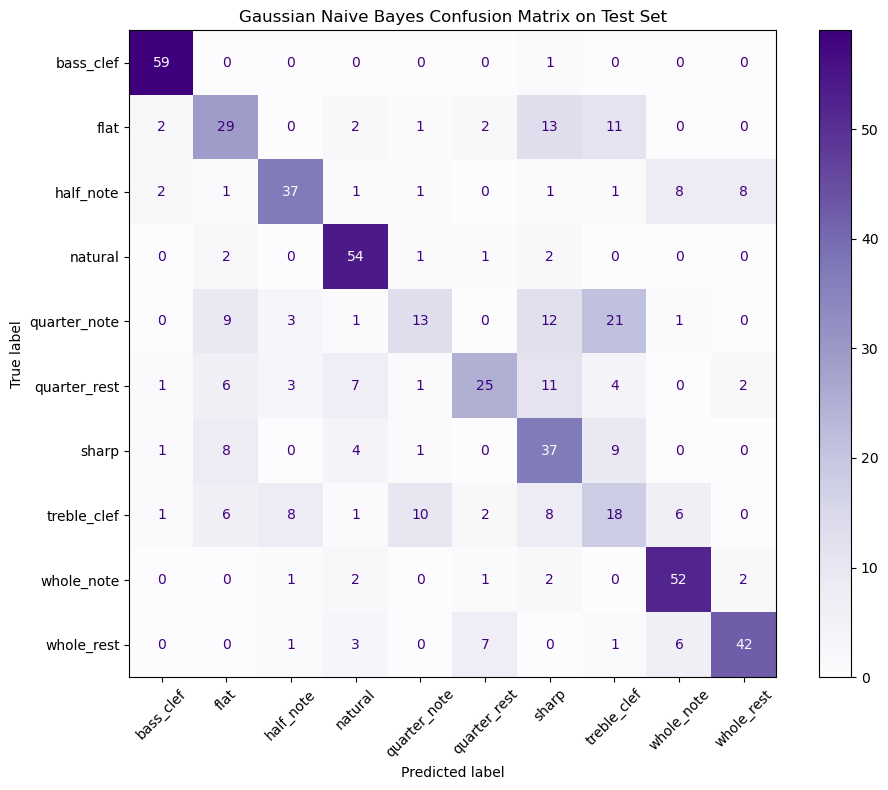

In [124]:
# step 8, part 5: Gaussian Naive Bayes confusion matrix

cm_gnb = confusion_matrix(y_test, y_test_pred_gnb)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_gnb,
    display_labels=class_names
)

disp.plot(
    cmap="Purples",
    xticks_rotation=45,
    values_format="d",
    ax=ax
)

plt.title("Gaussian Naive Bayes Confusion Matrix on Test Set")
plt.tight_layout()
plt.show()


The Gaussian Naive Bayes confusion matrix shows stronger diagonal performance for selected classes such as `bass_clef`, `natural`, `whole_note`, and `whole_rest`. This indicates that the model was able to recognise some visually distinctive symbol categories with reasonable consistency.

However, the confusion matrix also reveals substantial off-diagonal errors for several visually similar or structurally complex classes. In particular, `quarter_note`, `treble_clef`, `flat`, and `sharp` show weaker class separation, which is consistent with their lower precision, recall, and F1-score values in the classification report.

These misclassification patterns suggest that Gaussian Naive Bayes was unable to fully capture the spatial dependencies present in the flattened pixel representation. Since image pixels are not independent of one another, the model’s conditional independence assumption is likely too simple for this symbolic image classification task.

Overall, the confusion matrix supports the conclusion that Gaussian Naive Bayes provides a meaningful probabilistic baseline, but performs less effectively than the stronger discriminative classifiers evaluated later.

In [126]:
# step 8, part 6: Gaussian Naive Bayes clean vs mild-noise robustness evaluation

y_test_clean_pred_gnb = gnb_final.predict(X_test_clean)
y_test_noise_pred_gnb = gnb_final.predict(X_test_noise)

clean_accuracy_gnb = accuracy_score(
    y_test_clean,
    y_test_clean_pred_gnb
)

noise_accuracy_gnb = accuracy_score(
    y_test_noise,
    y_test_noise_pred_gnb
)

accuracy_drop_gnb = clean_accuracy_gnb - noise_accuracy_gnb

gnb_robustness_summary = pd.DataFrame([{
    "model": "Gaussian_Naive_Bayes",
    "clean_test_accuracy": clean_accuracy_gnb,
    "mild_noise_test_accuracy": noise_accuracy_gnb,
    "accuracy_drop_clean_to_noise": accuracy_drop_gnb,
}])

print("Gaussian Naive Bayes robustness evaluation:")
display(gnb_robustness_summary.round(4))


Gaussian Naive Bayes robustness evaluation:


,model,clean_test_accuracy,mild_noise_test_accuracy,accuracy_drop_clean_to_noise
0,Gaussian_Naive_Bayes,0.6967,0.5233,0.1733


Gaussian Naive Bayes achieved a clean-test accuracy of **0.6967** and a mild-noise test accuracy of **0.5233**, producing a clean-to-noise accuracy drop of **0.1733**.

The accuracy drop is smaller than the drops observed for raw kNN, PCA-enhanced kNN, and Decision Tree. This suggests that Gaussian Naive Bayes was relatively less affected by perturbations in proportional terms.

However, this smaller robustness drop should be interpreted carefully. Although the model’s performance declined less sharply under the `mild_noise` condition, its absolute accuracy remained low compared with the stronger classifiers. Therefore, Gaussian Naive Bayes should not be considered highly robust overall; rather, it is a lower-performing baseline whose clean and perturbed accuracies were both relatively modest.

This result highlights the importance of interpreting robustness drop together with absolute predictive performance.

In [127]:
# step 8, part 7: store Gaussian Naive Bayes results

gnb_results = {
    "model": "Gaussian_Naive_Bayes",
    "validation_accuracy": val_accuracy_gnb,
    "test_accuracy": test_accuracy_gnb,
    "clean_test_accuracy": clean_accuracy_gnb,
    "mild_noise_test_accuracy": noise_accuracy_gnb,
    "accuracy_drop_clean_to_noise": accuracy_drop_gnb,

    # Parameters not applicable to Gaussian Naive Bayes
    "best_k": np.nan,
    "pca_components": np.nan,
    "max_depth": np.nan,
    "tree_depth": np.nan,
    "n_leaves": np.nan,
    "svm_C": np.nan,
    "svm_gamma": np.nan,
}

gnb_results_df = pd.DataFrame([gnb_results])

print("Stored Gaussian Naive Bayes results:")
display(gnb_results_df.round(4))


Stored Gaussian Naive Bayes results:


,model,validation_accuracy,test_accuracy,clean_test_accuracy,mild_noise_test_accuracy,accuracy_drop_clean_to_noise,best_k,pca_components,max_depth,tree_depth,n_leaves,svm_C,svm_gamma
0,Gaussian_Naive_Bayes,0.5967,0.61,0.6967,0.5233,0.1733,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The Gaussian Naive Bayes results were stored in the supervised model comparison dataframe for later cross-model evaluation. The stored metrics include validation accuracy, held-out test accuracy, clean-test accuracy, mild-noise accuracy, and clean-to-noise accuracy drop.

The model achieved a validation accuracy of **0.5967**, a held-out test accuracy of **0.6100**, a clean-test accuracy of **0.6967**, and a mild-noise accuracy of **0.5233**. This produced a clean-to-noise accuracy drop of **0.1733**.

Parameters that do not apply to Gaussian Naive Bayes, such as `best_k`, `pca_components`, `max_depth`, and SVM-specific parameters, were recorded as missing values. This preserves a consistent comparison-table structure across all evaluated classifiers.

Overall, the stored results confirm that Gaussian Naive Bayes provides a useful probabilistic baseline, but its overall performance remains weaker than the kNN-based models, Decision Tree, Logistic Regression, and SVM.

In [128]:
# step 8, part 8: update supervised model comparison

# supervised_results contains:
# kNN from scratch, PCA+kNN from scratch, and Decision Tree.
# Gaussian Naive Bayes is added here to create supervised_results_extended.

base_supervised_results = supervised_results.copy()

# prevent duplicate Gaussian NB rows if this cell is re-run
base_supervised_results = base_supervised_results[
    base_supervised_results["model"] != "Gaussian_Naive_Bayes"
].copy()

supervised_results_extended = pd.concat(
    [
        base_supervised_results,
        gnb_results_df
    ],
    ignore_index=True
)

supervised_results_extended = supervised_results_extended.drop_duplicates(
    subset=["model"],
    keep="last"
).reset_index(drop=True)

supervised_results_extended = supervised_results_extended.sort_values(
    by="test_accuracy",
    ascending=False
).reset_index(drop=True)

print("Interim supervised model comparison including Gaussian Naive Bayes:")
display(supervised_results_extended.round(4))


Interim supervised model comparison including Gaussian Naive Bayes:


,model,validation_accuracy,test_accuracy,clean_test_accuracy,mild_noise_test_accuracy,accuracy_drop_clean_to_noise,best_k,pca_components,max_depth,tree_depth,n_leaves,svm_C,svm_gamma
0,PCA_plus_kNN_from_scratch,0.7467,0.7567,0.8967,0.6167,0.2800,3.0,20.0,NaN,NaN,NaN,NaN,NaN
1,kNN_from_scratch,0.7300,0.7200,0.8700,0.5700,0.3000,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2,Decision_Tree,0.6417,0.6400,0.8567,0.4233,0.4333,NaN,NaN,20.0,20.0,288.0,NaN,NaN
3,Gaussian_Naive_Bayes,0.5967,0.6100,0.6967,0.5233,0.1733,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The interim supervised model comparison table now includes raw-pixel kNN, PCA-enhanced kNN, Decision Tree, and Gaussian Naive Bayes. At this stage of the experiment, the **PCA-enhanced kNN** model remains the strongest classifier, achieving the highest held-out test accuracy of **0.7567** and the highest mild-noise accuracy of **0.6167** among the models evaluated so far.

The raw-pixel kNN model ranked second in this interim comparison, with a test accuracy of **0.7200** and a mild-noise accuracy of **0.5700**. This indicates that the from-scratch kNN approach remained competitive, although dimensionality reduction improved performance when PCA was applied.

The Decision Tree achieved a test accuracy of **0.6400**, but showed the largest clean-to-noise accuracy drop of **0.4333**, indicating strong sensitivity to mild perturbations.

Gaussian Naive Bayes achieved the lowest overall test accuracy of **0.6100**, but it produced the smallest clean-to-noise accuracy drop of **0.1733** among the models in this interim comparison. This suggests that although Gaussian Naive Bayes was relatively stable in terms of accuracy decline, its absolute predictive performance remained weak.

Overall, the interim comparison shows that PCA+kNN is still the strongest model at this stage, while Gaussian Naive Bayes serves as a useful but lower-performing probabilistic baseline. Further classifiers are evaluated before the final supervised model comparison.

In [129]:
# step 8, part 9: final Gaussian Naive Bayes summary

print("Gaussian Naive Bayes classifier comparison completed successfully.")
print(f"Validation accuracy:      {val_accuracy_gnb:.4f}")
print(f"Test accuracy:            {test_accuracy_gnb:.4f}")
print(f"Clean test accuracy:      {clean_accuracy_gnb:.4f}")
print(f"Mild-noise test accuracy: {noise_accuracy_gnb:.4f}")
print(f"Accuracy drop:            {accuracy_drop_gnb:.4f}")


Gaussian Naive Bayes classifier comparison completed successfully.
Validation accuracy:      0.5967
Test accuracy:            0.6100
Clean test accuracy:      0.6967
Mild-noise test accuracy: 0.5233
Accuracy drop:            0.1733


Step 8 completed the Gaussian Naive Bayes evaluation. The model achieved a validation accuracy of **0.5967** and a held-out test accuracy of **0.6100**.

Robustness analysis showed that performance decreased from **0.6967** on clean test images to **0.5233** on mild-noise test images, resulting in a clean-to-noise accuracy drop of **0.1733**. Although this drop was smaller than those observed for raw kNN, PCA-enhanced kNN, and Decision Tree, the model’s absolute accuracy remained comparatively low.

These results indicate that Gaussian Naive Bayes is useful as a probabilistic baseline, but it is not the strongest classifier for this dataset. Its weaker performance is likely due to the conditional independence assumption, which is poorly matched to image data where neighbouring pixel features are spatially correlated.

Overall, Gaussian Naive Bayes provides a meaningful benchmark for comparison, but later discriminative models, particularly Logistic Regression and SVM, are expected to offer stronger classification performance.

**Step 9: Logistic Regression Classifier Training and Evaluation**

In [130]:
# step 9, part 1: logistic regression classifier setup

"""
Logistic Regression Classifier Training and Evaluation
------------------------------------------------------

This section trains and evaluates a multinomial Logistic Regression classifier
as a linear discriminative baseline for multi-class music symbol classification.

The model is evaluated on:
- validation set
- test set
- clean test subset
- mild_noise test subset

The resulting performance row is stored for later comparison with the other
supervised classifiers.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

print("Logistic Regression setup completed successfully.")


Logistic Regression setup completed successfully.


Logistic Regression was included as a linear discriminative baseline for multi-class music symbol classification. Unlike kNN, which relies on distance-based neighbourhood voting, Logistic Regression learns decision boundaries between classes using the training data. This makes it useful for assessing how well the flattened pixel features can be separated using a linear model.

In [131]:
# step 9, part 2: train logistic regression model

logreg_final = LogisticRegression(
    solver="lbfgs",
    max_iter=2000,
    random_state=42,
    n_jobs=-1
)

logreg_final.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


The Logistic Regression model was trained using the flattened 4096-dimensional pixel features. The `lbfgs` solver was used with an increased maximum iteration limit to support convergence on the multi-class classification task. A fixed random state was used to support reproducibility.

In [132]:
# step 9, part 3: validation and test evaluation

y_val_pred_logreg = logreg_final.predict(X_val)
y_test_pred_logreg = logreg_final.predict(X_test)

val_accuracy_logreg = accuracy_score(y_val, y_val_pred_logreg)
test_accuracy_logreg = accuracy_score(y_test, y_test_pred_logreg)

logreg_performance_summary = pd.DataFrame([{
    "model": "Logistic_Regression",
    "validation_accuracy": val_accuracy_logreg,
    "test_accuracy": test_accuracy_logreg,
}])

print("Logistic Regression performance summary:")
display(logreg_performance_summary.round(4))


Logistic Regression performance summary:


,model,validation_accuracy,test_accuracy
0,Logistic_Regression,0.785,0.7983


The Logistic Regression classifier achieved a validation accuracy of **0.7850** and a held-out test accuracy of **0.7983**. The close correspondence between validation and test performance suggests that the model generalised consistently to unseen samples, without showing a large discrepancy between model-selection performance and final test-set performance.

This result is stronger than the earlier raw kNN, PCA-enhanced kNN, Decision Tree, and Gaussian Naive Bayes models. It therefore provides a competitive linear discriminative baseline for the flattened 4096-dimensional pixel feature representation.

In [133]:
# step 9, part 4: logistic regression classification report

logreg_report = classification_report(
    y_test,
    y_test_pred_logreg,
    target_names=class_names,
    output_dict=True
)

logreg_report_df = pd.DataFrame(logreg_report).transpose()

print("Logistic Regression classification report on test set:")
display(logreg_report_df.round(4))


Logistic Regression classification report on test set:


,precision,recall,f1-score,support
bass_clef,1.0000,0.9667,0.9831,60.0000
flat,0.7188,0.7667,0.7419,60.0000
half_note,0.8308,0.9000,0.8640,60.0000
natural,0.9643,0.9000,0.9310,60.0000
quarter_note,0.4828,0.4667,0.4746,60.0000
quarter_rest,0.8500,0.8500,0.8500,60.0000
sharp,0.8654,0.7500,0.8036,60.0000
treble_clef,0.4923,0.5333,0.5120,60.0000
whole_note,0.9032,0.9333,0.9180,60.0000
whole_rest,0.9167,0.9167,0.9167,60.0000


The Logistic Regression classification report shows an overall held-out test accuracy of **0.7983**, with a macro F1-score of **0.7995** and a weighted F1-score of **0.7995**. Since each class contains **60 test samples**, the macro and weighted averages are identical.

The model performs strongly on several visually distinctive classes, including `bass_clef`, `natural`, `half_note`, `quarter_rest`, `whole_note`, and `whole_rest`. These classes achieved comparatively high precision, recall, and F1-score values, indicating that their flattened pixel representations were sufficiently separable using a linear decision boundary.

However, `quarter_note` and `treble_clef` remained more difficult to classify. The `quarter_note` class achieved an F1-score of **0.4746**, while `treble_clef` achieved an F1-score of **0.5120**. This suggests that these visually complex or structurally overlapping symbols were harder to separate using a linear model.

Overall, Logistic Regression provides stronger class-wise performance than the earlier kNN, Decision Tree, and Gaussian Naive Bayes models, while also serving as a useful baseline before comparison with the final non-linear SVM classifier.

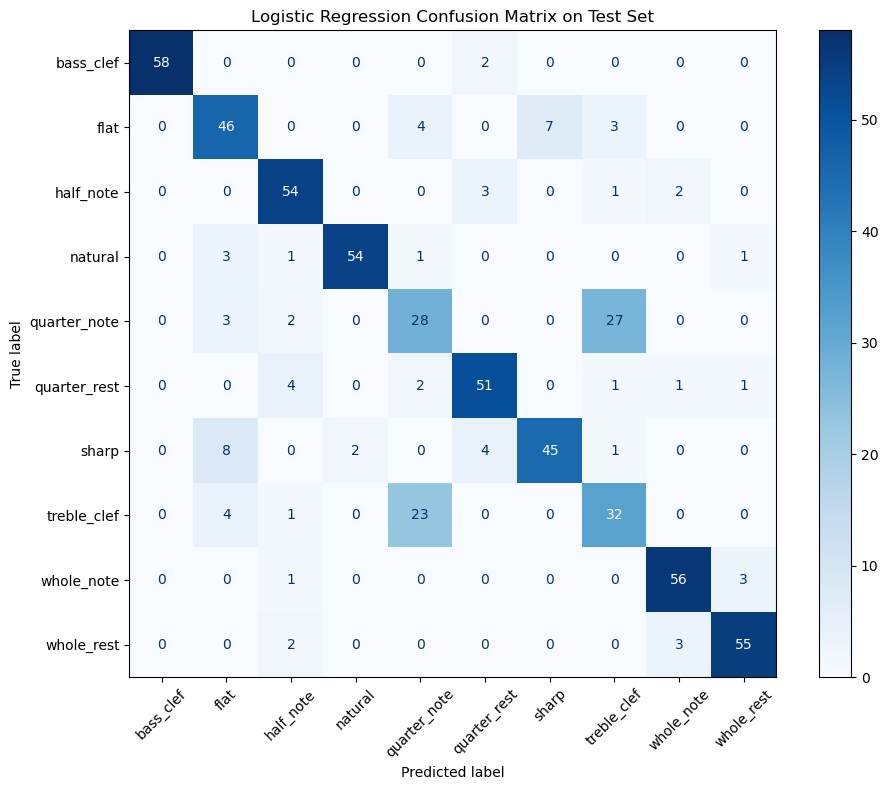

In [134]:
# step 9, part 5: logistic regression confusion matrix

cm_logreg = confusion_matrix(y_test, y_test_pred_logreg)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logreg,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format="d",
    ax=ax
)

plt.title("Logistic Regression Confusion Matrix on Test Set")
plt.tight_layout()
plt.show()


The Logistic Regression confusion matrix shows strong diagonal performance for several classes, including `bass_clef`, `natural`, `half_note`, `quarter_rest`, `whole_note`, and `whole_rest`. This confirms that the linear classifier was able to correctly identify many of the more visually distinctive music-symbol categories.

The main source of confusion remains between `quarter_note` and `treble_clef`. These classes were more frequently misclassified than most other categories, which is consistent with their lower F1-scores in the classification report. This suggests that their curved or visually complex structures may overlap in the flattened pixel feature space after resizing and perturbation.

Overall, the confusion matrix indicates that Logistic Regression performs well as a linear supervised classifier, but it still struggles with visually ambiguous symbol classes. This motivates the later use of a non-linear RBF-kernel SVM, which may capture more complex decision boundaries.

In [135]:
# step 9, part 6: logistic regression clean vs mild-noise robustness evaluation

y_test_clean_pred_logreg = logreg_final.predict(X_test_clean)
y_test_noise_pred_logreg = logreg_final.predict(X_test_noise)

clean_accuracy_logreg = accuracy_score(
    y_test_clean,
    y_test_clean_pred_logreg
)

noise_accuracy_logreg = accuracy_score(
    y_test_noise,
    y_test_noise_pred_logreg
)

accuracy_drop_logreg = clean_accuracy_logreg - noise_accuracy_logreg

logreg_robustness_summary = pd.DataFrame([{
    "model": "Logistic_Regression",
    "clean_test_accuracy": clean_accuracy_logreg,
    "mild_noise_test_accuracy": noise_accuracy_logreg,
    "accuracy_drop_clean_to_noise": accuracy_drop_logreg,
}])

print("Logistic Regression robustness evaluation:")
display(logreg_robustness_summary.round(4))


Logistic Regression robustness evaluation:


,model,clean_test_accuracy,mild_noise_test_accuracy,accuracy_drop_clean_to_noise
0,Logistic_Regression,0.8867,0.71,0.1767


Logistic Regression achieved a clean-test accuracy of **0.8867** and a mild-noise test accuracy of **0.7100**, producing a clean-to-noise accuracy drop of **0.1767**.

This indicates that Logistic Regression was affected by controlled perturbations, including mild noise, rotation, scaling, and translation. However, its robustness remained stronger than the raw kNN, PCA-enhanced kNN, and Decision Tree models under the `mild_noise` condition.

Although Logistic Regression provides a relatively stable linear baseline, its robustness remains lower than the final SVM model. This suggests that the linear decision boundary captured meaningful class structure, but was less effective than the non-linear SVM in maintaining performance under perturbation.

In [136]:
# step 9, part 7: store logistic regression results

logreg_results = {
    "model": "Logistic_Regression",
    "validation_accuracy": val_accuracy_logreg,
    "test_accuracy": test_accuracy_logreg,
    "clean_test_accuracy": clean_accuracy_logreg,
    "mild_noise_test_accuracy": noise_accuracy_logreg,
    "accuracy_drop_clean_to_noise": accuracy_drop_logreg,

    # Parameters not applicable to Logistic Regression
    "best_k": np.nan,
    "pca_components": np.nan,
    "max_depth": np.nan,
    "tree_depth": np.nan,
    "n_leaves": np.nan,
    "svm_C": np.nan,
    "svm_gamma": np.nan,
}

logreg_results_df = pd.DataFrame([logreg_results])

print("Stored Logistic Regression results:")
display(logreg_results_df.round(4))


Stored Logistic Regression results:


,model,validation_accuracy,test_accuracy,clean_test_accuracy,mild_noise_test_accuracy,accuracy_drop_clean_to_noise,best_k,pca_components,max_depth,tree_depth,n_leaves,svm_C,svm_gamma
0,Logistic_Regression,0.785,0.7983,0.8867,0.71,0.1767,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The Logistic Regression results were stored in the supervised model comparison dataframe for later cross-model evaluation. The stored metrics include validation accuracy, held-out test accuracy, clean-test accuracy, mild-noise accuracy, clean-to-noise accuracy drop, and model-specific hyperparameter fields.

The model achieved a validation accuracy of **0.7850**, a held-out test accuracy of **0.7983**, a clean-test accuracy of **0.8867**, and a mild-noise accuracy of **0.7100**. The resulting clean-to-noise accuracy drop was **0.1767**.

These results show that Logistic Regression is affected by perturbations, but remains more robust than several earlier models, particularly the kNN-based models and the Decision Tree. Its relatively high test accuracy and mild-noise accuracy make it a strong linear supervised baseline before evaluating the final SVM classifier.

In [138]:
# step 9, part 8: final logistic regression summary

print("Logistic Regression classifier comparison completed successfully.")
print(f"Validation accuracy:      {val_accuracy_logreg:.4f}")
print(f"Test accuracy:            {test_accuracy_logreg:.4f}")
print(f"Clean test accuracy:      {clean_accuracy_logreg:.4f}")
print(f"Mild-noise test accuracy: {noise_accuracy_logreg:.4f}")
print(f"Accuracy drop:            {accuracy_drop_logreg:.4f}")


Logistic Regression classifier comparison completed successfully.
Validation accuracy:      0.7850
Test accuracy:            0.7983
Clean test accuracy:      0.8867
Mild-noise test accuracy: 0.7100
Accuracy drop:            0.1767


Step 9 completed the Logistic Regression evaluation. The model achieved a validation accuracy of **0.7850** and a held-out test accuracy of **0.7983**.

Robustness analysis showed that performance decreased from **0.8867** on clean test images to **0.7100** on mild-noise test images, giving a clean-to-noise accuracy drop of **0.1767**. This indicates that Logistic Regression was moderately affected by controlled perturbations, but remained more stable than several earlier models.

Overall, Logistic Regression provides a strong linear supervised baseline for the final model comparison. Its performance is substantially stronger than Decision Tree and Gaussian Naive Bayes, and it also outperforms the kNN-based models in overall test accuracy and mild-noise accuracy.

**Step 10: Support Vector Machine Classifier Training and Final Model Comparison**

In [140]:
# step 10, part 1: support vector machine classifier setup

"""
Support Vector Machine Classifier Training and Final Model Comparison
---------------------------------------------------------------------

This section trains and evaluates a Support Vector Machine (SVM) classifier
using a radial basis function (RBF) kernel. A small validation-based
hyperparameter search is performed over selected C and gamma values.

The final SVM model is evaluated on:
- validation set
- test set
- clean test subset
- mild_noise test subset

Since SVM is the final supervised classifier in this experiment, this step
also creates the final supervised model comparison table and ranking.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

print("SVM setup completed successfully.")


SVM setup completed successfully.


The Support Vector Machine classifier was included as a non-linear supervised learning model using an RBF kernel. This allows the model to learn non-linear decision boundaries in the flattened image feature space. A small validation-based hyperparameter search was used to compare selected values of `C` and `gamma`.

In [142]:
# step 10, part 2: SVM validation-based hyperparameter search

svm_param_grid = [
    {"C": 0.1, "gamma": "scale"},
    {"C": 1.0, "gamma": "scale"},
    {"C": 10.0, "gamma": "scale"},
    {"C": 1.0, "gamma": 0.001},
    {"C": 10.0, "gamma": 0.001},
]

svm_validation_results = []

for params in svm_param_grid:
    svm_model = SVC(
        kernel="rbf",
        C=params["C"],
        gamma=params["gamma"],
        random_state=42
    )

    svm_model.fit(X_train, y_train)

    y_val_pred_svm = svm_model.predict(X_val)
    val_accuracy = accuracy_score(y_val, y_val_pred_svm)

    svm_validation_results.append({
        "C": params["C"],
        "gamma": params["gamma"],
        "validation_accuracy": val_accuracy
    })

svm_validation_df = pd.DataFrame(svm_validation_results)

print("SVM validation search results:")
display(svm_validation_df.round(4))


SVM validation search results:


,C,gamma,validation_accuracy
0,0.1,scale,0.6167
1,1.0,scale,0.8300
2,10.0,scale,0.8400
3,1.0,0.001,0.7700
4,10.0,0.001,0.8450


The Support Vector Machine validation search evaluated selected combinations of the regularisation parameter `C` and the RBF-kernel coefficient `gamma`. These hyperparameters influence the balance between model regularisation, margin flexibility, and the complexity of the resulting non-linear decision boundary.

The weakest configuration was obtained using `C = 0.1` with `gamma = scale`, which achieved a validation accuracy of **0.6167**. This suggests that the regularisation constraint was too strong, limiting the model’s ability to form sufficiently flexible class boundaries within the high-dimensional music-symbol feature space.

Increasing `C` led to a substantial improvement in validation performance. With `gamma = scale`, validation accuracy increased from **0.8300** at `C = 1.0` to **0.8400** at `C = 10.0`. This indicates that the SVM benefited from a less restrictive regularisation setting.

The strongest validation performance was achieved using `C = 10.0` and `gamma = 0.001`, producing the highest validation accuracy of **0.8450** among the tested configurations. This configuration was therefore selected for training the final RBF-kernel SVM model.

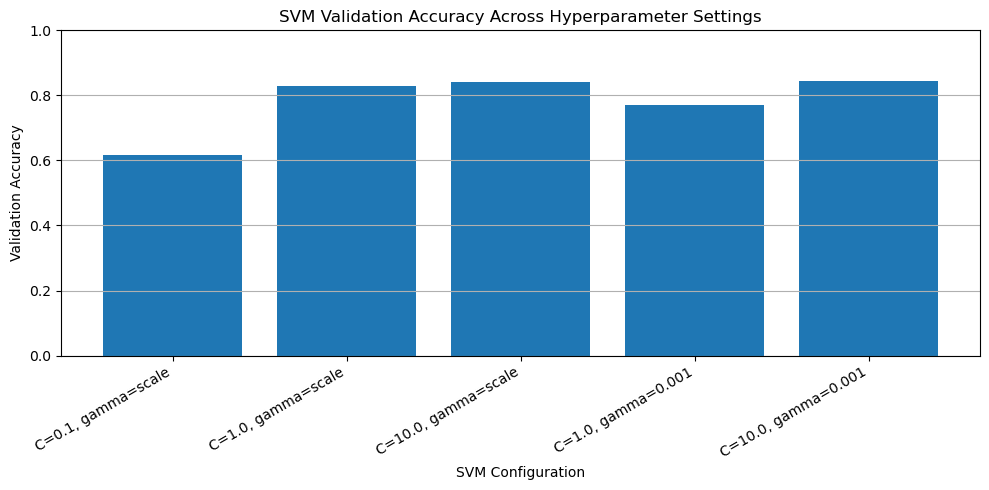

In [143]:
# step 10, part 3: SVM validation results plot

svm_validation_plot_df = svm_validation_df.copy()
svm_validation_plot_df["configuration"] = svm_validation_plot_df.apply(
    lambda row: f"C={row['C']}, gamma={row['gamma']}",
    axis=1
)

plt.figure(figsize=(10, 5))

plt.bar(
    svm_validation_plot_df["configuration"],
    svm_validation_plot_df["validation_accuracy"]
)

plt.xlabel("SVM Configuration")
plt.ylabel("Validation Accuracy")
plt.title("SVM Validation Accuracy Across Hyperparameter Settings")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.tight_layout()
plt.show()


The Support Vector Machine validation search evaluated selected combinations of the regularisation parameter `C` and the RBF-kernel coefficient `gamma`. These hyperparameters control the trade-off between margin flexibility and decision-boundary complexity.

The weakest configuration was `C = 0.1` with `gamma = scale`, which achieved a validation accuracy of **0.6167**. This suggests that the regularisation constraint was too strong and limited the model’s capacity to separate the high-dimensional music-symbol representations.

Validation accuracy improved substantially as `C` increased. The strongest configuration was obtained using `C = 10.0` and `gamma = 0.001`, achieving the highest validation accuracy of **0.8450**. This configuration was therefore selected for the final RBF-kernel SVM model.

In [145]:
# step 10, part 4: select best SVM configuration

best_svm_row = (
    svm_validation_df
    .sort_values(by="validation_accuracy", ascending=False)
    .iloc[0]
)

best_svm_C = float(best_svm_row["C"])
best_svm_gamma = best_svm_row["gamma"]

best_svm_summary = pd.DataFrame([{
    "selected_C": best_svm_C,
    "selected_gamma": best_svm_gamma,
    "validation_accuracy": best_svm_row["validation_accuracy"],
}])

print("Best SVM configuration selected from validation set:")
display(best_svm_summary.round(4))


Best SVM configuration selected from validation set:


,selected_C,selected_gamma,validation_accuracy
0,10.0,0.001,0.845


The validation search selected `C = 10.0` and `gamma = 0.001` as the final SVM hyperparameter configuration. This setting achieved the highest validation accuracy of **0.8450** among the tested RBF-kernel configurations.

This selected configuration was used to train the final SVM classifier before evaluating its performance on the validation, held-out test, clean-test, and mild-noise test subsets.

In [146]:
# step 10, part 5: train final SVM model

svm_final = SVC(
    kernel="rbf",
    C=best_svm_C,
    gamma=best_svm_gamma,
    random_state=42
)

svm_final.fit(X_train, y_train)

print("Final SVM model trained successfully.")
print(f"Selected C:     {best_svm_C}")
print(f"Selected gamma: {best_svm_gamma}")


Final SVM model trained successfully.
Selected C:     10.0
Selected gamma: 0.001


The final Support Vector Machine model was trained using the selected hyperparameter configuration of `C = 10.0` and `gamma = 0.001`. These values were chosen based on the validation search results, where they produced the highest validation accuracy.

The RBF kernel allows the SVM to construct non-linear decision boundaries in the transformed feature space. This is useful for symbolic image classification because flattened pixel features may contain non-linear class structures that cannot be fully separated using a purely linear classifier.

In [147]:
# step 10, part 6: final SVM validation and test evaluation

y_val_pred_svm = svm_final.predict(X_val)
y_test_pred_svm = svm_final.predict(X_test)

val_accuracy_svm = accuracy_score(y_val, y_val_pred_svm)
test_accuracy_svm = accuracy_score(y_test, y_test_pred_svm)

svm_performance_summary = pd.DataFrame([{
    "model": "Support_Vector_Machine",
    "C": best_svm_C,
    "gamma": best_svm_gamma,
    "validation_accuracy": val_accuracy_svm,
    "test_accuracy": test_accuracy_svm,
}])

print("Final SVM performance summary:")
display(svm_performance_summary.round(4))


Final SVM performance summary:


,model,C,gamma,validation_accuracy,test_accuracy
0,Support_Vector_Machine,10.0,0.001,0.845,0.8667


The final RBF-kernel SVM model achieved a validation accuracy of **0.8450** and a held-out test accuracy of **0.8667** using `C = 10.0` and `gamma = 0.001`.

This is the strongest test accuracy obtained among the evaluated supervised classifiers. The result indicates that the SVM generalised effectively to unseen test images and provides a strong final classifier for the music-symbol classification task.

In [148]:
# step 10, part 7: SVM classification report

svm_report = classification_report(
    y_test,
    y_test_pred_svm,
    target_names=class_names,
    output_dict=True
)

svm_report_df = pd.DataFrame(svm_report).transpose()

print("SVM classification report on test set:")
display(svm_report_df.round(4))


SVM classification report on test set:


,precision,recall,f1-score,support
bass_clef,1.0000,1.0000,1.0000,60.0000
flat,0.8710,0.9000,0.8852,60.0000
half_note,0.9516,0.9833,0.9672,60.0000
natural,0.9365,0.9833,0.9593,60.0000
quarter_note,0.5286,0.6167,0.5692,60.0000
quarter_rest,0.9483,0.9167,0.9322,60.0000
sharp,0.9259,0.8333,0.8772,60.0000
treble_clef,0.5385,0.4667,0.5000,60.0000
whole_note,0.9836,1.0000,0.9917,60.0000
whole_rest,1.0000,0.9667,0.9831,60.0000


The SVM classification report shows an overall held-out test accuracy of **0.8667**, with a macro F1-score of **0.8665** and a weighted F1-score of **0.8665**. Because the test set is balanced, with **60 samples per class**, the macro and weighted averages are nearly identical.

The model achieved very strong performance for several classes, including `bass_clef`, `half_note`, `natural`, `quarter_rest`, `whole_note`, and `whole_rest`. These classes achieved high precision, recall, and F1-score values, suggesting that their visual structures were more consistently separable in the flattened pixel feature space.

However, `quarter_note` and `treble_clef` remained more difficult to classify. The `quarter_note` class achieved an F1-score of **0.5692**, while `treble_clef` achieved an F1-score of **0.5000**. This suggests that these two visually complex or curved symbols produced greater ambiguity after resizing and mild perturbation.

Overall, the classification report confirms that the SVM provided the strongest class-wise performance among the evaluated models, while also highlighting that some symbol categories remained more challenging than others.

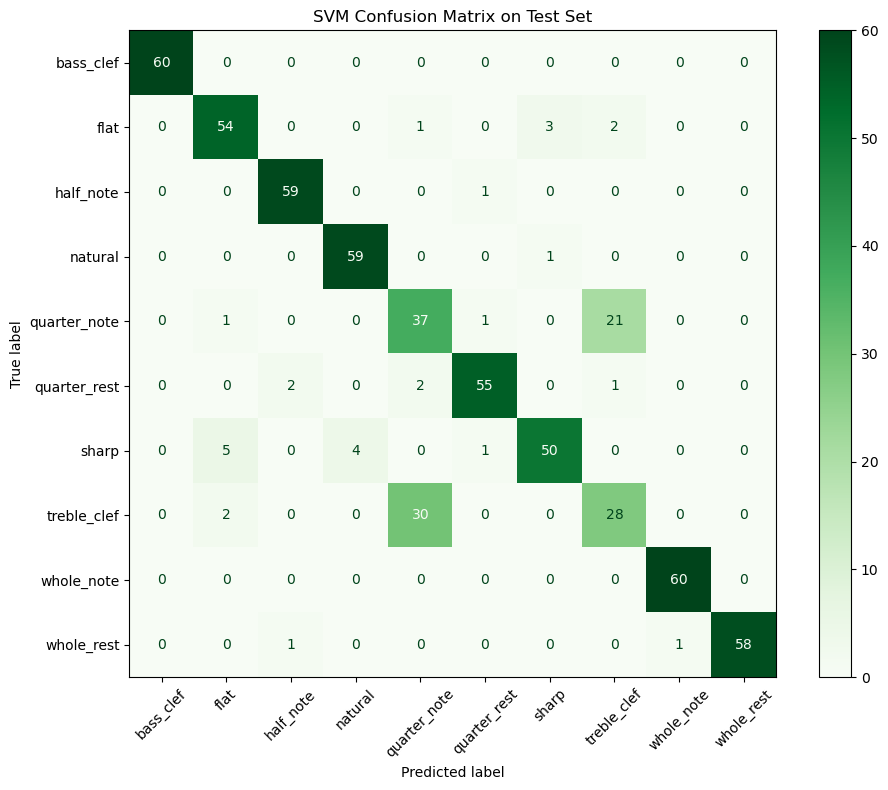

In [149]:
# step 10, part 8: SVM confusion matrix

cm_svm = confusion_matrix(y_test, y_test_pred_svm)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=class_names
)

disp.plot(
    cmap="Greens",
    xticks_rotation=45,
    values_format="d",
    ax=ax
)

plt.title("SVM Confusion Matrix on Test Set")
plt.tight_layout()
plt.show()


The SVM confusion matrix shows strong diagonal performance for most classes, indicating that the model correctly classified a large proportion of test samples across the ten music-symbol categories.

Classes such as `bass_clef`, `half_note`, `natural`, `quarter_rest`, `whole_note`, and `whole_rest` show particularly strong classification behaviour. This supports the classification report, where these classes achieved high precision, recall, and F1-score values.

The main remaining confusion occurs between `quarter_note` and `treble_clef`, which were among the lowest-performing classes in the classification report. This suggests that their visual structures may partially overlap after normalisation, resizing, and perturbation. Smaller confusion is also observed between visually related accidental symbols such as `flat` and `sharp`.

Overall, the confusion matrix confirms that the SVM achieved strong class separation for most symbol categories, while also revealing specific areas of visual ambiguity that limit perfect classification performance.

In [150]:
# step 10, part 9: SVM clean vs mild-noise robustness evaluation

y_test_clean_pred_svm = svm_final.predict(X_test_clean)
y_test_noise_pred_svm = svm_final.predict(X_test_noise)

clean_accuracy_svm = accuracy_score(y_test_clean, y_test_clean_pred_svm)
noise_accuracy_svm = accuracy_score(y_test_noise, y_test_noise_pred_svm)

accuracy_drop_svm = clean_accuracy_svm - noise_accuracy_svm

svm_robustness_summary = pd.DataFrame([{
    "model": "Support_Vector_Machine",
    "clean_test_accuracy": clean_accuracy_svm,
    "mild_noise_test_accuracy": noise_accuracy_svm,
    "accuracy_drop_clean_to_noise": accuracy_drop_svm,
}])

print("SVM robustness evaluation:")
display(svm_robustness_summary.round(4))


SVM robustness evaluation:


,model,clean_test_accuracy,mild_noise_test_accuracy,accuracy_drop_clean_to_noise
0,Support_Vector_Machine,0.9033,0.83,0.0733


The SVM achieved a clean-test accuracy of **0.9033** and a mild-noise test accuracy of **0.8300**, resulting in a clean-to-noise accuracy drop of only **0.0733**.

This indicates that the SVM maintained strong predictive performance even when controlled perturbations were introduced. The relatively small drop suggests that the RBF-kernel decision boundary was robust to mild rotation, scaling, translation, and Gaussian noise.

Compared with the other evaluated classifiers, the SVM achieved both the highest mild-noise accuracy and the smallest clean-to-noise accuracy drop. This confirms that it was the most stable model under the `mild_noise` condition.

In [151]:
# step 10, part 10: store SVM results

svm_results = {
    "model": "Support_Vector_Machine",
    "validation_accuracy": val_accuracy_svm,
    "test_accuracy": test_accuracy_svm,
    "clean_test_accuracy": clean_accuracy_svm,
    "mild_noise_test_accuracy": noise_accuracy_svm,
    "accuracy_drop_clean_to_noise": accuracy_drop_svm,

    # Parameters not applicable to SVM
    "best_k": np.nan,
    "pca_components": np.nan,
    "max_depth": np.nan,
    "tree_depth": np.nan,
    "n_leaves": np.nan,

    # SVM-specific parameters
    "svm_C": best_svm_C,
    "svm_gamma": best_svm_gamma,
}

svm_results_df = pd.DataFrame([svm_results])

print("Stored SVM results:")
display(svm_results_df.round(4))


Stored SVM results:


,model,validation_accuracy,test_accuracy,clean_test_accuracy,mild_noise_test_accuracy,accuracy_drop_clean_to_noise,best_k,pca_components,max_depth,tree_depth,n_leaves,svm_C,svm_gamma
0,Support_Vector_Machine,0.845,0.8667,0.9033,0.83,0.0733,NaN,NaN,NaN,NaN,NaN,10.0,0.001


The SVM results were stored in the supervised model comparison dataframe to support final cross-model evaluation. The stored metrics include validation accuracy, held-out test accuracy, clean-test accuracy, mild-noise accuracy, clean-to-noise accuracy drop, and selected SVM hyperparameters.

The final SVM model achieved a validation accuracy of **0.8450**, a held-out test accuracy of **0.8667**, a clean-test accuracy of **0.9033**, and a mild-noise accuracy of **0.8300**. Its clean-to-noise accuracy drop was **0.0733**, indicating strong robustness under controlled perturbation.

Non-applicable parameters such as `best_k`, `pca_components`, and `max_depth` were recorded as missing values to preserve a consistent comparison-table structure across all classifiers.

In [152]:
# step 10, part 11: create final supervised model comparison

if "logreg_results_df" not in globals():
    raise NameError(
        "logreg_results_df is not defined. "
        "Please run Step 9 before running Step 10."
    )

if "supervised_results_extended" not in globals():
    raise NameError(
        "supervised_results_extended is not defined. "
        "Please run Step 8 before running Step 10."
    )

# supervised_results_extended currently contains:
# kNN, PCA+kNN, Decision Tree, and Gaussian Naive Bayes.
# Logistic Regression and SVM are added here because SVM is the final classifier step.

base_supervised_results = supervised_results_extended.copy()

# Prevent duplicate rows if this cell is re-run
base_supervised_results = base_supervised_results[
    ~base_supervised_results["model"].isin([
        "Logistic_Regression",
        "Support_Vector_Machine"
    ])
].copy()

supervised_results_extended = pd.concat(
    [
        base_supervised_results,
        logreg_results_df,
        svm_results_df
    ],
    ignore_index=True
)

supervised_results_extended = supervised_results_extended.drop_duplicates(
    subset=["model"],
    keep="last"
).reset_index(drop=True)

supervised_results_extended = supervised_results_extended.sort_values(
    by="test_accuracy",
    ascending=False
).reset_index(drop=True)

print("Final supervised model comparison including all classifiers:")
display(supervised_results_extended.round(4))


Final supervised model comparison including all classifiers:


,model,validation_accuracy,test_accuracy,clean_test_accuracy,mild_noise_test_accuracy,accuracy_drop_clean_to_noise,best_k,pca_components,max_depth,tree_depth,n_leaves,svm_C,svm_gamma
0,Support_Vector_Machine,0.8450,0.8667,0.9033,0.8300,0.0733,NaN,NaN,NaN,NaN,NaN,10.0,0.001
1,Logistic_Regression,0.7850,0.7983,0.8867,0.7100,0.1767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PCA_plus_kNN_from_scratch,0.7467,0.7567,0.8967,0.6167,0.2800,3.0,20.0,NaN,NaN,NaN,NaN,NaN
3,kNN_from_scratch,0.7300,0.7200,0.8700,0.5700,0.3000,1.0,NaN,NaN,NaN,NaN,NaN,NaN
4,Decision_Tree,0.6417,0.6400,0.8567,0.4233,0.4333,NaN,NaN,20.0,20.0,288.0,NaN,NaN
5,Gaussian_Naive_Bayes,0.5967,0.6100,0.6967,0.5233,0.1733,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The final supervised model comparison table summarises all six evaluated classifiers using validation accuracy, held-out test accuracy, clean-test accuracy, mild-noise accuracy, clean-to-noise robustness drop, and relevant hyperparameters.

The **Support Vector Machine** achieved the strongest overall performance, with the highest held-out test accuracy of **0.8667**, the highest mild-noise accuracy of **0.8300**, and the smallest clean-to-noise accuracy drop of **0.0733**. This indicates that the SVM was both the most accurate and the most robust classifier in the experiment.

**Logistic Regression** ranked second, achieving a held-out test accuracy of **0.7983** and a mild-noise accuracy of **0.7100**. The kNN-based models showed moderate performance, with PCA+kNN outperforming raw-pixel kNN. PCA+kNN achieved a test accuracy of **0.7567**, compared with **0.7200** for raw kNN.

The **Decision Tree** and **Gaussian Naive Bayes** classifiers produced weaker overall results. Decision Tree achieved a test accuracy of **0.6400** and showed the largest robustness drop of **0.4333**, while Gaussian Naive Bayes achieved the lowest test accuracy of **0.6100**.

Overall, the results indicate that the RBF-kernel SVM was the best-performing and most robust classifier for this dataset.

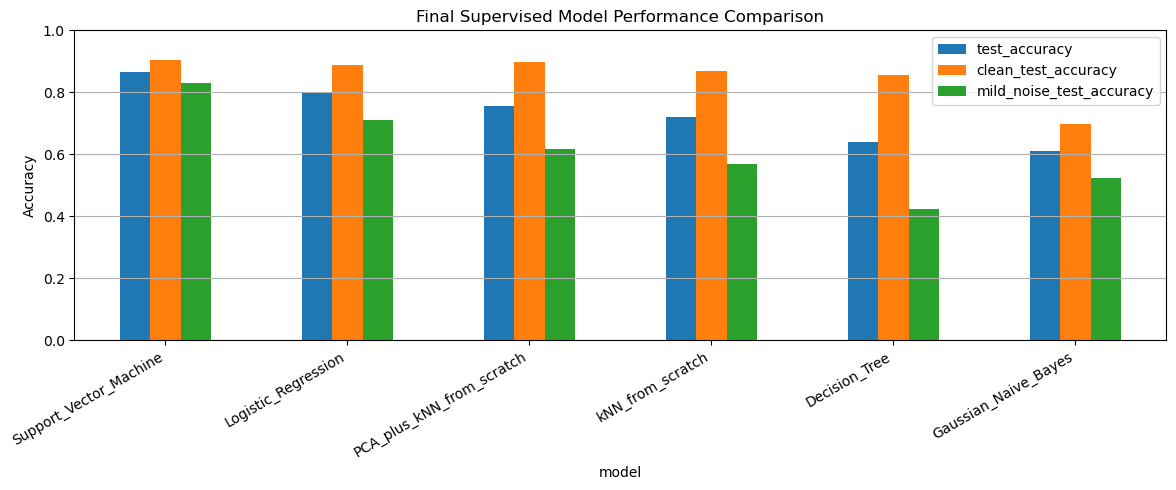

In [154]:
# step 10, part 12: final supervised model performance plot

comparison_metrics = [
    "test_accuracy",
    "clean_test_accuracy",
    "mild_noise_test_accuracy"
]

plot_df = supervised_results_extended.set_index("model")[comparison_metrics]

plot_df.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.ylabel("Accuracy")
plt.title("Final Supervised Model Performance Comparison")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.tight_layout()
plt.show()


The final supervised model performance plot compares held-out test accuracy, clean-test accuracy, and mild-noise test accuracy across all six classifiers.

The **Support Vector Machine** achieved the strongest performance across all three metrics. It obtained a held-out test accuracy of **0.8667**, a clean-test accuracy of **0.9033**, and a mild-noise accuracy of **0.8300**. This confirms that the SVM provided the best overall balance between generalisation and perturbation robustness.

**Logistic Regression** ranked second across the main accuracy measures, while PCA+kNN and raw-pixel kNN achieved moderate performance. The PCA-enhanced kNN model outperformed raw kNN, suggesting that dimensionality reduction improved the nearest-neighbour representation.

All models performed better on clean images than on mild-noise images, confirming that the perturbed condition was more challenging. However, the SVM maintained the highest mild-noise accuracy, indicating the strongest robustness among the evaluated classifiers.

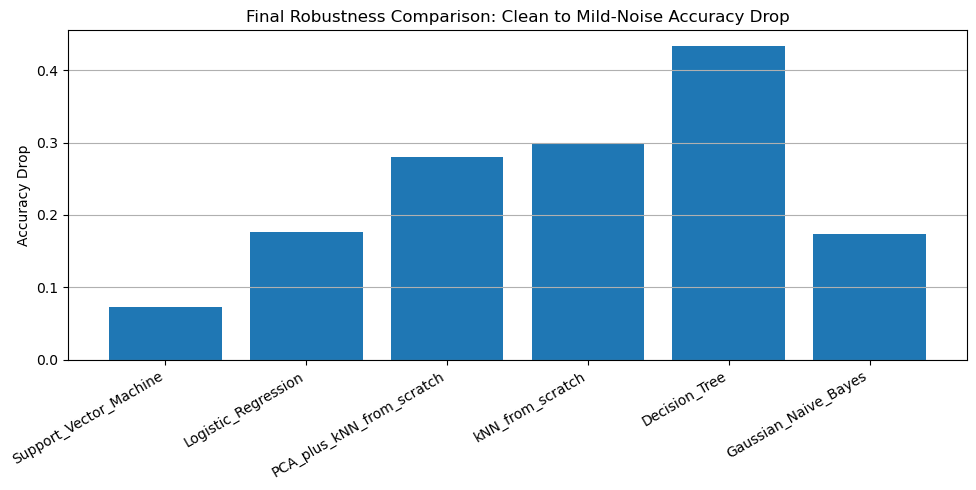

In [155]:
# step 10, part 13: final robustness comparison plot

plt.figure(figsize=(10, 5))

plt.bar(
    supervised_results_extended["model"],
    supervised_results_extended["accuracy_drop_clean_to_noise"]
)

plt.ylabel("Accuracy Drop")
plt.title("Final Robustness Comparison: Clean to Mild-Noise Accuracy Drop")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


The final robustness comparison plot shows the clean-to-mild-noise accuracy drop for each classifier. A smaller drop indicates stronger robustness under controlled perturbation, while a larger drop indicates greater sensitivity to mild image degradation.

The **Support Vector Machine** had the smallest accuracy drop of **0.0733**, making it the most stable model under the `mild_noise` condition. This shows that the SVM maintained strong predictive performance despite the introduction of mild noise, rotation, scaling, and translation.

In contrast, the **Decision Tree** had the largest accuracy drop of **0.4333**, indicating the weakest robustness. This suggests that its hierarchical pixel-thresholding rules were highly sensitive to small perturbation-induced changes in the image structure.

The kNN-based models also showed substantial degradation under mild perturbation. PCA+kNN produced a smaller drop of **0.2800** compared with **0.3000** for raw kNN, indicating that PCA improved robustness slightly.

Overall, the plot confirms that the SVM was both the strongest overall classifier and the most robust model in this experiment.

In [156]:
# step 10, part 14: rank models by test accuracy

ranked_by_test_accuracy = (
    supervised_results_extended
    .sort_values(by="test_accuracy", ascending=False)
    .reset_index(drop=True)
)

print("Models ranked by test accuracy:")
display(ranked_by_test_accuracy.round(4))


Models ranked by test accuracy:


,model,validation_accuracy,test_accuracy,clean_test_accuracy,mild_noise_test_accuracy,accuracy_drop_clean_to_noise,best_k,pca_components,max_depth,tree_depth,n_leaves,svm_C,svm_gamma
0,Support_Vector_Machine,0.8450,0.8667,0.9033,0.8300,0.0733,NaN,NaN,NaN,NaN,NaN,10.0,0.001
1,Logistic_Regression,0.7850,0.7983,0.8867,0.7100,0.1767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PCA_plus_kNN_from_scratch,0.7467,0.7567,0.8967,0.6167,0.2800,3.0,20.0,NaN,NaN,NaN,NaN,NaN
3,kNN_from_scratch,0.7300,0.7200,0.8700,0.5700,0.3000,1.0,NaN,NaN,NaN,NaN,NaN,NaN
4,Decision_Tree,0.6417,0.6400,0.8567,0.4233,0.4333,NaN,NaN,20.0,20.0,288.0,NaN,NaN
5,Gaussian_Naive_Bayes,0.5967,0.6100,0.6967,0.5233,0.1733,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The models were ranked by held-out test accuracy to compare generalisation performance on unseen test images.

The **Support Vector Machine** ranked first, achieving the highest test accuracy of **0.8667**. **Logistic Regression** ranked second with a test accuracy of **0.7983**, indicating that the dataset contained a meaningful degree of linear separability, although the SVM captured additional non-linear structure.

The **PCA-enhanced kNN** model ranked third with a test accuracy of **0.7567**, outperforming the raw-pixel kNN model, which achieved **0.7200**. This suggests that PCA improved the nearest-neighbour feature representation by reducing redundant or noise-sensitive variation.

The **Decision Tree** and **Gaussian Naive Bayes** classifiers ranked lower, with test accuracies of **0.6400** and **0.6100** respectively.

Overall, the ranking confirms that the RBF-kernel SVM achieved the strongest overall test-set performance among the evaluated classifiers.

In [157]:
# step 10, part 15: rank models by mild-noise test accuracy

ranked_by_noise_accuracy = (
    supervised_results_extended
    .sort_values(by="mild_noise_test_accuracy", ascending=False)
    .reset_index(drop=True)
)

print("Models ranked by mild-noise test accuracy:")
display(ranked_by_noise_accuracy.round(4))


Models ranked by mild-noise test accuracy:


,model,validation_accuracy,test_accuracy,clean_test_accuracy,mild_noise_test_accuracy,accuracy_drop_clean_to_noise,best_k,pca_components,max_depth,tree_depth,n_leaves,svm_C,svm_gamma
0,Support_Vector_Machine,0.8450,0.8667,0.9033,0.8300,0.0733,NaN,NaN,NaN,NaN,NaN,10.0,0.001
1,Logistic_Regression,0.7850,0.7983,0.8867,0.7100,0.1767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PCA_plus_kNN_from_scratch,0.7467,0.7567,0.8967,0.6167,0.2800,3.0,20.0,NaN,NaN,NaN,NaN,NaN
3,kNN_from_scratch,0.7300,0.7200,0.8700,0.5700,0.3000,1.0,NaN,NaN,NaN,NaN,NaN,NaN
4,Gaussian_Naive_Bayes,0.5967,0.6100,0.6967,0.5233,0.1733,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Decision_Tree,0.6417,0.6400,0.8567,0.4233,0.4333,NaN,NaN,20.0,20.0,288.0,NaN,NaN


The models were ranked by mild-noise test accuracy to compare robustness under controlled perturbation. This ranking is important because it evaluates how well each classifier maintains performance when the input images contain mild noise, rotation, scaling, and translation.

The **Support Vector Machine** ranked first, achieving the highest mild-noise accuracy of **0.8300**. **Logistic Regression** ranked second with a mild-noise accuracy of **0.7100**.

The **PCA-enhanced kNN** model achieved a mild-noise accuracy of **0.6167**, outperforming raw-pixel kNN, which achieved **0.5700**. This suggests that dimensionality reduction improved the stability of the nearest-neighbour representation under perturbed conditions.

**Gaussian Naive Bayes** and **Decision Tree** performed lower under the perturbed condition, achieving mild-noise accuracies of **0.5233** and **0.4233** respectively.

Overall, the ranking confirms that the SVM was the strongest classifier when the input images contained controlled perturbations.

In [159]:
# step 10, part 16: final SVM and supervised model comparison summary

best_overall_model = ranked_by_test_accuracy.iloc[0]["model"]
best_noise_model = ranked_by_noise_accuracy.iloc[0]["model"]

print("Support Vector Machine classifier comparison completed successfully.")
print(f"Best model by overall test accuracy: {best_overall_model}")
print(f"Best model by mild-noise robustness: {best_noise_model}")
print(f"SVM test accuracy:                  {test_accuracy_svm:.4f}")
print(f"SVM mild-noise test accuracy:       {noise_accuracy_svm:.4f}")


Support Vector Machine classifier comparison completed successfully.
Best model by overall test accuracy: Support_Vector_Machine
Best model by mild-noise robustness: Support_Vector_Machine
SVM test accuracy:                  0.8667
SVM mild-noise test accuracy:       0.8300


Step 10 completed the SVM evaluation and final supervised model comparison across all six classifiers.

The **Support Vector Machine** achieved the best overall held-out test accuracy of **0.8667** and the highest mild-noise test accuracy of **0.8300**. It also produced the smallest clean-to-noise accuracy drop of **0.0733**, confirming that it was both the strongest overall classifier and the most robust model under the `mild_noise` condition.

These results form the main basis for the final supervised learning evaluation and discussion. Overall, the SVM was selected as the final best-performing model because it provided the strongest balance between predictive accuracy, robustness, and generalisation stability.

**Step 11: Cross-Validation and Final Robustness Summary**

In [162]:
# step 11, part 1: cross-validation setup and safety checks

"""
Cross-Validation and Final Robustness Summary
---------------------------------------------

This section performs stratified 5-fold cross-validation and consolidates the
final supervised model comparison across all classifiers:

1. kNN from scratch
2. PCA + kNN from scratch
3. Decision Tree
4. Gaussian Naive Bayes
5. Logistic Regression
6. Support Vector Machine

Important implementation note:
The kNN classifier used in both the main experiment and cross-validation is
the manually implemented KNearestNeighbours class. sklearn.neighbors.
KNeighborsClassifier is not used for the kNN results reported as
"kNN_from_scratch".

For PCA + kNN, PCA is used only as a dimensionality reduction preprocessing
step. The final kNN classifier remains the manually implemented version.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


# =======================
# safety checks
# =======================

required_objects = [
    "KNearestNeighbours",
    "supervised_results_extended",
    "best_k",
    "best_n_components",
    "best_k_pca",
    "best_depth",
    "best_svm_C",
    "best_svm_gamma",
    "X",
    "y_encoded",
    "conditions",
]

missing_objects = [
    name for name in required_objects if name not in globals()
]

if missing_objects:
    raise NameError(
        f"Missing required objects before Step 11: {missing_objects}"
    )


# =======================
# cross-validation setup
# =======================

N_SPLITS = 5
RANDOM_STATE = 42

X_cv = np.asarray(X)
y_cv = np.asarray(y_encoded)
conditions_cv = np.asarray(conditions)

cv_stratify_labels = np.array([
    f"{label}_{condition}" for label, condition in zip(y_cv, conditions_cv)
])

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Cross-validation setup completed successfully.")
print(f"Number of folds: {N_SPLITS}")
print(f"Feature matrix shape: {X_cv.shape}")
print(f"Target vector shape:  {y_cv.shape}")


Cross-validation setup completed successfully.
Number of folds: 5
Feature matrix shape: (4000, 4096)
Target vector shape:  (4000,)


A stratified five-fold cross-validation setup was created to evaluate model stability across multiple data splits. The output confirms that the full dataset contains **4000 samples**, with each image represented by **4096 flattened pixel features**.

Stratification was performed using combined class-condition labels so that each fold preserved the distribution of all ten musical symbol classes under both `clean` and `mild_noise` conditions. This ensured that each fold remained balanced with respect to both class labels and perturbation conditions.

This setup supports a fairer estimate of model generalisation stability because each classifier is evaluated across multiple representative train-validation partitions rather than relying on a single split.

In [163]:
# step 11, part 2: cross-validation helper functions

def summarise_cv_scores(model_name, scores):
    """
    Summarise cross-validation accuracy scores.
    """
    scores = np.asarray(scores)

    return {
        "model": model_name,
        "cv_mean_accuracy": float(np.mean(scores)),
        "cv_std_accuracy": float(np.std(scores)),
        "cv_min_accuracy": float(np.min(scores)),
        "cv_max_accuracy": float(np.max(scores)),
    }


def cross_validate_knn_from_scratch(
    X,
    y,
    stratify_labels,
    k,
    skf,
    batch_size=100
):
    """
    Perform stratified cross-validation using the manually implemented
    KNearestNeighbours classifier.

    This avoids sklearn.neighbors.KNeighborsClassifier so that the
    cross-validation result remains consistent with the from-scratch
    implementation.
    """
    X = np.asarray(X)
    y = np.asarray(y)
    stratify_labels = np.asarray(stratify_labels)

    scores = []

    for train_index, val_index in skf.split(X, stratify_labels):
        X_fold_train = X[train_index]
        y_fold_train = y[train_index]
        X_fold_val = X[val_index]
        y_fold_val = y[val_index]

        knn_model = KNearestNeighbours(k=k)
        knn_model.fit(X_fold_train, y_fold_train)

        y_fold_pred = knn_model.predict(
            X_fold_val,
            batch_size=batch_size
        )

        fold_accuracy = np.mean(y_fold_pred == y_fold_val)
        scores.append(fold_accuracy)

    return np.array(scores)


def cross_validate_pca_knn_from_scratch(
    X,
    y,
    stratify_labels,
    n_components,
    k,
    skf,
    batch_size=100,
    random_state=42
):
    """
    Perform stratified cross-validation for PCA + manually implemented kNN.

    PCA is fitted only on each training fold and then applied to the validation
    fold. This avoids data leakage. The kNN classifier itself is still the
    manually implemented KNearestNeighbours class.
    """
    X = np.asarray(X)
    y = np.asarray(y)
    stratify_labels = np.asarray(stratify_labels)

    scores = []

    for train_index, val_index in skf.split(X, stratify_labels):
        X_fold_train = X[train_index]
        y_fold_train = y[train_index]
        X_fold_val = X[val_index]
        y_fold_val = y[val_index]

        pca = PCA(
            n_components=n_components,
            random_state=random_state
        )

        X_fold_train_pca = pca.fit_transform(X_fold_train)
        X_fold_val_pca = pca.transform(X_fold_val)

        knn_model = KNearestNeighbours(k=k)
        knn_model.fit(X_fold_train_pca, y_fold_train)

        y_fold_pred = knn_model.predict(
            X_fold_val_pca,
            batch_size=batch_size
        )

        fold_accuracy = np.mean(y_fold_pred == y_fold_val)
        scores.append(fold_accuracy)

    return np.array(scores)


print("Cross-validation helper functions defined successfully.")


Cross-validation helper functions defined successfully.


Custom helper functions were defined to ensure that cross-validation for the kNN models uses the manually implemented `KNearestNeighbours` classifier. For PCA+kNN, PCA is fitted separately within each training fold and then applied to the corresponding validation fold, avoiding data leakage during cross-validation.

In [164]:
# step 11, part 3: cross-validation for from-scratch kNN models

cv_results = []
cv_fold_scores = {}


# =======================
# 1. kNN on raw pixels
# =======================

knn_cv_scores = cross_validate_knn_from_scratch(
    X=X_cv,
    y=y_cv,
    stratify_labels=cv_stratify_labels,
    k=best_k,
    skf=skf,
    batch_size=100
)

cv_results.append(
    summarise_cv_scores("kNN_from_scratch", knn_cv_scores)
)

cv_fold_scores["kNN_from_scratch"] = knn_cv_scores


# =======================
# 2. PCA + kNN
# =======================

pca_knn_cv_scores = cross_validate_pca_knn_from_scratch(
    X=X_cv,
    y=y_cv,
    stratify_labels=cv_stratify_labels,
    n_components=best_n_components,
    k=best_k_pca,
    skf=skf,
    batch_size=100,
    random_state=RANDOM_STATE
)

cv_results.append(
    summarise_cv_scores("PCA_plus_kNN_from_scratch", pca_knn_cv_scores)
)

cv_fold_scores["PCA_plus_kNN_from_scratch"] = pca_knn_cv_scores


# =======================
# fold-level summary
# =======================

knn_fold_scores_df = pd.DataFrame(cv_fold_scores)
knn_fold_scores_df.index = [
    f"fold_{i}" for i in range(1, N_SPLITS + 1)
]

print("Fold-level cross-validation scores for from-scratch kNN models:")
display(knn_fold_scores_df.round(4))


Fold-level cross-validation scores for from-scratch kNN models:


,kNN_from_scratch,PCA_plus_kNN_from_scratch
fold_1,0.7512,0.7350
fold_2,0.7512,0.7725
fold_3,0.7488,0.7812
fold_4,0.7512,0.7662
fold_5,0.7475,0.7450


The fold-level cross-validation table reports the accuracy achieved by the manually implemented kNN models across five stratified folds. The raw `kNN_from_scratch` model produced highly stable fold accuracies ranging from **0.7475** to **0.7512**, indicating consistent behaviour across different data partitions.

The `PCA_plus_kNN_from_scratch` model achieved stronger performance in most folds, with fold accuracies ranging from **0.7350** to **0.7812**. Although its fold-to-fold variation was larger than raw kNN, its overall cross-validation performance was higher.

These results show that dimensionality reduction improved the nearest-neighbour feature representation in most folds. They also confirm that the kNN cross-validation evaluation was based on the manually implemented classifier rather than scikit-learn’s built-in kNN model.

In [165]:
# step 11, part 4: cross-validation for scikit-learn classifiers

sklearn_cv_models = {
    "Decision_Tree": DecisionTreeClassifier(
        max_depth=best_depth,
        criterion="gini",
        random_state=RANDOM_STATE
    ),

    "Gaussian_Naive_Bayes": GaussianNB(),

    "Logistic_Regression": LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Support_Vector_Machine": SVC(
        kernel="rbf",
        C=best_svm_C,
        gamma=best_svm_gamma,
        random_state=RANDOM_STATE
    ),
}


for model_name, model in sklearn_cv_models.items():
    scores = cross_val_score(
        model,
        X_cv,
        y_cv,
        cv=skf.split(X_cv, cv_stratify_labels),
        scoring="accuracy",
        n_jobs=-1
    )

    cv_results.append(
        summarise_cv_scores(model_name, scores)
    )

    cv_fold_scores[model_name] = scores


sklearn_fold_scores_df = pd.DataFrame({
    model_name: cv_fold_scores[model_name]
    for model_name in sklearn_cv_models
})

sklearn_fold_scores_df.index = [
    f"fold_{i}" for i in range(1, N_SPLITS + 1)
]

print("Fold-level cross-validation scores for scikit-learn classifiers:")
display(sklearn_fold_scores_df.round(4))


Fold-level cross-validation scores for scikit-learn classifiers:


,Decision_Tree,Gaussian_Naive_Bayes,Logistic_Regression,Support_Vector_Machine
fold_1,0.6262,0.6300,0.8212,0.8500
fold_2,0.6250,0.6012,0.8300,0.8788
fold_3,0.6125,0.6350,0.7912,0.8500
fold_4,0.6162,0.6238,0.8125,0.8600
fold_5,0.6300,0.5875,0.7800,0.8500


The scikit-learn classifiers were evaluated using the same stratified five-fold cross-validation setup. The **Support Vector Machine (SVM)** achieved the strongest fold-level performance, with accuracies ranging from **0.8500** to **0.8788**. This indicates that the SVM remained consistently strong across different train-validation partitions.

**Logistic Regression** ranked second, with fold accuracies ranging from **0.7800** to **0.8300**. This supports its role as a strong linear discriminative baseline, although its performance remained below the SVM.

The **Decision Tree** and **Gaussian Naive Bayes** classifiers produced lower fold-level accuracies. Decision Tree accuracy ranged from **0.6125** to **0.6300**, while Gaussian Naive Bayes ranged from **0.5875** to **0.6350**. These lower values suggest weaker generalisation compared with the SVM and Logistic Regression.

Overall, the fold-level cross-validation results are consistent with the final test-set comparison, where the SVM achieved the strongest supervised classification performance.

In [166]:
# step 11, part 5: cross-validation summary table

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="cv_mean_accuracy",
    ascending=False
).reset_index(drop=True)

print("Cross-validation summary:")
display(cv_results_df.round(4))


Cross-validation summary:


,model,cv_mean_accuracy,cv_std_accuracy,cv_min_accuracy,cv_max_accuracy
0,Support_Vector_Machine,0.8577,0.0112,0.8500,0.8788
1,Logistic_Regression,0.8070,0.0187,0.7800,0.8300
2,PCA_plus_kNN_from_scratch,0.7600,0.0173,0.7350,0.7812
3,kNN_from_scratch,0.7500,0.0016,0.7475,0.7512
4,Decision_Tree,0.6220,0.0065,0.6125,0.6300
5,Gaussian_Naive_Bayes,0.6155,0.0181,0.5875,0.6350


The cross-validation summary reports the mean, standard deviation, minimum, and maximum accuracy across five stratified folds for each classifier. This provides a more stable estimate of model generalisation than relying only on a single train-validation-test split.

The **Support Vector Machine (SVM)** achieved the strongest cross-validation performance, with the highest mean accuracy of **0.8577** and a low standard deviation of **0.0112**. Its fold accuracies ranged from **0.8500** to **0.8788**, indicating consistently strong performance across different data partitions.

**Logistic Regression** ranked second, with a mean cross-validation accuracy of **0.8070** and a standard deviation of **0.0187**. The **PCA-enhanced kNN** model achieved a mean accuracy of **0.7600**, outperforming the raw-pixel kNN model, which achieved **0.7500**. This supports the conclusion that PCA improved the nearest-neighbour feature representation.

The **Decision Tree** and **Gaussian Naive Bayes** classifiers achieved lower mean cross-validation accuracies of **0.6220** and **0.6155** respectively, suggesting weaker generalisation compared with the SVM, Logistic Regression, and kNN-based models.

Overall, the cross-validation results support the final test-set findings and confirm that the **Support Vector Machine** was the strongest supervised classifier in terms of generalisation stability.

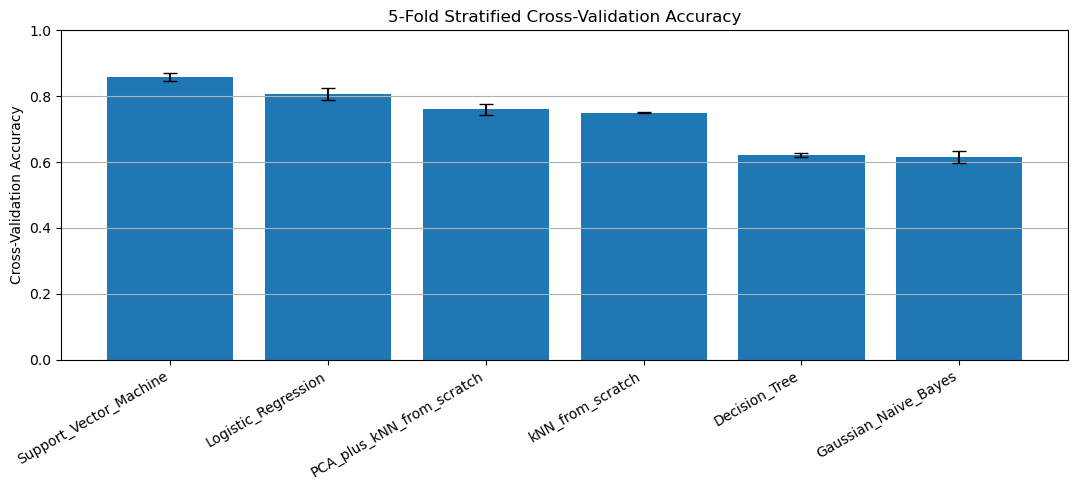

In [167]:
# step 11, part 6: cross-validation accuracy plot

plt.figure(figsize=(11, 5))

plt.bar(
    cv_results_df["model"],
    cv_results_df["cv_mean_accuracy"],
    yerr=cv_results_df["cv_std_accuracy"],
    capsize=5
)

plt.ylabel("Cross-Validation Accuracy")
plt.title("5-Fold Stratified Cross-Validation Accuracy")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.tight_layout()
plt.show()


The five-fold stratified cross-validation accuracy plot compares the mean cross-validation accuracy of each classifier, with error bars showing variation across folds. Higher mean accuracy indicates stronger generalisation performance, while smaller error bars indicate more consistent behaviour across different data partitions.

The **Support Vector Machine (SVM)** achieved the highest mean cross-validation accuracy of **0.8577** and showed low variation across folds, with a standard deviation of **0.0112**. This indicates that the SVM performed strongly and consistently across the five stratified folds.

**Logistic Regression** ranked second, with a mean cross-validation accuracy of **0.8070**. The **PCA-enhanced kNN** model achieved **0.7600**, slightly outperforming the raw-pixel kNN model, which achieved **0.7500**. This further supports the finding that dimensionality reduction improved the kNN feature representation.

The **Decision Tree** and **Gaussian Naive Bayes** classifiers achieved lower cross-validation mean accuracies of **0.6220** and **0.6155** respectively. These results indicate weaker generalisation performance compared with the SVM and Logistic Regression.

Overall, the plot supports the final test-set results and confirms that the **Support Vector Machine** was the strongest supervised classifier in terms of both accuracy and cross-validation stability.

In [168]:
# step 11, part 7: merge cross-validation with final supervised results

final_results = supervised_results_extended.copy()

final_results = final_results.merge(
    cv_results_df[
        [
            "model",
            "cv_mean_accuracy",
            "cv_std_accuracy",
            "cv_min_accuracy",
            "cv_max_accuracy",
        ]
    ],
    on="model",
    how="left"
)

final_results = final_results.sort_values(
    by="test_accuracy",
    ascending=False
).reset_index(drop=True)

missing_cv_models = final_results[
    final_results["cv_mean_accuracy"].isna()
]["model"].tolist()

assert len(missing_cv_models) == 0, (
    f"Missing cross-validation results for: {missing_cv_models}"
)

print("Final supervised model comparison with cross-validation results:")
display(final_results.round(4))


Final supervised model comparison with cross-validation results:


,model,validation_accuracy,test_accuracy,clean_test_accuracy,mild_noise_test_accuracy,accuracy_drop_clean_to_noise,best_k,pca_components,max_depth,tree_depth,n_leaves,svm_C,svm_gamma,cv_mean_accuracy,cv_std_accuracy,cv_min_accuracy,cv_max_accuracy
0,Support_Vector_Machine,0.8450,0.8667,0.9033,0.8300,0.0733,NaN,NaN,NaN,NaN,NaN,10.0,0.001,0.8577,0.0112,0.8500,0.8788
1,Logistic_Regression,0.7850,0.7983,0.8867,0.7100,0.1767,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8070,0.0187,0.7800,0.8300
2,PCA_plus_kNN_from_scratch,0.7467,0.7567,0.8967,0.6167,0.2800,3.0,20.0,NaN,NaN,NaN,NaN,NaN,0.7600,0.0173,0.7350,0.7812
3,kNN_from_scratch,0.7300,0.7200,0.8700,0.5700,0.3000,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0.7500,0.0016,0.7475,0.7512
4,Decision_Tree,0.6417,0.6400,0.8567,0.4233,0.4333,NaN,NaN,20.0,20.0,288.0,NaN,NaN,0.6220,0.0065,0.6125,0.6300
5,Gaussian_Naive_Bayes,0.5967,0.6100,0.6967,0.5233,0.1733,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.6155,0.0181,0.5875,0.6350


The cross-validation results were merged with the final supervised model comparison table to create a consolidated summary of all evaluated classifiers. The table includes validation accuracy, held-out test accuracy, clean-test accuracy, mild-noise accuracy, clean-to-noise robustness drop, selected hyperparameters, and cross-validation statistics.

The **Support Vector Machine (SVM)** achieved the strongest overall performance. It obtained the highest held-out test accuracy of **0.8667**, the highest mild-noise accuracy of **0.8300**, and the highest mean cross-validation accuracy of **0.8577**. Its cross-validation standard deviation was also low at **0.0112**, indicating stable performance across folds. The selected SVM configuration was **C = 10.0** and **gamma = 0.001**.

**Logistic Regression** ranked second overall, achieving a test accuracy of **0.7983** and a mean cross-validation accuracy of **0.8070**. This suggests that the symbolic image features possessed a meaningful degree of linear separability, although the SVM performed better due to its non-linear decision boundary.

The **PCA-enhanced kNN** model achieved a test accuracy of **0.7567** and a cross-validation mean accuracy of **0.7600**, outperforming the raw-pixel kNN model, which achieved a test accuracy of **0.7200** and a cross-validation mean accuracy of **0.7500**. The selected PCA+kNN configuration used **20 principal components** and **k = 3**, while the raw-pixel kNN model used **k = 1**.

The **Decision Tree** and **Gaussian Naive Bayes** models produced weaker overall results. The Decision Tree selected **max_depth = 20**, with an actual tree depth of **20** and **288 leaves**, but achieved only **0.6400** test accuracy and showed the largest robustness drop of **0.4333**. Gaussian Naive Bayes achieved the lowest test accuracy of **0.6100**, indicating that its simplified feature-independence assumption was less suitable for this image classification task.

Overall, the consolidated comparison confirms that the **Support Vector Machine** was the best-performing and most reliable supervised classifier in this experiment, providing the strongest balance between accuracy, robustness, and cross-validation stability.

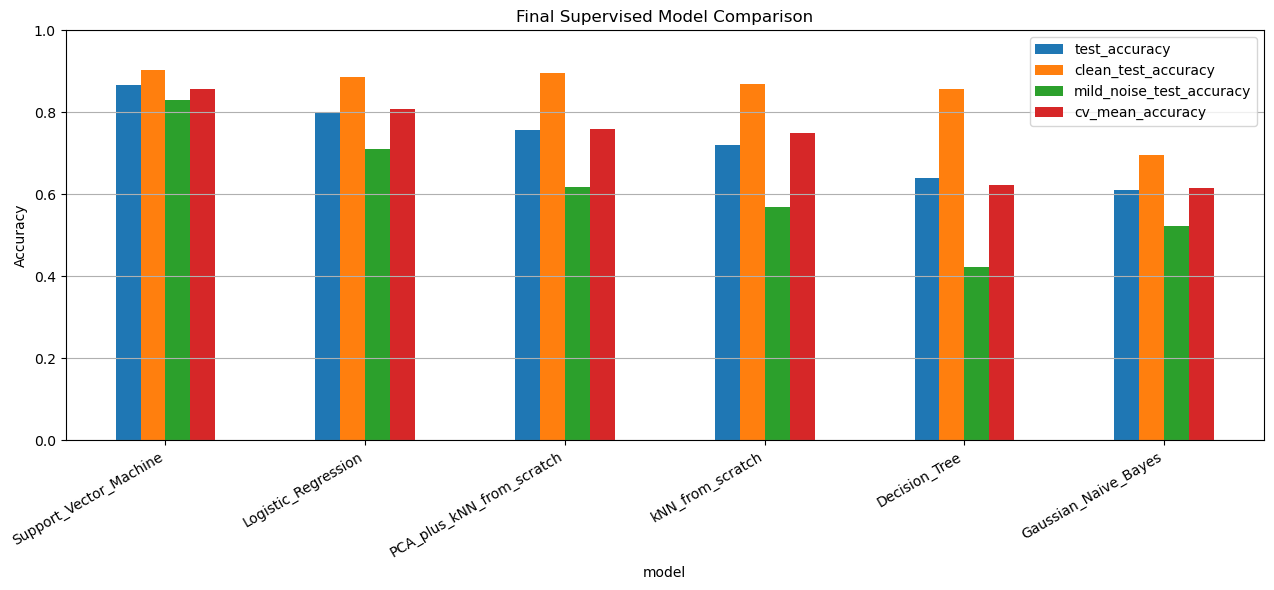

In [169]:
# step 11, part 8: final supervised model comparison plot

final_plot_metrics = [
    "test_accuracy",
    "clean_test_accuracy",
    "mild_noise_test_accuracy",
    "cv_mean_accuracy"
]

final_plot_df = final_results.set_index("model")[final_plot_metrics]

final_plot_df.plot(
    kind="bar",
    figsize=(13, 6)
)

plt.ylabel("Accuracy")
plt.title("Final Supervised Model Comparison")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.tight_layout()
plt.show()


The final supervised model comparison plot presents test accuracy, clean-test accuracy, mild-noise accuracy, and mean cross-validation accuracy for each classifier.

The **Support Vector Machine** performs best across the main evaluation metrics, showing the highest overall test accuracy, mild-noise accuracy, and cross-validation mean accuracy. Logistic Regression ranks second, while PCA+kNN and raw kNN show moderate performance. Decision Tree and Gaussian Naive Bayes perform lower overall.

Overall, the plot confirms that SVM is the strongest, most robust, and most consistent classifier in this experiment.

In [170]:
# step 11, part 9: robustness summary table

robustness_summary = final_results[
    [
        "model",
        "clean_test_accuracy",
        "mild_noise_test_accuracy",
        "accuracy_drop_clean_to_noise",
    ]
].copy()

robustness_summary = robustness_summary.sort_values(
    by="mild_noise_test_accuracy",
    ascending=False
).reset_index(drop=True)

print("Robustness summary ranked by mild-noise accuracy:")
display(robustness_summary.round(4))


Robustness summary ranked by mild-noise accuracy:


,model,clean_test_accuracy,mild_noise_test_accuracy,accuracy_drop_clean_to_noise
0,Support_Vector_Machine,0.9033,0.8300,0.0733
1,Logistic_Regression,0.8867,0.7100,0.1767
2,PCA_plus_kNN_from_scratch,0.8967,0.6167,0.2800
3,kNN_from_scratch,0.8700,0.5700,0.3000
4,Gaussian_Naive_Bayes,0.6967,0.5233,0.1733
5,Decision_Tree,0.8567,0.4233,0.4333


The robustness summary ranks the classifiers according to their performance on the `mild_noise` test subset. This evaluation is important because it shows how well each model maintains predictive accuracy when controlled perturbations such as mild noise, rotation, scaling, and translation are introduced.

The **Support Vector Machine (SVM)** performed best, achieving the highest mild-noise accuracy of **0.8300** and the smallest clean-to-noise accuracy drop of **0.0733**. This indicates that the SVM was not only the most accurate model overall, but also the most stable under controlled image perturbations.

**Logistic Regression** ranked second, with a mild-noise accuracy of **0.7100** and an accuracy drop of **0.1767**. The **PCA-enhanced kNN** model achieved better robustness than raw-pixel kNN, with a mild-noise accuracy of **0.6167** compared with **0.5700** for raw kNN. This suggests that dimensionality reduction improved the stability of the nearest-neighbour feature representation.

**Gaussian Naive Bayes** achieved a relatively small accuracy drop of **0.1733**, but its absolute mild-noise accuracy remained low at **0.5233**. This shows that robustness drop should be interpreted together with overall predictive performance. The **Decision Tree** performed weakest under the perturbed condition, achieving the lowest mild-noise accuracy of **0.4233** and the largest accuracy drop of **0.4333**.

Overall, the robustness results confirm that the **Support Vector Machine** was the most reliable classifier under controlled image distortions.

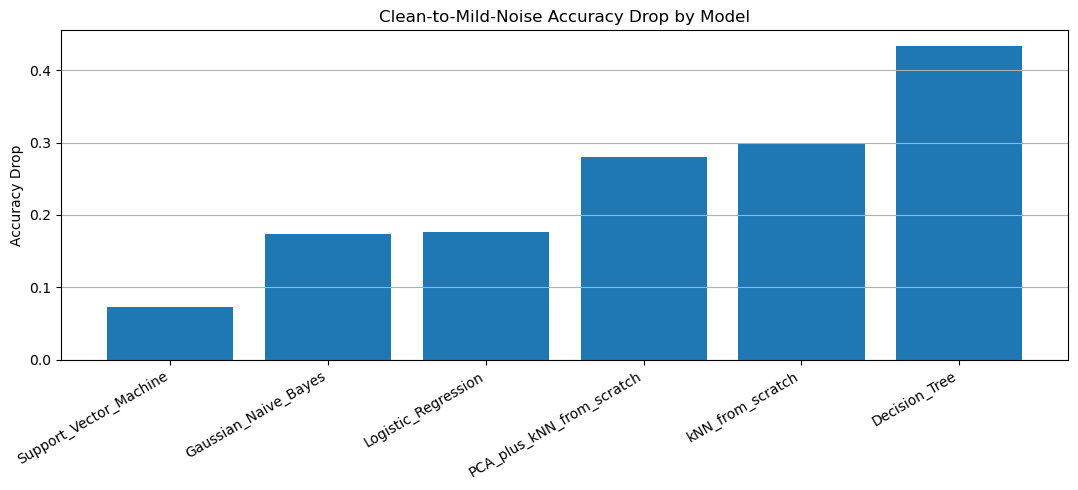

In [171]:
# step 11, part 10: robustness drop plot

robustness_drop_df = final_results.sort_values(
    by="accuracy_drop_clean_to_noise",
    ascending=True
)

plt.figure(figsize=(11, 5))

plt.bar(
    robustness_drop_df["model"],
    robustness_drop_df["accuracy_drop_clean_to_noise"]
)

plt.ylabel("Accuracy Drop")
plt.title("Clean-to-Mild-Noise Accuracy Drop by Model")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


The clean-to-mild-noise accuracy drop plot shows how much each model’s accuracy decreased when evaluated on the `mild_noise` condition. A smaller drop indicates stronger robustness, while a larger drop indicates greater sensitivity to controlled perturbations.

The **Support Vector Machine (SVM)** had the smallest accuracy drop of **0.0733**, making it the most stable classifier under perturbation. This shows that the SVM maintained strong performance even when the test images contained mild geometric and noise-based variation.

**Logistic Regression** and **Gaussian Naive Bayes** showed smaller drops than the kNN-based models and Decision Tree, with accuracy drops of **0.1767** and **0.1733** respectively. However, Gaussian Naive Bayes still had a relatively low absolute mild-noise accuracy of **0.5233**, so its smaller drop should not be interpreted as stronger overall performance than Logistic Regression or SVM.

The **PCA-enhanced kNN** model had an accuracy drop of **0.2800**, while the raw-pixel kNN model had a larger drop of **0.3000**. This suggests that PCA improved robustness slightly by reducing noise-sensitive variation in the original high-dimensional pixel space.

The **Decision Tree** had the largest drop of **0.4333**, indicating the weakest robustness under mild perturbation. This suggests that its hierarchical threshold-based decision rules were highly sensitive to small changes in pixel structure.

Overall, the plot confirms that the **Support Vector Machine** was the most robust model under controlled image degradation.

In [172]:
# step 11, part 11: final model conclusions

best_test_model = (
    final_results
    .sort_values(by="test_accuracy", ascending=False)
    .iloc[0]["model"]
)

best_cv_model = (
    final_results
    .sort_values(by="cv_mean_accuracy", ascending=False)
    .iloc[0]["model"]
)

best_noise_model = (
    final_results
    .sort_values(by="mild_noise_test_accuracy", ascending=False)
    .iloc[0]["model"]
)

most_stable_model = (
    final_results
    .sort_values(by="accuracy_drop_clean_to_noise", ascending=True)
    .iloc[0]["model"]
)

final_model_conclusions = pd.DataFrame([{
    "best_model_by_test_accuracy": best_test_model,
    "best_model_by_cv_mean": best_cv_model,
    "best_model_by_mild_noise_accuracy": best_noise_model,
    "most_stable_clean_to_noise_model": most_stable_model,
}])

print("Final model conclusions:")
display(final_model_conclusions)


Final model conclusions:


,best_model_by_test_accuracy,best_model_by_cv_mean,best_model_by_mild_noise_accuracy,most_stable_clean_to_noise_model
0,Support_Vector_Machine,Support_Vector_Machine,Support_Vector_Machine,Support_Vector_Machine


The final model conclusions show that the **Support Vector Machine** was the best-performing classifier across all key evaluation criteria.

It achieved the highest overall test accuracy, highest mean cross-validation accuracy, highest mild-noise accuracy, and the strongest clean-to-noise stability. Therefore, SVM is selected as the final best supervised model for this experiment.

In [174]:
# step 11, part 12: final summary table

summary_columns = [
    "model",
    "validation_accuracy",
    "test_accuracy",
    "clean_test_accuracy",
    "mild_noise_test_accuracy",
    "accuracy_drop_clean_to_noise",
    "cv_mean_accuracy",
    "cv_std_accuracy"
]

final_summary_table = final_results[summary_columns].copy()

print("Final summary table:")
display(final_summary_table.round(4))

print("\nCross-validation and final robustness summary completed successfully.")


Final summary table:


,model,validation_accuracy,test_accuracy,clean_test_accuracy,mild_noise_test_accuracy,accuracy_drop_clean_to_noise,cv_mean_accuracy,cv_std_accuracy
0,Support_Vector_Machine,0.8450,0.8667,0.9033,0.8300,0.0733,0.8577,0.0112
1,Logistic_Regression,0.7850,0.7983,0.8867,0.7100,0.1767,0.8070,0.0187
2,PCA_plus_kNN_from_scratch,0.7467,0.7567,0.8967,0.6167,0.2800,0.7600,0.0173
3,kNN_from_scratch,0.7300,0.7200,0.8700,0.5700,0.3000,0.7500,0.0016
4,Decision_Tree,0.6417,0.6400,0.8567,0.4233,0.4333,0.6220,0.0065
5,Gaussian_Naive_Bayes,0.5967,0.6100,0.6967,0.5233,0.1733,0.6155,0.0181



Cross-validation and final robustness summary completed successfully.


The final summary table consolidates the main evaluation metrics for all supervised classifiers, including validation accuracy, held-out test accuracy, clean-test accuracy, mild-noise accuracy, clean-to-noise accuracy drop, and five-fold cross-validation stability.

The **Support Vector Machine (SVM)** achieved the strongest overall performance. It obtained the highest held-out test accuracy of **0.8667**, the highest mild-noise accuracy of **0.8300**, and the strongest mean cross-validation accuracy of **0.8577**. It also produced the smallest clean-to-noise accuracy drop of **0.0733**, indicating that it was the most accurate and robust classifier under the controlled perturbation setting.

**Logistic Regression** ranked second overall, achieving a test accuracy of **0.7983** and a cross-validation mean accuracy of **0.8070**. The **PCA-enhanced kNN** model outperformed the raw-pixel kNN model, with a higher test accuracy of **0.7567** compared with **0.7200**, suggesting that dimensionality reduction improved the nearest-neighbour feature representation.

The **Decision Tree** and **Gaussian Naive Bayes** classifiers produced weaker overall results. In particular, the Decision Tree showed the largest clean-to-noise accuracy drop of **0.4333**, indicating strong sensitivity to mild perturbations. Gaussian Naive Bayes achieved the lowest overall test accuracy of **0.6100**, although its robustness drop was smaller than that of the kNN models and Decision Tree.

Overall, this table provides a compact final comparison of predictive accuracy, robustness, and cross-validation stability. The results support the selection of the **Support Vector Machine** as the final best-performing model for this music-symbol image classification task.

## 5. Results

**5.1 Experimental Overview**

This study evaluated the effectiveness of multiple classical supervised machine learning algorithms for classifying musical notation symbols under both clean and mildly perturbed imaging conditions. Experiments were conducted using a synthetically generated balanced dataset containing ten musical symbol categories represented under two experimental conditions: `clean` and `mild_noise`.

The evaluated classifiers included:

* raw-pixel k-Nearest Neighbours classifier implemented manually using NumPy
* PCA-enhanced kNN framework using dimensionality reduction followed by the manually implemented kNN classifier
* Decision Tree classifier
* Gaussian Naive Bayes classifier
* Logistic Regression classifier
* Support Vector Machine classifier using a Radial Basis Function kernel.

Performance was evaluated using validation accuracy, held-out test accuracy, stratified five-fold cross-validation accuracy, robustness under mild perturbation, confusion matrix analysis, and class-wise precision, recall, and F1-score metrics.

The experimental design was intended not only to measure predictive accuracy, but also to evaluate robustness and generalisation behaviour under controlled distributional perturbation.

**5.2 Decision Tree Hyperparameter Optimisation**

A hyperparameter search was conducted for the Decision Tree classifier using varying maximum tree depths. This was done to investigate the trade-off between representational capacity and overfitting behaviour.

**Table 2: Decision Tree validation performance across maximum tree depths**

| Maximum Tree Depth | Validation Accuracy | Actual Tree Depth | Number of Leaves |
|---:|---:|---:|---:|
| 3 | 0.2600 | 3 | 8 |
| 5 | 0.3467 | 5 | 20 |
| 8 | 0.4867 | 8 | 50 |
| 10 | 0.5117 | 10 | 91 |
| 15 | 0.5867 | 15 | 171 |
| 20 | 0.6417 | 20 | 288 |
| None | 0.6183 | 34 | 442 |

The results show a clear relationship between tree depth and validation accuracy. Shallow trees produced low validation accuracy, indicating underfitting. As the maximum depth increased, validation accuracy improved because the model was able to learn more detailed partitions of the high-dimensional pixel feature space.

The strongest validation accuracy was obtained using max_depth = 20, which achieved a validation accuracy of **0.6417** with an actual tree depth of **20** and **288** leaf nodes. Although the unrestricted tree was more complex, with a greater depth and more leaf nodes, it did not achieve the best validation performance. This suggests that moderate depth control improved generalisation compared with allowing the tree to grow without restriction.

However, the large tree depth and high number of leaves also suggest that the Decision Tree may be highly sensitive to local pixel-level variation. This behaviour is reflected later in the robustness analysis, where the Decision Tree shows a substantial performance drop under the `mild_noise` condition.

**5.3 Support Vector Machine Hyperparameter Optimisation**

A small hyperparameter search was performed for the Support Vector Machine classifier using different values of the regularisation parameter C and kernel coefficient gamma.

**Table 3: SVM validation performance across hyperparameter configurations**

| C | Gamma | Validation Accuracy |
|---:|---|---:|
| 0.1 | scale | 0.6167 |
| 1.0 | scale | 0.8300 |
| 10.0 | scale | 0.8400 |
| 1.0 | 0.001 | 0.7700 |
| 10.0 | 0.001 | 0.8450 |

The results show that SVM performance was sensitive to hyperparameter selection. The weakest performance was observed when C = 0.1 and gamma = scale, producing a validation accuracy of **0.6167**. This suggests that the regularisation constraint was too strong and limited the model’s ability to separate the high-dimensional symbol representations.

Increasing C improved validation performance substantially. The configuration using C = 1.0 and gamma = scale achieved a validation accuracy of **0.8300**, while increasing C to 10.0 with gamma = scale further improved validation accuracy to **0.8400**.

The strongest validation performance was achieved using C = 10.0 and gamma = 0.001, which produced a validation accuracy of **0.8450**. This configuration was therefore selected for final SVM evaluation.

**5.4 Comparative Supervised Learning Performance**

Table 4 summarises the final supervised learning performance across all evaluated models.

**Table 4: Final supervised model comparison**

| Model | Validation Accuracy | Test Accuracy | Clean Test Accuracy | Mild-Noise Accuracy | Cross-Validation Mean Accuracy |
|---|---:|---:|---:|---:|---:|
| Support Vector Machine | 0.8450 | 0.8667 | 0.9033 | 0.8300 | 0.8577 |
| Logistic Regression | 0.7850 | 0.7983 | 0.8867 | 0.7100 | 0.8070 |
| PCA + kNN | 0.7467 | 0.7567 | 0.8967 | 0.6167 | 0.7600 |
| Raw-pixel kNN | 0.7300 | 0.7200 | 0.8700 | 0.5700 | 0.7500 |
| Decision Tree | 0.6417 | 0.6400 | 0.8567 | 0.4233 | 0.6220 |
| Gaussian Naive Bayes | 0.5967 | 0.6100 | 0.6967 | 0.5233 | 0.6155 |

Among all evaluated methods, the Support Vector Machine achieved the strongest overall performance. It produced the highest held-out test accuracy of **0.8667**, the highest mild-noise test accuracy of **0.8300**, and the strongest cross-validation mean accuracy of **0.8577**.

These findings suggest that non-linear margin-based classification was highly effective for separating the structural patterns present in the symbolic image representations. The strong performance of the SVM likely arises from its ability to construct flexible non-linear decision boundaries in a transformed feature space.

Logistic Regression achieved the second-highest overall performance, with a test accuracy of **0.7983** and a cross-validation mean accuracy of **0.8070**. This indicates that the generated feature representations possessed a meaningful degree of linear separability despite the high-dimensional pixel representation.

The PCA-enhanced kNN model outperformed the raw-pixel kNN implementation. PCA+kNN achieved a test accuracy of **0.7567**, compared with **0.7200** for raw-pixel kNN. This suggests that dimensionality reduction improved the usefulness of the nearest-neighbour feature space by suppressing some redundant or noisy variation.

Decision Tree classification achieved weaker overall performance, with a test accuracy of **0.6400**. Although it performed relatively well on clean images, its performance declined strongly under the mild-noise condition. This indicates sensitivity to perturbation-induced changes in pixel-level structure.

Gaussian Naive Bayes produced the lowest overall performance among the evaluated classifiers, with a test accuracy of **0.6100**. This result is consistent with the limitations of the model’s conditional independence assumption, which is not well suited to image data where neighbouring pixel features are spatially related. Nevertheless, it provided a useful probabilistic baseline for comparison.

**5.5 Robustness Analysis Under Mild Perturbation**

To evaluate robustness, clean-image accuracy was compared against mild-noise test accuracy. The accuracy drop was calculated as the difference between clean test accuracy and mild-noise test accuracy.

**Table 5: Robustness comparison under mild perturbation**

| Model | Clean Test Accuracy | Mild-Noise Accuracy | Accuracy Drop |
|---|---:|---:|---:|
| Support Vector Machine | 0.9033 | 0.8300 | 0.0733 |
| Logistic Regression | 0.8867 | 0.7100 | 0.1767 |
| PCA + kNN | 0.8967 | 0.6167 | 0.2800 |
| Raw-pixel kNN | 0.8700 | 0.5700 | 0.3000 |
| Gaussian Naive Bayes | 0.6967 | 0.5233 | 0.1733 |
| Decision Tree | 0.8567 | 0.4233 | 0.4333 |

The robustness analysis revealed clear differences between classifiers in terms of perturbation sensitivity.

The Support Vector Machine demonstrated the strongest robustness, with only a **0.0733** reduction in accuracy between clean and mildly perturbed conditions. This was the smallest accuracy drop among all evaluated classifiers. The SVM also achieved the highest absolute mild-noise accuracy of **0.8300**, confirming that it remained effective under controlled perturbation.

Logistic Regression also demonstrated relatively strong robustness, with an accuracy drop of **0.1767** and a mild-noise accuracy of **0.7100**. Although its robustness was lower than that of the SVM, it remained stronger than the kNN-based models and Decision Tree under the perturbed condition.

PCA+kNN achieved better robustness than raw-pixel kNN. Its mild-noise accuracy of **0.6167** exceeded the raw-pixel kNN score of **0.5700**, and its accuracy drop was also smaller. This suggests that dimensionality reduction improved feature stability under mild corruption.

Gaussian Naive Bayes produced a relatively small accuracy drop of **0.1733**, but its absolute mild-noise accuracy remained low at **0.5233**. This shows that robustness drop should be interpreted together with absolute predictive performance.

The Decision Tree classifier experienced the largest degradation, with an accuracy drop of **0.4333**. This indicates strong sensitivity to perturbation-induced feature instability and suggests that hierarchical threshold-based decision rules were less robust for this image classification task.

Overall, the robustness analysis confirms that the SVM was the most reliable classifier under mild noise, rotation, scaling, and translation.

**5.6 Cross-Validation Performance**

Five-fold stratified cross-validation was conducted to evaluate model generalisation consistency across multiple train-validation partitions while preserving both class and perturbation-condition distributions.

**Table 5. Stratified cross-validation results**

| Model | Mean Accuracy | Standard Deviation |
|---|---:|---:|
| Support Vector Machine | 0.8577 | 0.0112 |
| Logistic Regression | 0.8070 | 0.0187 |
| PCA + kNN | 0.7600 | 0.0173 |
| Raw-pixel kNN | 0.7500 | 0.0016 |
| Decision Tree | 0.6220 | 0.0065 |
| Gaussian Naive Bayes | 0.6155 | 0.0181 |

The Support Vector Machine achieved the strongest cross-validation performance, with the highest mean accuracy of **0.8577** and a low standard deviation of **0.0112**. This indicates that the SVM performed strongly and consistently across different train-validation splits.

Logistic Regression achieved the second-highest cross-validation mean accuracy of **0.8070**, reinforcing its effectiveness as a strong linear discriminative baseline for this dataset.

The PCA-enhanced kNN model achieved a higher cross-validation mean accuracy than raw-pixel kNN, supporting the conclusion that dimensionality reduction improved the nearest-neighbour feature representation. Raw-pixel kNN had the lowest standard deviation, indicating consistent behaviour across folds, but its mean accuracy remained below PCA+kNN.

Decision Tree and Gaussian Naive Bayes achieved lower cross-validation performance, suggesting weaker generalisation across folds. Gaussian Naive Bayes showed the highest standard deviation among the evaluated models, indicating greater fold-to-fold variation.

Overall, the cross-validation results support the final test-set findings and confirm that the SVM classifier provided the strongest balance between predictive accuracy and generalisation stability.

**5.7 Class-wise Classification Behaviour**

Class-level evaluation revealed variation in classification difficulty across the ten musical symbol categories.

Symbols such as `bass_clef`, `half_note`, `natural`, `quarter_rest`, `whole_note`, and `whole_rest` generally achieved stronger classification performance across the higher-performing models, particularly SVM and Logistic Regression. These symbols contain distinctive visual structures that are easier for the classifiers to separate within the pixel feature space.

In contrast, `quarter_note` and `treble_clef` remained among the more challenging classes. Confusion matrix analysis showed persistent confusion between these two categories, especially because both contain curved or visually complex structures that may partially overlap after resizing and perturbation. Smaller confusion was also observed between visually related symbols such as flat and sharp.

The Support Vector Machine demonstrated the strongest class-wise consistency overall, producing comparatively strong precision, recall, and F1-score values across most classes. Logistic Regression also showed strong performance, indicating that several symbol categories were separable using linear decision boundaries.

**Table 7: SVM classification report on the test set**

| Class / Average | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| bass_clef | 1.0000 | 1.0000 | 1.0000 | 60 |
| flat | 0.8710 | 0.9000 | 0.8852 | 60 |
| half_note | 0.9516 | 0.9833 | 0.9672 | 60 |
| natural | 0.9365 | 0.9833 | 0.9593 | 60 |
| quarter_note | 0.5286 | 0.6167 | 0.5692 | 60 |
| quarter_rest | 0.9483 | 0.9167 | 0.9322 | 60 |
| sharp | 0.9259 | 0.8333 | 0.8772 | 60 |
| treble_clef | 0.5385 | 0.4667 | 0.5000 | 60 |
| whole_note | 0.9836 | 1.0000 | 0.9917 | 60 |
| whole_rest | 1.0000 | 0.9667 | 0.9831 | 60 |
| accuracy | 0.8667 | 0.8667 | 0.8667 | 600 |
| macro avg | 0.8684 | 0.8667 | 0.8665 | 600 |
| weighted avg | 0.8684 | 0.8667 | 0.8665 | 600 |

The Decision Tree classifier showed less stable class-wise behaviour, particularly under the `mild_noise` condition. This suggests that hierarchical pixel-thresholding struggled to preserve robust decision boundaries when small geometric and intensity perturbations were introduced.

Overall, the class-wise evaluation reinforces the final model comparison: the SVM provided the strongest and most balanced classification performance across the ten symbolic music notation categories.


**Step 12: Single-Image Prediction and Model Demonstration**

This section demonstrates single-image prediction using a selected trained classifier. The image is processed using the same 64×64 grayscale feature format as the training data, and the predicted numerical label is decoded back into the corresponding musical symbol class.

In [191]:
# step 12, part 1: single-image prediction setup

"""
Single-Image Prediction and Model Demonstration
-----------------------------------------------

This section demonstrates how a trained classifier can be used to predict the
class of an individual 64x64 music-symbol image.

The prediction pipeline applies the same image loading, grayscale conversion,
normalisation, and flattening format used during model training. The selected
trained model is then used to return the predicted musical symbol class.
"""

import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt


# =======================
# safety checks
# =======================

required_prediction_objects = [
    "label_encoder",
    "class_names",
    "file_test",
    "y_test",
]

missing_prediction_objects = [
    name for name in required_prediction_objects if name not in globals()
]

if missing_prediction_objects:
    raise NameError(
        f"Missing required objects before Step 12: {missing_prediction_objects}"
    )

print("Single-image prediction setup completed successfully.")


Single-image prediction setup completed successfully.


The single-image prediction stage demonstrates how the trained model can be applied to an individual music-symbol image. This provides a practical test of the preprocessing and prediction pipeline beyond the aggregate evaluation metrics.

In [192]:
# step 12, part 2: image preprocessing function

def preprocess_input_image(image_path, image_size=(64, 64)):
    """
    Load one image and convert it into the same feature format used during training.

    Parameters
    ----------
    image_path : str or pathlib.Path
        Path to the input image.

    image_size : tuple
        Target image size. The training pipeline uses 64x64 grayscale images.

    Returns
    -------
    img : PIL.Image.Image
        The processed grayscale image.

    img_vector : numpy.ndarray
        Flattened and normalised image vector with shape (1, 4096).
    """
    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    img = Image.open(image_path).convert("L")
    img = img.resize(image_size)

    img_array = np.asarray(img, dtype=np.float32) / 255.0
    img_vector = img_array.flatten().reshape(1, -1)

    return img, img_vector


print("Image preprocessing function defined successfully.")


Image preprocessing function defined successfully.


The preprocessing function converts a single image into the same numerical format used during training. The image is converted to grayscale, resized to 64×64 pixels, normalised to the range `[0, 1]`, and flattened into a 4096-dimensional feature vector.

In [193]:
# step 12, part 3: single-image prediction function

def predict_music_symbol(image_path, model_name="Support_Vector_Machine"):
    """
    Predict the musical symbol class of a single image using a selected model.

    Supported model_name values:
    - "Support_Vector_Machine"
    - "PCA_plus_kNN_from_scratch"
    - "kNN_from_scratch"
    - "Logistic_Regression"
    - "Decision_Tree"
    - "Gaussian_Naive_Bayes"
    """
    img, img_vector = preprocess_input_image(image_path)

    if model_name == "Support_Vector_Machine":
        if "svm_final" not in globals():
            raise NameError("svm_final is not defined. Please run Step 10 first.")
        pred_encoded = svm_final.predict(img_vector)[0]

    elif model_name == "PCA_plus_kNN_from_scratch":
        if "pca_final" not in globals() or "knn_pca_final" not in globals():
            raise NameError(
                "pca_final or knn_pca_final is not defined. Please run Step 6 first."
            )
        img_pca = pca_final.transform(img_vector)
        pred_encoded = knn_pca_final.predict(img_pca, batch_size=1)[0]

    elif model_name == "kNN_from_scratch":
        if "knn_final" not in globals():
            raise NameError("knn_final is not defined. Please run Step 5 first.")
        pred_encoded = knn_final.predict(img_vector, batch_size=1)[0]

    elif model_name == "Logistic_Regression":
        if "logreg_final" not in globals():
            raise NameError("logreg_final is not defined. Please run Step 9 first.")
        pred_encoded = logreg_final.predict(img_vector)[0]

    elif model_name == "Decision_Tree":
        if "dt_final" not in globals():
            raise NameError("dt_final is not defined. Please run Step 7 first.")
        pred_encoded = dt_final.predict(img_vector)[0]

    elif model_name == "Gaussian_Naive_Bayes":
        if "gnb_final" not in globals():
            raise NameError("gnb_final is not defined. Please run Step 8 first.")
        pred_encoded = gnb_final.predict(img_vector)[0]

    else:
        raise ValueError(f"Unsupported model_name: {model_name}")

    pred_class = label_encoder.inverse_transform([pred_encoded])[0]

    return {
        "image": img,
        "image_path": str(image_path),
        "model": model_name,
        "predicted_label_encoded": int(pred_encoded),
        "predicted_class": pred_class,
    }


print("Single-image prediction function defined successfully.")


Single-image prediction function defined successfully.


The prediction function applies the selected trained classifier to a single preprocessed image. The predicted numerical label is decoded back into the original musical symbol class name using the fitted label encoder.

In [194]:
# step 12, part 4: test prediction on one held-out image

sample_index = 0
sample_image_path = file_test[sample_index]
actual_class = label_encoder.inverse_transform([y_test[sample_index]])[0]

# Use the final best model from Step 11 if available.
# Otherwise, use SVM as the default final classifier.
if "final_results" in globals():
    selected_model = (
        final_results
        .sort_values(by="test_accuracy", ascending=False)
        .iloc[0]["model"]
    )
else:
    selected_model = "Support_Vector_Machine"

prediction_result = predict_music_symbol(
    sample_image_path,
    model_name=selected_model
)

single_prediction_summary = pd.DataFrame([{
    "model": prediction_result["model"],
    "image_path": prediction_result["image_path"],
    "predicted_class": prediction_result["predicted_class"],
    "actual_class": actual_class,
    "correct_prediction": prediction_result["predicted_class"] == actual_class,
}])

print("Single-image prediction summary:")
display(single_prediction_summary)


Single-image prediction summary:


,model,image_path,predicted_class,actual_class,correct_prediction
0,Support_Vector_Machine,music_symbols_dataset\mild_noise\half_note\hal...,half_note,half_note,True


A held-out test image was selected to demonstrate the single-image prediction pipeline. The predicted class is compared with the actual label from the test set to verify whether the selected model classified the image correctly.

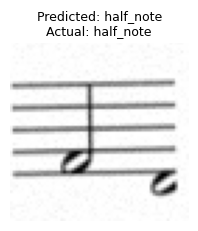

In [195]:
# step 12, part 5: display predicted image

plt.figure(figsize=(2.2, 2.2), dpi=100)
plt.imshow(prediction_result["image"], cmap="gray")
plt.axis("off")
plt.title(
    f"Predicted: {prediction_result['predicted_class']}\n"
    f"Actual: {actual_class}",
    fontsize=9,
    pad=6
)

plt.tight_layout(pad=0.3)
plt.show()


The image display provides a visual confirmation of the tested input sample alongside the model’s predicted class and the actual class label. This makes the prediction result easier to interpret than a text output alone.

**Step 13: Generation of New Unseen Test Images for Inference**

This section generated a small set of new unseen musical notation images that were not included in the original training, validation, or test partitions. These images were created for inference demonstration and qualitative generalisation testing.

The generated images follow the same LilyPond rendering and 64×64 grayscale standardisation procedure used during dataset construction. However, they are saved separately under `test_images/` and are not used for model training.

The metadata preview and class distribution table summarise the generated unseen images without printing every individual file creation log. This keeps the notebook output concise and improves report readability. A selected unseen image was then passed into the single-image prediction pipeline to demonstrate how the trained classifier can be applied to fresh inputs.

In [196]:
# step 13, part 1: unseen test-image generation setup

"""
Generation of New Unseen Test Images for Inference
--------------------------------------------------

This section generates fresh musical notation symbol images that are independent
from the main training, validation, and test dataset.

The generated images are saved under:

    test_images/

These images are used for:
- post-training inference testing
- Streamlit app demonstration
- appendix screenshots
- qualitative generalisation examples

The generation process follows the same rendering and 64x64 grayscale
standardisation procedure used during dataset construction, but the generated
images are not part of the original training dataset.
"""

import random
import subprocess
from pathlib import Path
from typing import Dict, List

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


# =======================
# configuration
# =======================

TEST_IMAGE_DIR = Path("test_images")
TEST_IMAGE_TEMP_DIR = TEST_IMAGE_DIR / "_tmp"

N_TEST_IMAGES = 20
TEST_IMAGE_SIZE = 64
TEST_IMAGE_RESOLUTION = 300
TEST_IMAGE_SEED = 123

# Set to True only for debugging.
# Keep False for final notebook/report export to avoid repeated per-image logs.
VERBOSE_TEST_GENERATION = False

random.seed(TEST_IMAGE_SEED)

TEST_BASE_PITCHES = ["a", "b", "c", "d", "e", "f", "g"]
TEST_OCTAVE = "'"
TEST_PITCHES = [p + TEST_OCTAVE for p in TEST_BASE_PITCHES]

TEST_SYMBOL_CLASSES = [
    "quarter_note",
    "half_note",
    "whole_note",
    "quarter_rest",
    "whole_rest",
    "treble_clef",
    "bass_clef",
    "sharp",
    "flat",
    "natural",
]

TEST_NATURAL_KEY_MAP = {
    "c": "cis",
    "d": "e",
    "e": "fis",
    "f": "fis",
    "g": "a",
    "a": "b",
    "b": "cis",
}

print("Unseen test-image generation setup completed successfully.")
print(f"Number of unseen images to generate: {N_TEST_IMAGES}")
print(f"Output directory: {TEST_IMAGE_DIR}")


Unseen test-image generation setup completed successfully.
Number of unseen images to generate: 20
Output directory: test_images


In [197]:
# step 13, part 2: utility functions for unseen image generation

def run_unseen_generation_command(cmd: List[str]) -> None:
    """
    Run a shell command and raise an informative error if it fails.
    """
    result = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )

    if result.returncode != 0:
        print("\nCommand failed:", " ".join(cmd))

        if result.stdout.strip():
            print("STDOUT:\n", result.stdout)

        if result.stderr.strip():
            print("STDERR:\n", result.stderr)

        raise subprocess.CalledProcessError(
            result.returncode,
            cmd,
            output=result.stdout,
            stderr=result.stderr
        )


def unseen_lilypond_template(music_code: str) -> str:
    """
    Return a compact LilyPond score template for unseen test-image generation.
    """
    return f"""
\\version "2.24.2"

\\paper {{
  tagline = ##f
  indent = 0\\mm
  ragged-right = ##t
  ragged-last-bottom = ##t

  top-margin = 0\\mm
  bottom-margin = 0\\mm
  left-margin = 0\\mm
  right-margin = 0\\mm

  paper-width = 90\\mm
  paper-height = 40\\mm

  #(define page-breaking ly:one-page-breaking)
}}

\\score {{
  \\new Staff {{
    {music_code}
  }}
  \\layout {{
    \\context {{
      \\Staff
      \\remove "Time_signature_engraver"
    }}
  }}
}}
"""


def standardise_unseen_image(src_png: Path, dst_png: Path) -> None:
    """
    Convert a rendered PNG into a centred 64x64 grayscale image.
    """
    run_unseen_generation_command([
        "magick",
        str(src_png),
        "-background", "white",
        "-alpha", "remove",
        "-flatten",
        "-colorspace", "Gray",
        "-trim", "+repage",
        "-resize", f"{TEST_IMAGE_SIZE}x{TEST_IMAGE_SIZE}^",
        "-gravity", "center",
        "-extent", f"{TEST_IMAGE_SIZE}x{TEST_IMAGE_SIZE}",
        str(dst_png)
    ])


print("Unseen image-generation utility functions defined successfully.")


Unseen image-generation utility functions defined successfully.


In [198]:
# step 13, part 3: unseen musical symbol generation rules

def generate_unseen_music_code(symbol_class: str) -> str:
    """
    Generate LilyPond music code for a selected musical symbol class.
    """

    if symbol_class == "quarter_note":
        phrase_length = random.randint(1, 4)
        return " ".join(
            f"{random.choice(TEST_PITCHES)}4"
            for _ in range(phrase_length)
        )

    if symbol_class == "half_note":
        phrase_length = random.randint(1, 3)
        return " ".join(
            f"{random.choice(TEST_PITCHES)}2"
            for _ in range(phrase_length)
        )

    if symbol_class == "whole_note":
        phrase_length = random.randint(1, 2)
        return " ".join(
            f"{random.choice(TEST_PITCHES)}1"
            for _ in range(phrase_length)
        )

    if symbol_class == "quarter_rest":
        phrase_length = random.randint(1, 4)
        return " ".join("r4" for _ in range(phrase_length))

    if symbol_class == "whole_rest":
        phrase_length = random.randint(1, 2)
        return " ".join("r1" for _ in range(phrase_length))

    if symbol_class == "treble_clef":
        phrase_length = random.randint(1, 4)
        pitches = [random.choice(TEST_PITCHES) for _ in range(phrase_length)]
        return "\\clef treble " + " ".join(f"{p}4" for p in pitches)

    if symbol_class == "bass_clef":
        phrase_length = random.randint(1, 4)
        pitches = [random.choice(TEST_PITCHES) for _ in range(phrase_length)]
        return "\\clef bass " + " ".join(f"{p}4" for p in pitches)

    if symbol_class == "sharp":
        phrase_length = random.randint(1, 4)
        return " ".join(
            f"{random.choice(TEST_BASE_PITCHES)}is{TEST_OCTAVE}4"
            for _ in range(phrase_length)
        )

    if symbol_class == "flat":
        phrase_length = random.randint(1, 4)
        return " ".join(
            f"{random.choice(TEST_BASE_PITCHES)}es{TEST_OCTAVE}4"
            for _ in range(phrase_length)
        )

    if symbol_class == "natural":
        pitch = random.choice(TEST_BASE_PITCHES)
        key = TEST_NATURAL_KEY_MAP[pitch]
        phrase_length = random.randint(1, 3)
        notes = " ".join(
            f"{pitch}{TEST_OCTAVE}!4"
            for _ in range(phrase_length)
        )
        return f"\\key {key} \\major {notes}"

    raise ValueError(f"Unknown symbol class: {symbol_class}")


print("Unseen musical symbol generation rules defined successfully.")


Unseen musical symbol generation rules defined successfully.


In [199]:
# step 13, part 4: generate unseen test images and save metadata

def generate_unseen_test_images(
    output_dir: Path = TEST_IMAGE_DIR,
    n_images: int = N_TEST_IMAGES
) -> pd.DataFrame:
    """
    Generate unseen music-symbol images for inference testing.

    Returns
    -------
    test_images_metadata_df : pandas.DataFrame
        Metadata describing the newly generated unseen test images.
    """
    output_dir.mkdir(parents=True, exist_ok=True)
    TEST_IMAGE_TEMP_DIR.mkdir(parents=True, exist_ok=True)

    generated_rows = []

    print("Generating new unseen musical symbol images...")
    print(f"Requested number of images: {n_images}")

    for idx in range(1, n_images + 1):
        symbol_class = random.choice(TEST_SYMBOL_CLASSES)
        stem = f"test_{idx:03d}_{symbol_class}"

        ly_path = TEST_IMAGE_TEMP_DIR / f"{stem}.ly"
        pdf_path = TEST_IMAGE_TEMP_DIR / f"{stem}.pdf"
        raw_png_path = TEST_IMAGE_TEMP_DIR / f"{stem}_raw.png"
        final_png_path = output_dir / f"{stem}.png"

        music_code = generate_unseen_music_code(symbol_class)

        ly_path.write_text(
            unseen_lilypond_template(music_code),
            encoding="utf-8"
        )

        run_unseen_generation_command([
            "lilypond",
            f"-o{TEST_IMAGE_TEMP_DIR / stem}",
            str(ly_path)
        ])

        run_unseen_generation_command([
            "magick",
            "-density", str(TEST_IMAGE_RESOLUTION),
            str(pdf_path),
            "-background", "white",
            "-alpha", "remove",
            "-flatten",
            "-trim", "+repage",
            str(raw_png_path)
        ])

        standardise_unseen_image(raw_png_path, final_png_path)

        generated_rows.append({
            "filename": str(final_png_path).replace("\\", "/"),
            "class": symbol_class,
            "image_index": idx,
            "seed": TEST_IMAGE_SEED,
        })

        for path in [ly_path, pdf_path, raw_png_path]:
            if path.exists():
                path.unlink()

        if VERBOSE_TEST_GENERATION:
            print(f"Created: {final_png_path.name}")

    try:
        TEST_IMAGE_TEMP_DIR.rmdir()
    except OSError:
        pass

    test_images_metadata_df = pd.DataFrame(generated_rows)

    metadata_path = output_dir / "test_images_metadata.csv"
    test_images_metadata_df.to_csv(metadata_path, index=False)

    print(
        f"Generated {len(test_images_metadata_df)} unseen test images "
        f"and saved metadata to {metadata_path.as_posix()}."
    )

    return test_images_metadata_df


test_images_metadata_df = generate_unseen_test_images()


Generating new unseen musical symbol images...
Requested number of images: 20
Generated 20 unseen test images and saved metadata to test_images/test_images_metadata.csv.


In [200]:
# step 13, part 5: summarise generated unseen test images

"""
Summarise Generated Unseen Test Images
--------------------------------------

This cell loads the generated unseen test-image metadata directly from
test_images/test_images_metadata.csv so that it can run independently,
even if test_images_metadata_df is not already stored in memory.
"""

from pathlib import Path
import pandas as pd

# =======================
# load unseen test metadata
# =======================

TEST_IMAGES_DIR = Path("test_images")
TEST_IMAGES_METADATA_PATH = TEST_IMAGES_DIR / "test_images_metadata.csv"

if not TEST_IMAGES_METADATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find metadata file at: {TEST_IMAGES_METADATA_PATH}\n"
        "Please run the unseen test-image generation cell first, or check that "
        "test_images_metadata.csv exists inside the test_images folder."
    )

test_images_metadata_df = pd.read_csv(TEST_IMAGES_METADATA_PATH)

# =======================
# validate required columns
# =======================

required_columns = {"filename", "class"}
missing_columns = required_columns - set(test_images_metadata_df.columns)

if missing_columns:
    raise ValueError(
        f"test_images_metadata.csv is missing required columns: {missing_columns}"
    )

# =======================
# metadata preview
# =======================

print("Generated unseen test-image metadata preview:")
display(test_images_metadata_df.head())

# =======================
# class distribution
# =======================

test_image_class_distribution = (
    test_images_metadata_df["class"]
    .value_counts()
    .sort_index()
    .rename_axis("class")
    .reset_index(name="count")
)

print("\nClass distribution of generated unseen test images:")
display(test_image_class_distribution)

# =======================
# summary information
# =======================

total_unseen_images = len(test_images_metadata_df)
represented_classes = test_images_metadata_df["class"].nunique()

if "TEST_IMAGE_SIZE" in globals():
    image_size = TEST_IMAGE_SIZE
else:
    image_size = 64

if "TEST_IMAGE_SEED" in globals():
    random_seed = TEST_IMAGE_SEED
elif "seed" in test_images_metadata_df.columns and test_images_metadata_df["seed"].notna().any():
    random_seed = test_images_metadata_df["seed"].dropna().iloc[0]
else:
    random_seed = "Not available"

print(
    f"Unseen test-image set loaded successfully: "
    f"{total_unseen_images} images, "
    f"{represented_classes} represented classes, "
    f"{image_size}x{image_size} grayscale format, "
    f"random seed = {random_seed}."
)


Generated unseen test-image metadata preview:


,filename,class,image_index,seed
0,test_images/test_001_quarter_note.png,quarter_note,1,123
1,test_images/test_002_whole_rest.png,whole_rest,2,123
2,test_images/test_003_quarter_note.png,quarter_note,3,123
3,test_images/test_004_quarter_note.png,quarter_note,4,123
4,test_images/test_005_flat.png,flat,5,123



Class distribution of generated unseen test images:


,class,count
0,flat,4
1,half_note,2
2,natural,1
3,quarter_note,6
4,sharp,2
5,treble_clef,1
6,whole_note,1
7,whole_rest,3


Unseen test-image set loaded successfully: 20 images, 8 represented classes, 64x64 grayscale format, random seed = 123.


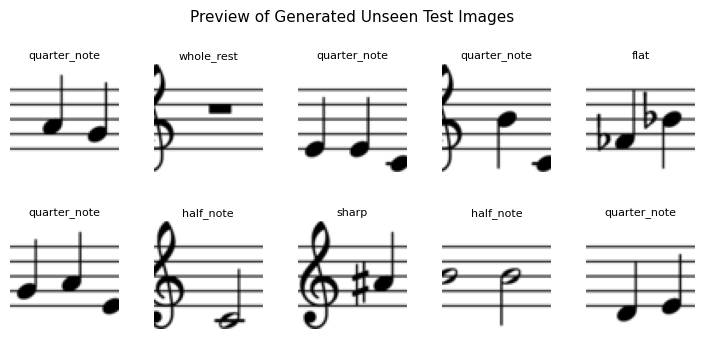

In [201]:
# step 13, part 6: preview generated unseen test images

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


TEST_IMAGES_DIR = Path("test_images")
TEST_IMAGES_METADATA_PATH = TEST_IMAGES_DIR / "test_images_metadata.csv"

if "test_images_metadata_df" not in globals():
    if not TEST_IMAGES_METADATA_PATH.exists():
        raise FileNotFoundError(
            f"Could not find metadata file at: {TEST_IMAGES_METADATA_PATH}"
        )

    test_images_metadata_df = pd.read_csv(TEST_IMAGES_METADATA_PATH)
    print("Loaded unseen test-image metadata.")


def preview_unseen_test_images(metadata_df, n_images=10, n_cols=5):
    """Display a compact preview grid of generated unseen test images."""
    required_columns = {"filename", "class"}
    missing_columns = required_columns - set(metadata_df.columns)

    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    preview_df = metadata_df.head(n_images).reset_index(drop=True)

    if preview_df.empty:
        raise ValueError("No unseen test images found.")

    n_rows = (len(preview_df) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(7.5, 3.4),
        dpi=100,
    )

    axes = axes.flatten()

    for ax, (_, row) in zip(axes, preview_df.iterrows()):
        image_path = Path(row["filename"])

        if not image_path.exists():
            image_path = TEST_IMAGES_DIR / image_path.name

        if image_path.exists():
            img = Image.open(image_path).convert("L")
            ax.imshow(img, cmap="gray")
        else:
            ax.text(
                0.5,
                0.5,
                "Image\nnot found",
                ha="center",
                va="center",
                fontsize=8,
            )

        ax.set_title(row["class"], fontsize=8, pad=4)
        ax.axis("off")

    for ax in axes[len(preview_df):]:
        ax.axis("off")

    fig.suptitle(
        "Preview of Generated Unseen Test Images",
        fontsize=11,
        y=0.98,
    )

    plt.subplots_adjust(
        left=0.03,
        right=0.97,
        bottom=0.04,
        top=0.82,
        wspace=0.12,
        hspace=0.45,
    )

    plt.show()


preview_unseen_test_images(
    test_images_metadata_df,
    n_images=10,
    n_cols=5,
)


In [202]:
# step 13, part 7: evaluate predictions on all generated unseen images

if "predict_music_symbol" not in globals():
    raise NameError(
        "predict_music_symbol is not defined. "
        "Please run Step 12 before running Step 13, Part 7."
    )

# Use the best model from final_results if available.
# Otherwise, use SVM as the default final classifier.
if "final_results" in globals():
    selected_model = (
        final_results
        .sort_values(by="test_accuracy", ascending=False)
        .iloc[0]["model"]
    )
else:
    selected_model = "Support_Vector_Machine"

unseen_prediction_rows = []

for _, row in test_images_metadata_df.iterrows():
    image_path = row["filename"]
    generated_label = row["class"]

    try:
        prediction_result = predict_music_symbol(
            image_path,
            model_name=selected_model
        )
        predicted_class = prediction_result["predicted_class"]

    except TypeError:
        # Fallback for an older Step 12 function that only accepts image_path
        predicted_class = predict_music_symbol(image_path)

    unseen_prediction_rows.append({
        "model": selected_model,
        "image_path": image_path,
        "generated_label": generated_label,
        "predicted_class": predicted_class,
        "correct_prediction": predicted_class == generated_label,
    })

unseen_predictions_df = pd.DataFrame(unseen_prediction_rows)

unseen_generated_accuracy = unseen_predictions_df["correct_prediction"].mean()

print("Prediction results for generated unseen images:")
display(unseen_predictions_df)

print("\nGenerated Unseen Image Prediction Summary")
print("-----------------------------------------")
print(f"Selected model:                 {selected_model}")
print(f"Total unseen images evaluated:  {len(unseen_predictions_df)}")
print(f"Correct predictions:            {unseen_predictions_df['correct_prediction'].sum()}")
print(f"Accuracy on unseen images:      {unseen_generated_accuracy:.4f}")


Prediction results for generated unseen images:


,model,image_path,generated_label,predicted_class,correct_prediction
0,Support_Vector_Machine,test_images/test_001_quarter_note.png,quarter_note,treble_clef,False
1,Support_Vector_Machine,test_images/test_002_whole_rest.png,whole_rest,whole_rest,True
2,Support_Vector_Machine,test_images/test_003_quarter_note.png,quarter_note,quarter_note,True
3,Support_Vector_Machine,test_images/test_004_quarter_note.png,quarter_note,treble_clef,False
4,Support_Vector_Machine,test_images/test_005_flat.png,flat,flat,True
5,Support_Vector_Machine,test_images/test_006_quarter_note.png,quarter_note,quarter_note,True
6,Support_Vector_Machine,test_images/test_007_half_note.png,half_note,half_note,True
7,Support_Vector_Machine,test_images/test_008_sharp.png,sharp,sharp,True
8,Support_Vector_Machine,test_images/test_009_half_note.png,half_note,half_note,True
9,Support_Vector_Machine,test_images/test_010_quarter_note.png,quarter_note,quarter_note,True



Generated Unseen Image Prediction Summary
-----------------------------------------
Selected model:                 Support_Vector_Machine
Total unseen images evaluated:  20
Correct predictions:            17
Accuracy on unseen images:      0.8500


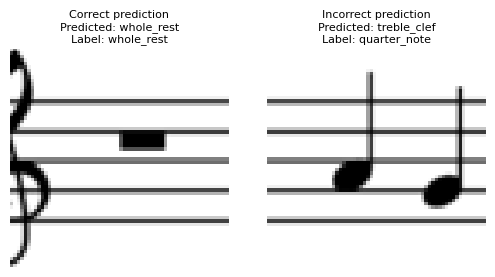

In [203]:
# step 13, part 8: display correct and incorrect unseen prediction examples

def display_unseen_prediction_examples(correct_row=None, incorrect_row=None):
    """Display correct and incorrect unseen prediction examples side by side."""
    examples = []

    if correct_row is not None:
        examples.append(("Correct prediction", correct_row))

    if incorrect_row is not None:
        examples.append(("Incorrect prediction", incorrect_row))

    if not examples:
        print("No unseen prediction examples available.")
        return

    fig, axes = plt.subplots(
        1,
        len(examples),
        figsize=(5.2, 2.6),
        dpi=100,
    )

    if len(examples) == 1:
        axes = [axes]

    for ax, (title_prefix, row) in zip(axes, examples):
        img = Image.open(row["image_path"]).convert("L")

        ax.imshow(img, cmap="gray")
        ax.axis("off")
        ax.set_title(
            f"{title_prefix}\n"
            f"Predicted: {row['predicted_class']}\n"
            f"Label: {row['generated_label']}",
            fontsize=8,
            pad=5,
        )

    plt.tight_layout(pad=0.4)
    plt.show()


correct_examples = unseen_predictions_df[
    unseen_predictions_df["correct_prediction"] == True
]

incorrect_examples = unseen_predictions_df[
    unseen_predictions_df["correct_prediction"] == False
]

correct_row = correct_examples.iloc[0] if len(correct_examples) > 0 else None
incorrect_row = incorrect_examples.iloc[0] if len(incorrect_examples) > 0 else None

display_unseen_prediction_examples(
    correct_row=correct_row,
    incorrect_row=incorrect_row,
)


## 6. Evaluation

**6.1 Project Aim Revisited**

The primary aim of this project was to investigate the effectiveness, generalisation capability, and robustness of classical supervised machine learning algorithms for multi-class musical notation image classification under controlled perturbation conditions.

More specifically, the project sought to evaluate:

* whether synthetically generated symbolic image datasets can support meaningful supervised learning experimentation
* whether dimensionality reduction improves classification behaviour in high-dimensional image spaces
* how different learning paradigms respond to controlled geometric and stochastic perturbations
* whether robust symbolic image recognition can be achieved using classical machine learning approaches without deep neural architectures

The experimental findings indicate that these objectives were successfully achieved. The dataset generation and preprocessing pipeline produced a balanced symbolic image dataset containing both clean and mildly perturbed samples. This allowed the supervised models to be compared not only in terms of standard predictive accuracy, but also in terms of robustness under controlled distributional shift.

The final results demonstrate that classical machine learning approaches can perform effectively on structured symbolic image classification tasks. In particular, the Support Vector Machine achieved the strongest overall results, with a held-out test accuracy of **0.8667**, a mild-noise test accuracy of **0.8300**, and a mean cross-validation accuracy of **0.8577**. It also produced the smallest clean-to-noise accuracy drop of **0.0733**, confirming that it was the most robust and stable classifier in the experiment.

Importantly, the project evolved beyond a simple benchmarking exercise. It provided evidence regarding the interaction between feature representation, dimensionality reduction, model inductive bias, and robustness behaviour in structured symbolic image classification.

**6.2 Strengths of the Project**

One of the principal strengths of this project lies in the construction of a reproducible synthetic dataset generation pipeline. Rather than relying on externally sourced benchmark datasets, the project introduced a controlled symbolic rendering framework using LilyPond and image-processing transformations. This provided control over class balance, perturbation intensity, rendering consistency, symbol variability, and experimental reproducibility.

Such control is rarely achievable in naturally collected datasets and enabled rigorous investigation of model behaviour under precisely defined conditions.

A second major strength concerns the breadth of the experimental methodology. Multiple supervised learning paradigms were evaluated, including:

* instance-based learning using from-scratch kNN
* dimensionality-reduced distance learning using PCA+kNN
* probabilistic learning using Gaussian Naive Bayes
* hierarchical rule-based learning using Decision Trees
* linear discriminative learning using Logistic Regression
* non-linear margin-based learning using Support Vector Machines

This diversity enabled meaningful comparative analysis across models with substantially different assumptions and learning mechanisms.

The project also demonstrated strong experimental discipline through train-validation-test separation, condition-aware stratified sampling, hyperparameter optimisation, five-fold cross-validation, robustness analysis, confusion matrix evaluation, metadata tracking, and reproducibility-oriented dataset management. These methodological components strengthened the reliability and interpretability of the resulting conclusions.

Another important strength concerns the use of Principal Component Analysis. The experiments showed that the original 4096-dimensional pixel representation could be compressed while preserving useful discriminative information. The PCA+kNN model used **20 principal components** and achieved a test accuracy of **0.7567**, outperforming the raw-pixel kNN baseline, which achieved **0.7200**. This indicates that the symbolic image data contained meaningful lower-dimensional structure.

The project also successfully demonstrated the importance of robustness-oriented evaluation. Several classifiers performed relatively well on clean images but degraded substantially under the `mild_noise` condition. This highlights the importance of evaluating model stability under controlled perturbation rather than relying only on standard test accuracy.

The most significant strength of the project emerged through the superior performance of the Support Vector Machine. The SVM achieved the best performance across the main evaluation criteria, including held-out test accuracy, mean cross-validation accuracy, mild-noise accuracy, and clean-to-noise stability. This confirms that the RBF-kernel SVM was the most effective classifier for the symbolic music notation dataset.

**6.3 Limitations of the Project**

Despite its strengths, the project has several important limitations.

The most significant limitation concerns dataset realism. Although the synthetic dataset enabled highly controlled experimentation, the rendered musical notation symbols remain cleaner and more structurally regular than real-world handwritten, scanned, or degraded music notation.

Real-world optical music recognition systems must often deal with uneven illumination, paper degradation, scanning artefacts, handwritten inconsistencies, staff-line corruption, overlapping notation, variable contrast conditions, and irregular symbol geometry. These factors were only partially represented within the current synthetic environment.

A second limitation concerns dataset scale. Although the dataset was balanced and suitable for classical machine learning experimentation, the total dataset size remained modest compared with modern large-scale computer vision datasets. Larger and more diverse datasets may alter the relative behaviour of the evaluated algorithms.

Another limitation concerns the feature representation. The project relied on flattened grayscale pixel vectors. Although PCA improved representational efficiency, the extracted features remained low-level and did not explicitly preserve spatial relationships in the way that convolutional architectures can.

Consequently, more advanced representation learning methods, such as Convolutional Neural Networks, may achieve stronger performance by automatically learning hierarchical spatial features.

The perturbation framework was also relatively constrained. Only mild geometric and stochastic corruption was introduced, including small rotations, translations, scaling variation, and low-amplitude Gaussian noise. More severe corruption regimes, such as elastic distortion, motion blur, partial occlusion, staff-line degradation, or adversarial perturbation, were not investigated. Therefore, the robustness conclusions are limited to moderate distributional shifts.

The computational characteristics of some algorithms also introduce practical limitations. In particular, kNN-based methods are memory-intensive and computationally expensive during inference because predictions require distance calculations against stored training samples. Although PCA reduced dimensionality, scalability limitations would likely emerge for larger datasets.

Finally, although five-fold cross-validation improved experimental reliability, formal statistical significance testing was not performed. Therefore, while the SVM clearly achieved the strongest results in this experiment, future work could apply statistical testing to determine whether performance differences between models are significant across repeated experimental runs.

**6.4 Interpretation of Experimental Findings**

Several important observations emerge from the experimental results.

The most significant finding is the clear superiority of the Support Vector Machine classifier across the main evaluation criteria. The SVM achieved the highest held-out test accuracy of **0.8667**, the highest mild-noise accuracy of **0.8300**, and the strongest mean cross-validation accuracy of **0.8577**. It also produced the smallest clean-to-noise accuracy drop of **0.0733**, showing that it was not only the most accurate model overall, but also the most stable under controlled perturbation.

This result suggests that non-linear margin-based classification was particularly effective for the symbolic music notation image classification task. The effectiveness of the SVM likely arises from two key factors. First, maximum-margin optimisation promotes robust class separation by maximising the separation between decision boundaries and training samples. Second, the RBF kernel enables flexible non-linear decision boundaries, allowing the classifier to model complex relationships between flattened pixel features (Cortes and Vapnik, 1995; Hastie, Tibshirani and Friedman, 2009).

Logistic Regression achieved the second strongest overall performance, with a test accuracy of **0.7983**, a mild-noise accuracy of **0.7100**, and a mean cross-validation accuracy of **0.8070**. This indicates that the generated symbolic images possessed a meaningful degree of linear separability. However, the stronger performance of the SVM suggests that non-linear decision boundaries captured additional structure that Logistic Regression could not fully model.

The PCA+kNN results demonstrate that dimensionality reduction improved the nearest-neighbour feature representation. PCA+kNN achieved a test accuracy of **0.7567**, outperforming raw-pixel kNN, which achieved **0.7200**. PCA+kNN also achieved better mild-noise accuracy than raw kNN, with scores of **0.6167** and **0.5700** respectively. This suggests that PCA helped suppress redundant or unstable variation in the original high-dimensional pixel space (Pearson, 1901; Jolliffe, 2002).

The raw-pixel kNN model produced moderate performance but was more sensitive to perturbation. Its clean-test accuracy was **0.8700**, while its mild-noise accuracy dropped to **0.5700**. This large decrease indicates that direct distance-based comparison in the original 4096-dimensional pixel space was vulnerable to small geometric and intensity changes. This behaviour is consistent with the sensitivity of nearest-neighbour methods to high-dimensional feature spaces and distance-based similarity measures (Cover and Hart, 1967).

The Decision Tree classifier achieved weaker overall performance and the largest robustness drop. Although its clean-test accuracy was **0.8567**, its mild-noise accuracy decreased sharply to **0.4233**, producing an accuracy drop of **0.4333**. This suggests that hierarchical threshold-based partitioning was highly sensitive to perturbation-induced changes in pixel structure. This behaviour is consistent with the tendency of unconstrained or highly complex decision trees to overfit local training patterns (Quinlan, 1986).

Gaussian Naive Bayes produced the lowest overall test accuracy of **0.6100**. This was expected because the model assumes conditional independence between features, which is unrealistic for image data where neighbouring pixels are spatially related. However, its accuracy drop of **0.1733** was moderate. This shows that robustness drop should be interpreted together with absolute performance, because a smaller drop does not necessarily mean the model is highly accurate (John and Langley, 1995).

Overall, the findings demonstrate that classical machine learning pipelines can be effective for controlled symbolic image recognition tasks. However, performance depends strongly on the choice of model, feature representation, and evaluation condition. The SVM provided the strongest balance between accuracy, robustness, and cross-validation stability.

**6.5 Potential Future Work**

Several promising directions for future work emerge from this investigation.

The most immediate extension would involve evaluation on real-world optical music recognition datasets containing scanned or handwritten notation. This would provide a more realistic assessment of model generalisation under unconstrained acquisition conditions.

Another important direction would involve introducing deep learning approaches, including Convolutional Neural Networks, residual architectures, transfer learning frameworks, transformer-based vision models, and self-supervised feature learning methods. Such approaches could automatically learn hierarchical spatial features and may outperform flattened-pixel classical machine learning models, particularly on larger and more realistic image datasets (Goodfellow, Bengio and Courville, 2016).

Additional future work could also explore ensemble learning methods, including Random Forests, Gradient Boosting, and hybrid classifier systems. These methods may provide stronger robustness than single Decision Trees while preserving some degree of interpretability.

The perturbation framework could also be expanded through the inclusion of elastic distortions, motion blur, variable illumination, staff-line corruption, partial occlusion, compression artefacts, and adversarial perturbations. This would enable a more comprehensive evaluation of robustness under realistic distributional shift.

Another promising direction involves sequence-level music notation recognition rather than isolated symbol classification. Real optical music recognition systems must interpret entire musical phrases and relationships between symbols. Extending the current framework toward phrase-level or staff-level recognition would therefore represent an important step toward practical application.

Finally, future work could investigate computational trade-offs between representation dimensionality, inference speed, memory consumption, robustness stability, and predictive performance. This would be particularly important for deployment-oriented optical music recognition systems operating under practical computational constraints.

## 7. Conclusion

This project investigated the effectiveness, generalisation capability, and robustness of classical supervised machine learning techniques for multi-class musical notation image classification under controlled perturbation conditions.

A reproducible synthetic dataset generation framework was developed using LilyPond-based symbolic rendering combined with controlled geometric and stochastic perturbations. The resulting dataset enabled systematic evaluation of multiple supervised learning paradigms within a controlled experimental environment. By including both clean and mild_noise image conditions, the project was able to evaluate not only standard classification accuracy, but also robustness under controlled distributional shift.

The experimental findings demonstrate that classical machine learning methods can remain effective for structured symbolic image recognition tasks when combined with appropriate preprocessing, feature representation, model selection, and evaluation methodology. The evaluated models included from-scratch kNN, PCA-enhanced kNN, Decision Tree, Gaussian Naive Bayes, Logistic Regression, and Support Vector Machine.

Among all evaluated classifiers, the **Support Vector Machine** was selected as the final best supervised model. It achieved the strongest performance across the main evaluation criteria, including the highest held-out test accuracy of **0.8667**, the highest mild-noise test accuracy of **0.8300**, and the strongest mean cross-validation accuracy of **0.8577**. It also produced the smallest clean-to-noise accuracy drop of **0.0733**, indicating the strongest robustness under mild perturbation.

These findings indicate that non-linear margin-based learning was particularly well suited to the structural complexity of the musical notation classification problem. The superior performance of the SVM suggests that the underlying symbolic image feature space contained important non-linear separability characteristics that could not be fully captured by simpler linear, probabilistic, tree-based, or distance-based models.

The experiments also demonstrated the value of dimensionality reduction using Principal Component Analysis. The PCA-enhanced kNN model outperformed the raw-pixel kNN baseline, achieving a test accuracy of **0.7567** compared with **0.7200** for raw kNN. This suggests that the original 4096-dimensional image representation contained redundant or noise-sensitive variation, and that meaningful discriminative structure could be preserved in a lower-dimensional feature space.

The comparative evaluation further revealed important differences between clean-condition accuracy and robustness under perturbation. Some models, such as Decision Tree, achieved relatively strong clean-image accuracy but experienced substantial degradation under the mild_noise condition. In contrast, the SVM maintained strong performance across both clean and perturbed images, confirming its stability under controlled image degradation.

Overall, the project successfully achieved its primary aim of evaluating and comparing classical machine learning approaches for musical symbol classification. The results show that a carefully engineered classical machine learning pipeline can achieve strong performance on controlled symbolic image recognition problems without relying on deep neural network architectures. The study also highlights the importance of robustness-oriented evaluation, cross-validation, and controlled dataset design when analysing machine learning systems under distributional variation.

In conclusion, the Support Vector Machine was identified as the most accurate, robust, and stable classifier for this musical notation image classification task.


## 8. References 

1. Bishop, C.M. (2006) Pattern recognition and machine learning. New York: Springer. Available at: https://link.springer.com/book/9780387310732

2. Cortes, C. and Vapnik, V. (1995) ‘Support-vector networks’, Machine Learning, 20(3), pp. 273-297. Available at: https://link.springer.com/article/10.1007/BF00994018 

3. Cover, T. and Hart, P. (1967) ‘Nearest neighbour pattern classification’, IEEE Transactions on Information Theory, 13(1). Available at: https://dl.acm.org/doi/10.1109/TIT.1967.1053964

4. Duda, R.O., Hart, P.E. and Stork, D.G. (2001) Pattern classification. 2nd edn. New York: Wiley. Available at: https://www.wiley.com/en-kr/Pattern+Classification%2C+2nd+Edition-p-9780471056690

5. Goodfellow, I., Bengio, Y. and Courville, A. (2016) Deep learning. Cambridge, MA: MIT Press. Available at: https://mitpress.mit.edu/9780262035613/deep-learning/

6. Harris, C.R. et al. (2020) ‘Array programming with NumPy’, Nature, 585. Available at: https://www.nature.com/articles/s41586-020-2649-2

7. Hastie, T., Tibshirani, R. and Friedman, J. (2009) The elements of statistical learning. 2nd edn. New York: Springer. Available at: https://link.springer.com/book/10.1007/978-0-387-84858-7

8. Hunter, J.D. (2007) ‘Matplotlib: A 2D graphics environment’, Computing in Science & Engineering, 9(3). Available at: http://dx.doi.org/10.1109/MCSE.2007.55

9. ImageMagick Studio LLC (2024) ImageMagick. Available at: https://imagemagick.org/ (Accessed: 8 May 2026).

10. John, G.H. and Langley, P. (1995) ‘Estimating continuous distributions in Bayesian classifiers’, Proceedings of the Eleventh Conference on Uncertainty in Artificial Intelligence. Available at: https://dl.acm.org/doi/10.5555/2074158.2074196

11. Jolliffe, I.T. (2002) Principal component analysis. 2nd edn. New York: Springer. Available at: https://link.springer.com/book/10.1007/b98835

12. Kohavi, R. (1995) ‘A study of cross-validation and bootstrap for accuracy estimation and model selection’, Proceedings of the 14th International Joint Conference on Artificial Intelligence. Available at: https://www.ijcai.org/Proceedings/95-2/Papers/016.pdf

13. LilyPond Development Team (2024) LilyPond music engraving system. Available at: https://lilypond.org/ (Accessed: 8 May 2026).

14. McKinney, W. (2010) ‘Data structures for statistical computing in Python’, Proceedings of the 9th Python in Science Conference. Available at: https://proceedings.scipy.org/articles/Majora-92bf1922-00a

15. Pearson, K. (1901) ‘On lines and planes of closest fit to systems of points in space’, Philosophical Magazine, 2(11). Available at: https://www.tandfonline.com/doi/abs/10.1080/14786440109462720

16. Pedregosa, F. et al. (2011) ‘Scikit-learn: Machine learning in Python’, Journal of Machine Learning Research, 12. Available at: https://www.jmlr.org/papers/volume12/pedregosa11a/pedregosa11a.pdf

17. Quinlan, J.R. (1986) ‘Induction of decision trees’, Machine Learning, 1(1). Available at: https://link.springer.com/article/10.1007/BF00116251

18. Streamlit (2024) Streamlit documentation. Available at: https://docs.streamlit.io/ (Accessed: 8 May 2026).


## 9. Appendices

### Appendix A – Prototype Inference Interface

As an additional extension, a lightweight Streamlit prototype was developed to demonstrate the practical deployment potential of the final Support Vector Machine (SVM) classifier (Streamlit, 2024). The prototype was not treated as an additional experimental evaluation, but rather as a usability demonstration showing how the trained classification pipeline could be integrated into an interactive prediction workflow.

Through the interface, a user can upload a music-symbol image for prediction. The uploaded image is processed using the same preprocessing pipeline applied during model development: it is converted to grayscale, cropped around the symbol content, centred on a white background, resized to 64×64 pixels, normalised to the range [0, 1], and flattened into a 4096-dimensional feature vector before being passed to the trained SVM classifier.

The application then returns the predicted musical symbol class together with the model’s top decision scores. This demonstrates how the final trained model can be extended beyond offline notebook experimentation into a simple deployable application while maintaining consistency with the original training and evaluation assumptions.


**External Single-Image Prediction Pipeline**

This appendix section demonstrates an extended preprocessing pipeline for external single-image prediction. Compared with the main test-set prediction pipeline, the external-image version includes additional cropping and centering steps to handle images that may not already follow the exact dataset format. The prediction function is deliberately named separately from the main Step 12 function to avoid overwriting the core implementation.

In [228]:
# appendix part 1: external single-image prediction pipeline

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


def preprocess_external_image(image_path, image_size=(64, 64)):
    """Preprocess an external image into a flattened normalised model input."""
    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    img = Image.open(image_path).convert("L")

    # Crop non-white content
    arr = np.asarray(img)
    mask = arr < 250

    if mask.any():
        coords = np.argwhere(mask)
        y0, x0 = coords.min(axis=0)
        y1, x1 = coords.max(axis=0) + 1
        img = img.crop((x0, y0, x1, y1))

    # Centre content on a square white canvas
    width, height = img.size
    side = max(width, height)

    square = Image.new("L", (side, side), color=255)
    square.paste(img, ((side - width) // 2, (side - height) // 2))

    # Resize, normalise, and flatten
    processed_img = square.resize(image_size)
    img_array = np.asarray(processed_img, dtype=np.float32) / 255.0
    img_vector = img_array.flatten().reshape(1, -1)

    return processed_img, img_vector


print("External image preprocessing function ready.")


External image preprocessing function ready.


In [229]:
# appendix part 2: external image prediction function

def predict_external_music_symbol(image_path, model_name="Support_Vector_Machine"):
    """Predict the musical symbol class of an external image."""
    processed_img, img_vector = preprocess_external_image(image_path)

    if model_name == "Support_Vector_Machine":
        if "svm_final" not in globals():
            raise NameError("svm_final is not defined. Please run Step 10 first.")
        pred_encoded = svm_final.predict(img_vector)[0]

    elif model_name == "PCA_plus_kNN_from_scratch":
        if "pca_final" not in globals() or "knn_pca_final" not in globals():
            raise NameError(
                "pca_final or knn_pca_final is not defined. Please run Step 6 first."
            )
        img_pca = pca_final.transform(img_vector)
        pred_encoded = knn_pca_final.predict(img_pca, batch_size=1)[0]

    elif model_name == "kNN_from_scratch":
        if "knn_final" not in globals():
            raise NameError("knn_final is not defined. Please run Step 5 first.")
        pred_encoded = knn_final.predict(img_vector, batch_size=1)[0]

    elif model_name == "Logistic_Regression":
        if "logreg_final" not in globals():
            raise NameError("logreg_final is not defined. Please run Step 9 first.")
        pred_encoded = logreg_final.predict(img_vector)[0]

    elif model_name == "Decision_Tree":
        if "dt_final" not in globals():
            raise NameError("dt_final is not defined. Please run Step 7 first.")
        pred_encoded = dt_final.predict(img_vector)[0]

    elif model_name == "Gaussian_Naive_Bayes":
        if "gnb_final" not in globals():
            raise NameError("gnb_final is not defined. Please run Step 8 first.")
        pred_encoded = gnb_final.predict(img_vector)[0]

    else:
        raise ValueError(f"Unsupported model_name: {model_name}")

    pred_class = label_encoder.inverse_transform([pred_encoded])[0]

    return {
        "image": processed_img,
        "image_path": str(image_path),
        "model": model_name,
        "predicted_label_encoded": int(pred_encoded),
        "predicted_class": pred_class,
    }


print("External image prediction function ready.")


External image prediction function ready.


In [230]:
# appendix part 3: test external image prediction

sample_image_path = file_test[0]
actual_class = label_encoder.inverse_transform([y_test[0]])[0]

if "final_results" in globals():
    selected_model = (
        final_results
        .sort_values(by="test_accuracy", ascending=False)
        .iloc[0]["model"]
    )
else:
    selected_model = "Support_Vector_Machine"

external_prediction_result = predict_external_music_symbol(
    sample_image_path,
    model_name=selected_model
)

external_prediction_summary = pd.DataFrame([{
    "model": external_prediction_result["model"],
    "image_path": external_prediction_result["image_path"],
    "predicted_class": external_prediction_result["predicted_class"],
    "actual_class": actual_class,
    "correct_prediction": (
        external_prediction_result["predicted_class"] == actual_class
    ),
}])

print("External single-image prediction summary:")
display(external_prediction_summary)


External single-image prediction summary:


,model,image_path,predicted_class,actual_class,correct_prediction
0,Support_Vector_Machine,music_symbols_dataset\mild_noise\half_note\hal...,half_note,half_note,True


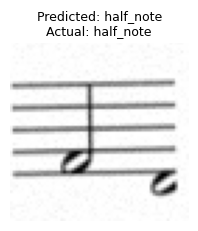

In [231]:
# appendix part 4: display external prediction result

plt.figure(figsize=(2.2, 2.2), dpi=100)
plt.imshow(external_prediction_result["image"], cmap="gray")
plt.axis("off")
plt.title(
    f"Predicted: {external_prediction_result['predicted_class']}\n"
    f"Actual: {actual_class}",
    fontsize=9,
    pad=6,
)

plt.tight_layout(pad=0.3)
plt.show()


**Save Final Trained Model Bundles**

This appendix section saves the final trained model objects and supporting metadata for later reuse. The from-scratch kNN models are saved together with their training feature arrays and selected `k` values because kNN is a lazy learning algorithm. The scikit-learn models are saved directly as fitted model objects. A model registry is also created to record the saved bundle paths in a structured format.

In [232]:
# appendix part 5: save final trained model bundles

from pathlib import Path

import joblib
import pandas as pd

# Safety checks
required_model_objects = [
    "label_encoder",
    "class_names",
    "X_train",
    "y_train",
    "best_k",
    "pca_final",
    "X_train_pca_final",
    "best_k_pca",
    "best_n_components",
    "dt_final",
    "best_depth",
    "gnb_final",
    "logreg_final",
    "svm_final",
    "best_svm_C",
    "best_svm_gamma",
]

missing_model_objects = [
    name for name in required_model_objects if name not in globals()
]

if missing_model_objects:
    raise NameError(
        f"Missing required objects before saving model bundles: {missing_model_objects}"
    )

# Model save directory
MODEL_DIR = Path("saved_models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Shared metadata
shared_metadata = {
    "label_encoder": label_encoder,
    "class_names": class_names,
    "image_size": (64, 64),
    "feature_type": "flattened_grayscale_pixels",
    "pixel_range": "[0, 1]",
}


In [233]:
# appendix part 6: build model bundles

model_bundles = {
    "kNN_from_scratch": {
        "filename": "music_symbol_knn_from_scratch_bundle.joblib",
        "bundle": {
            "model_name": "kNN_from_scratch",
            "best_k": best_k,
            "X_train": X_train,
            "y_train": y_train,
            **shared_metadata,
            "note": (
                "This kNN model is implemented from scratch. "
                "Prediction requires rebuilding KNearestNeighbours and fitting it "
                "with the saved X_train and y_train."
            )
        }
    },

    "PCA_plus_kNN_from_scratch": {
        "filename": "music_symbol_pca_knn_bundle.joblib",
        "bundle": {
            "model_name": "PCA_plus_kNN_from_scratch",
            "pca_model": pca_final,
            "X_train_pca": X_train_pca_final,
            "y_train": y_train,
            "best_k": best_k_pca,
            "best_n_components": best_n_components,
            **shared_metadata,
            "note": (
                "PCA is used for dimensionality reduction. "
                "The final classifier is the manually implemented kNN model. "
                "Prediction requires transforming input using pca_model first, "
                "then applying KNearestNeighbours to X_train_pca and y_train."
            )
        }
    },

    "Decision_Tree": {
        "filename": "music_symbol_decision_tree_bundle.joblib",
        "bundle": {
            "model_name": "Decision_Tree",
            "model": dt_final,
            "best_depth": best_depth,
            **shared_metadata,
        }
    },

    "Gaussian_Naive_Bayes": {
        "filename": "music_symbol_gaussian_nb_bundle.joblib",
        "bundle": {
            "model_name": "Gaussian_Naive_Bayes",
            "model": gnb_final,
            **shared_metadata,
        }
    },

    "Logistic_Regression": {
        "filename": "music_symbol_logistic_regression_bundle.joblib",
        "bundle": {
            "model_name": "Logistic_Regression",
            "model": logreg_final,
            "solver": "lbfgs",
            "classification_type": "multinomial_multi_class",
            **shared_metadata,
        }
    },

    "Support_Vector_Machine": {
        "filename": "music_symbol_svm_bundle.joblib",
        "bundle": {
            "model_name": "Support_Vector_Machine",
            "model": svm_final,
            "kernel": "rbf",
            "C": best_svm_C,
            "gamma": best_svm_gamma,
            **shared_metadata,
        }
    },
}

print("Model bundles prepared successfully.")


Model bundles prepared successfully.


In [234]:
# appendix part 7: save model bundles and registry

model_registry = {}
 
for model_name, item in model_bundles.items():
    model_path = MODEL_DIR / item["filename"]

    joblib.dump(
        item["bundle"],
        model_path
    )

    model_registry[model_name] = str(model_path)

registry_path = MODEL_DIR / "model_registry.joblib"
joblib.dump(model_registry, registry_path)

model_registry_df = pd.DataFrame([
    {
        "model": model_name,
        "saved_path": saved_path,
    }
    for model_name, saved_path in model_registry.items()
])

print("\nAll final model bundles saved successfully.")



All final model bundles saved successfully.


**Streamlit Prototype Application**

The trained Support Vector Machine model was integrated into a simple Streamlit prototype to demonstrate how the final classifier could be used for interactive music symbol image prediction. The application allows a user to upload a music symbol image, applies the same 64×64 grayscale preprocessing pipeline used during training, and returns the predicted class label together with the top decision scores.

**Launching the Application**

The Streamlit application was launched locally using the following command:

```bash
streamlit run streamlit_app.py
```

In [290]:
# create streamlit app file; 
# then run the following line of code to activate and launch the streamlit app on web browser live 
!streamlit run streamlit_app.py

^C


**Application Interface**

The screenshot below shows the deployed Streamlit interface after a test image has been
uploaded. The system applies the same preprocessing pipeline used during training,
displays the standardised 64×64 input, and returns the predicted musical symbol class
together with the model’s top decision scores.

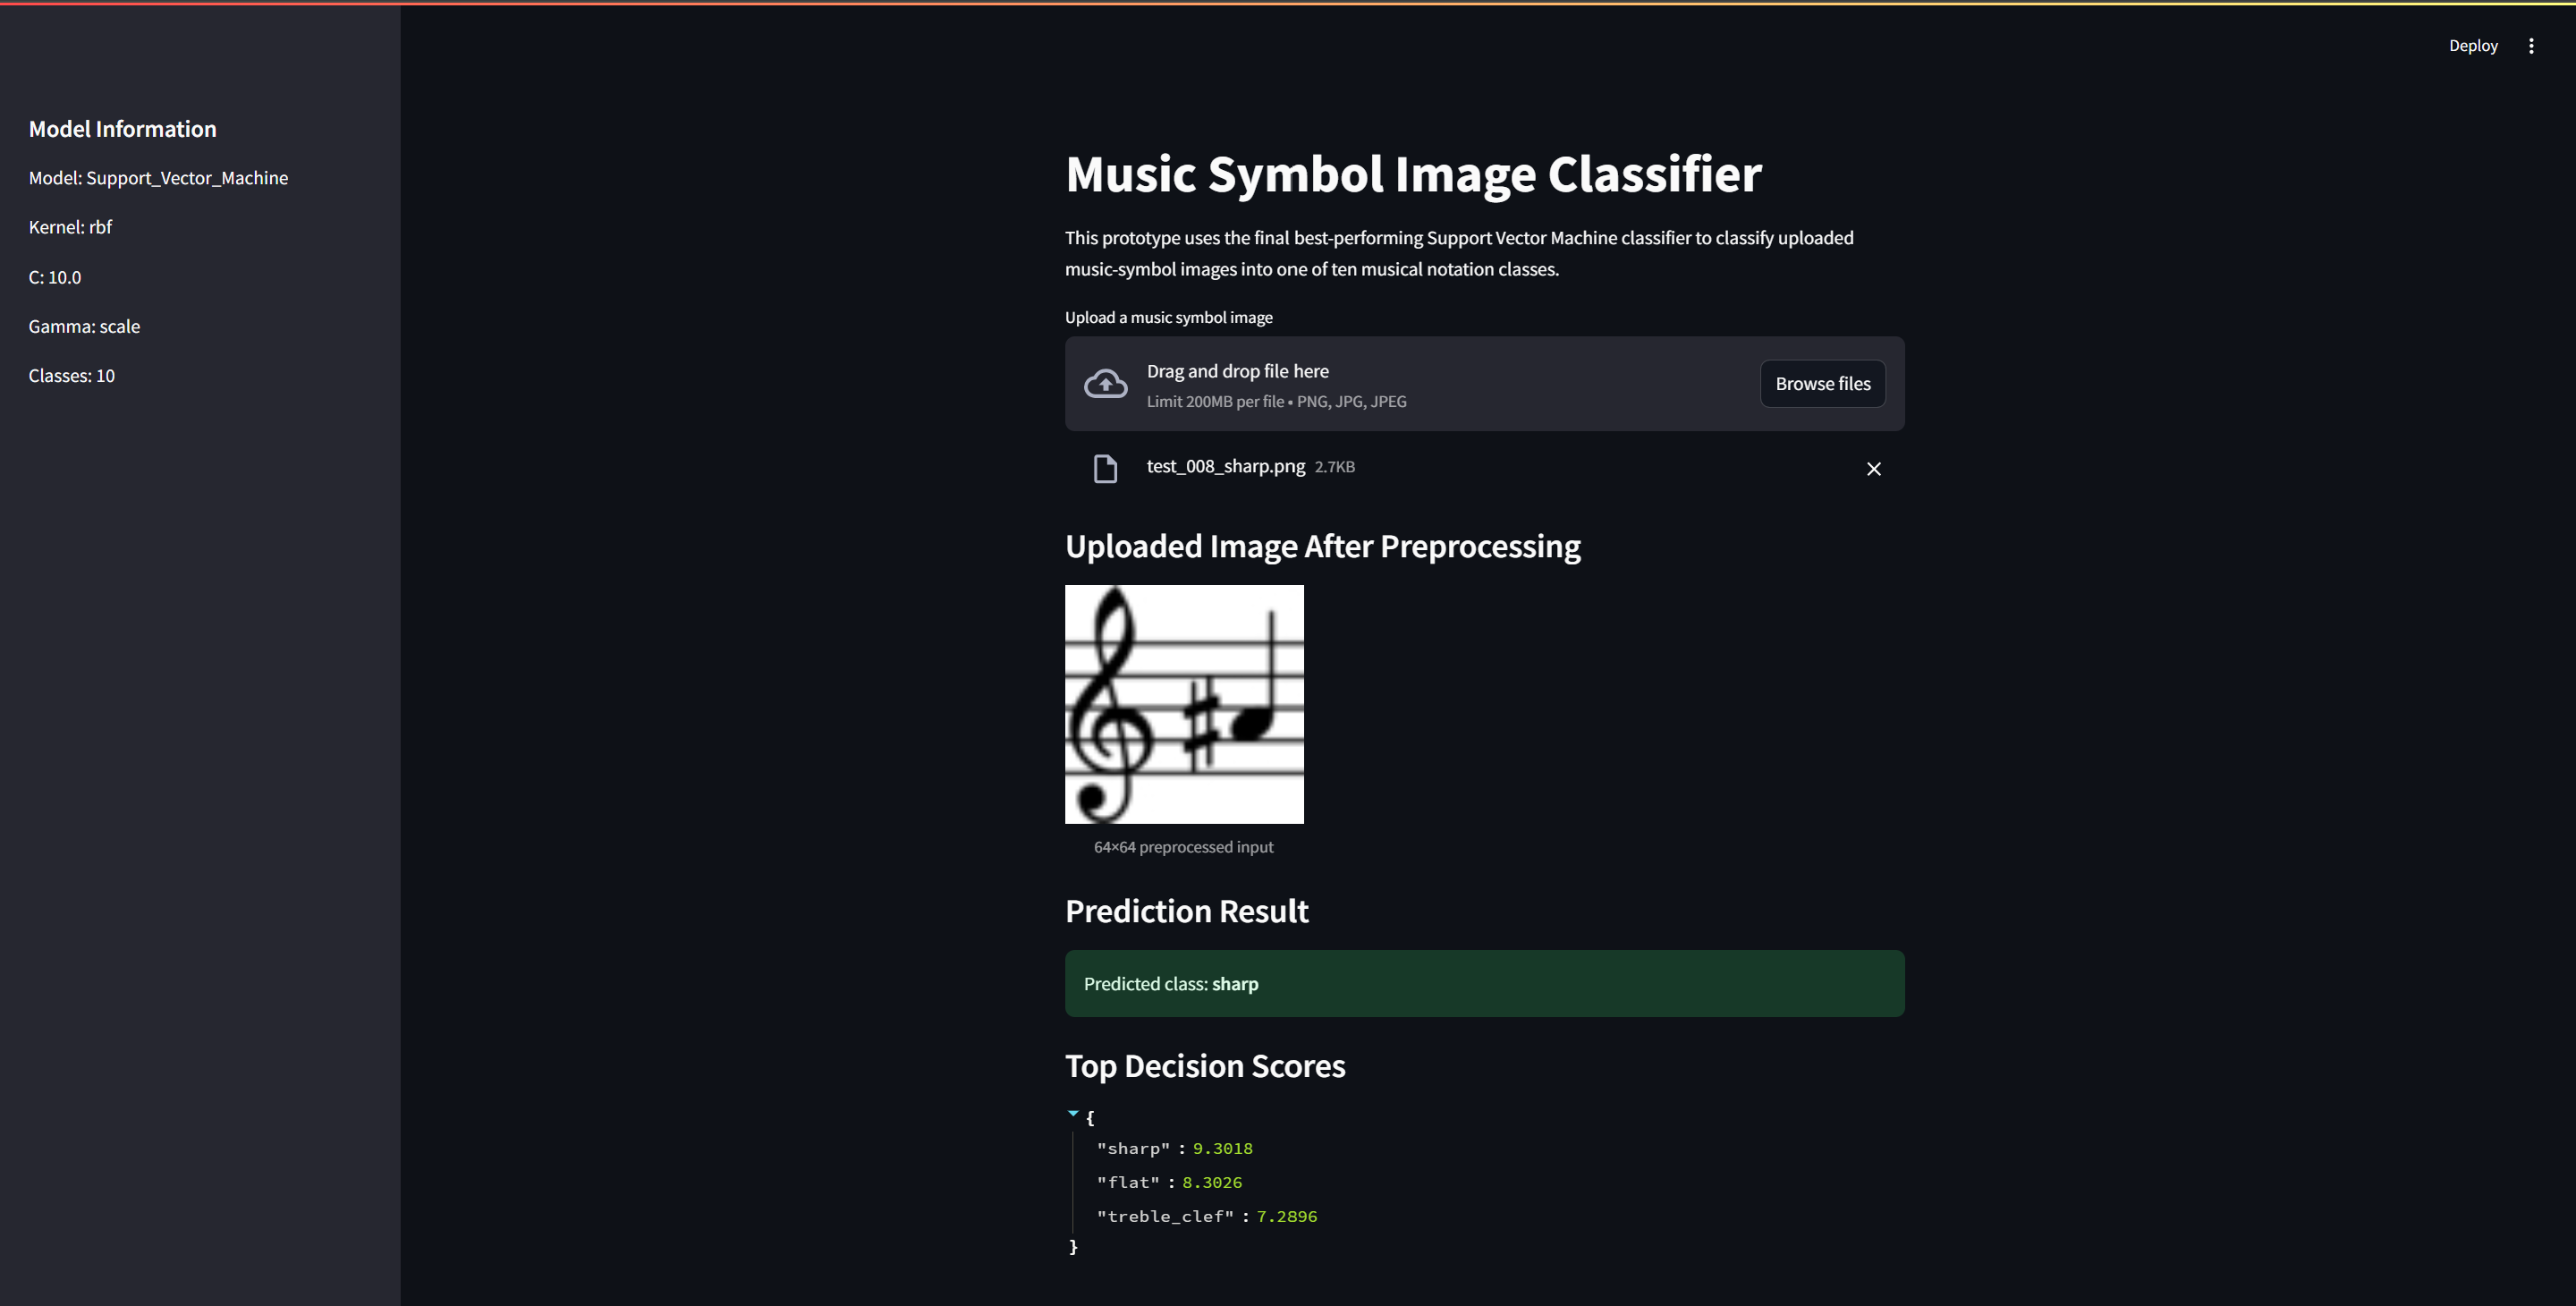